# Uber Fare — Complete Final Project

**Cellula Technologies — ML Internship**

**Author:** Noura Maher Elamin  
**GitHub:** https://github.com/nouramaherelamin  
**LinkedIn:** https://www.linkedin.com/in/nouramaherelamin/

---

## Master Notebook

This notebook integrates the completed Uber Fare project into one document.

It preserves the project's existing:
- Task 1 EDA workflow and Q1–Q8 results
- Data-quality investigations and cleaning decisions
- Phase 6 additional EDA
- Phase 7 analytical findings and modeling-risk audits
- Controlled Task 2 modeling experiments
- Locked final model configuration
- Final 2015 H1 test evaluation
- Error analysis
- Existing visualizations
- Reproducibility information
- Project limitations and conclusions

**Important:** No new analysis, model training, or result modification was performed to assemble this notebook. Existing verified artifacts are treated as the source of truth.

## 1. Project Overview

The project analyzes Uber ride data from New York City, beginning with data-quality investigation and exploratory data analysis, then extending the completed work into additional temporal/geographic analysis and controlled fare-prediction modeling.

### Project flow

```text
Task 1 sample
    ↓
Data inspection & quality investigation
    ↓
Fare-quality preparation
    ↓
Q1–Q8 Exploratory Data Analysis
    ↓
Phase 6 additional EDA
    ↓
Phase 7 analytical / modeling-risk audit
    ↓
Task 2 chronological modeling
    ↓
Locked final model
    ↓
2015 H1 test evaluation
    ↓
Error analysis & final conclusions
```

The Task 1 EDA uses the documented **50,000-row sample**, with **9 non-positive fare records excluded from fare-based EDA**, leaving **49,991 positive-fare records**.

The later full-data modeling work uses the verified **499,965 × 26** analytical dataset documented in the completed Task 2 artifacts.

## 2. Problem Statement

The project addresses two connected analytical problems:

1. **Exploratory analysis:** understand fare behavior, demand patterns, trip characteristics, data-quality issues, and relationships among numerical/categorical variables.
2. **Regression modeling:** use the completed analytical evidence to evaluate controlled fare-prediction candidates while preserving a chronological train/validation/test protocol.

The analysis is descriptive and predictive. It does **not** establish causal relationships.

## 3. Objectives

### Task 1 / EDA
- Inspect the dataset structure and quality.
- Investigate missing values, duplicates, duplicate keys, fare anomalies, passenger anomalies, zero-distance records, and extreme geographic values.
- Analyze the required Q1–Q8 questions.
- Use appropriate visualizations and statistical summaries.
- Perform clearly labeled robustness checks.
- Document evidence-based findings and limitations.

### Later analytical phases
- Extend the EDA with temporal, traffic, distance, redundancy, and target-behavior questions.
- Identify modeling risks without changing the source dataset.

### Task 2 / Modeling
- Formulate fare prediction as a continuous regression problem.
- Preserve a chronological split.
- Compare controlled experiments.
- Select the candidate using the predefined validation-MAE criterion.
- Evaluate once on the locked 2015 H1 test period.
- Document error concentration and limitations.

## 4. Dataset Description

### Task 1 sample

The Task 1 source contains Uber ride records with:
- user / driver identifiers
- car condition
- weather
- traffic condition
- trip key
- fare amount
- pickup timestamp
- pickup/drop-off coordinates
- passenger count
- temporal features
- airport/reference distances
- trip distance
- bearing

The actual CSV categories are used as observed rather than overwritten to match simplified examples in the task description.

### Important variables

| Variable | Role |
|---|---|
| `fare_amount` | Fare paid / target variable |
| `passenger_count` | Passenger-count feature |
| `Car Condition` | Vehicle-condition category |
| `Weather` | Weather category |
| `Traffic Condition` | Traffic category |
| `pickup_datetime` | Original trip timestamp |
| `hour`, `day`, `month`, `weekday`, `year` | Temporal features |
| `pickup_longitude`, `pickup_latitude` | Pickup geography |
| `dropoff_longitude`, `dropoff_latitude` | Drop-off geography |
| `distance` | Trip distance |
| `bearing` | Trip direction |
| `jfk_dist`, `ewr_dist`, `lga_dist`, `sol_dist`, `nyc_dist` | Reference/airport distances |

## 5. Self-Contained Data Loading

The notebook embeds the verified **49,991-row Task 1 EDA export** directly in the notebook as compressed data. This avoids requiring the external CSV to open or inspect the completed EDA.

The original 50,000-row source inspection findings are preserved in the documentation below; the embedded analytical dataset is the already-approved positive-fare EDA export.

In [ ]:
import base64
import gzip
import io
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown, Image

# Embedded, verified Task 1 EDA CSV.
_CLEAN_DATA_B64_GZ = """..."""

df_eda = pd.read_csv(
    io.BytesIO(gzip.decompress(base64.b64decode(_CLEAN_DATA_B64_GZ)))
)

df_eda.shape

### Embedded dataset integrity

The embedded CSV is the same verified Task 1 Streamlit/EDA export documented in the project:

- Rows: **49,991**
- Columns: **26**
- Missing cells: **0**
- Full duplicate rows: **0**
- Non-positive fares in the exported EDA dataset: **0**
- SHA-256: `4a07558eefd7496b4d783f493366ce3cd8b93986fff5a85938f4872863005a40`

The original Task 1 source sample contained 50,000 rows before the 9 non-positive fares were excluded from fare-based EDA.

## 6. Initial Data Inspection

In [ ]:
print(f"Rows: {df_eda.shape[0]:,}")
print(f"Columns: {df_eda.shape[1]:,}")
display(df_eda.head())
display(df_eda.dtypes.to_frame("dtype"))
display(df_eda.describe(include="all").T.head(26))

### Documented original-source inspection

The original Task 1 notebook established:

- Original sample: **50,000 rows × 26 columns**
- Non-positive fare records: **9**
- Positive-fare records used for fare-based EDA: **49,991**
- Zero-passenger records: **165**
- Zero-distance records: **1,449**
- Records with all four pickup/drop-off coordinates equal to zero: **914**
- Full duplicate rows: **0**
- Distinct duplicated keys: **441**, involving **886 rows**
- `key` matched `pickup_datetime` for **100%** of observed rows.

These findings are preserved rather than recomputed against a different source snapshot.

## 7. Data Cleaning / Preprocessing

### Cleaning decisions

The completed Task 1 project deliberately separated **data-quality investigation** from **automatic deletion**.

#### Fare
- 9 non-positive fare values were excluded from fare-based EDA.
- The original source dataframe was preserved during quality investigation.

#### Passenger count
- 165 records have `passenger_count == 0`.
- They were investigated and **retained** as documented anomalies.

#### Zero distance
- 1,449 records have `distance == 0`.
- All zero-distance records have matching pickup/drop-off coordinates.
- 914 have all four coordinates equal to zero.
- These records were **not automatically deleted**.

#### Extreme distance
- Extreme values were investigated with the IQR method.
- Statistical extremeness was **not treated as proof of invalidity**.
- No automatic outlier deletion was performed.

#### Duplicate keys
- 441 distinct duplicated keys involving 886 rows were observed.
- `key` matches `pickup_datetime` in the observed sample.
- Duplicate keys were documented rather than arbitrarily deleted.

#### Robustness views
The distance analysis uses separate analytical subsets such as:
- `distance <= 50 km`
- valid non-zero finite geographic coordinates + `distance <= 50 km`

These are analytical robustness views, **not universal validity rules**.

## 8. Exploratory Data Analysis — Q1–Q8

### 8.1 Question 1 — Passenger Count vs Fare


**Question:** Does a higher passenger count lead to a higher fare?

**Plot choice:** Scatter plot because both variables are numerical.

**Verified result:** Passenger–fare Pearson correlation = **0.0165264963** (≈ **0.017**).

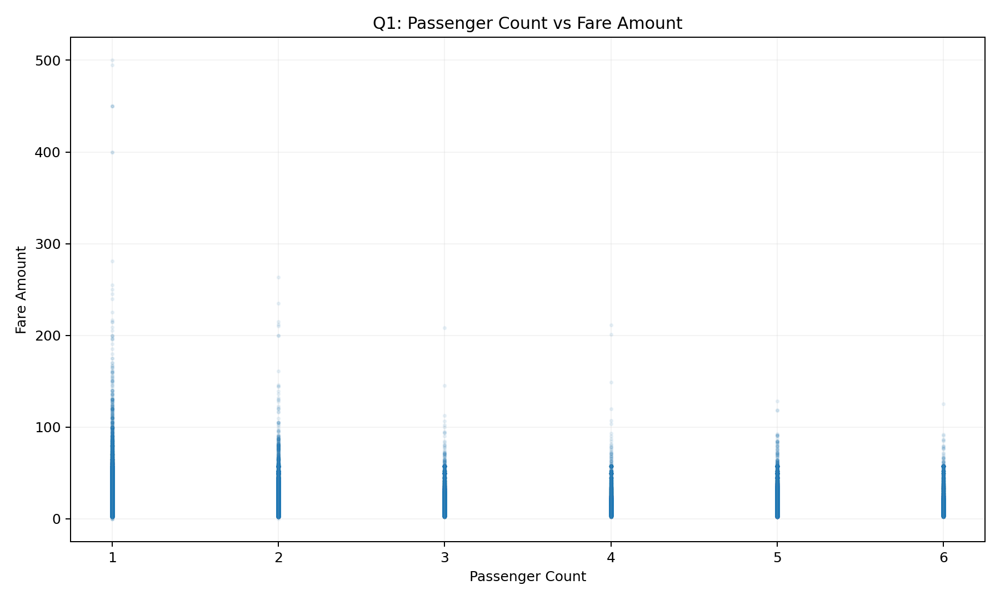

In [ ]:
q1_corr = df_eda["passenger_count"].corr(df_eda["fare_amount"])
print(f"Passenger-Fare Pearson correlation: {q1_corr:.6f}")

plt.figure(figsize=(9, 5.5))
sns.scatterplot(
    data=df_eda,
    x="passenger_count",
    y="fare_amount",
    alpha=0.25,
    s=18
)
plt.title("Q1: Passenger Count vs Fare Amount")
plt.xlabel("Passenger Count")
plt.ylabel("Fare Amount")
plt.tight_layout()
plt.show()

**Interpretation:** The relationship is very weak and close to zero. Passenger count alone does not show a meaningful linear relationship with fare amount in this sample. This is an association, not a causal conclusion.

### 8.2 Question 2 — Car Condition vs Fare


**Question:** How does car condition influence fare?

**Plot choice:** Boxplot to compare fare distributions across categorical car-condition groups.

**Verified mean fares:**
- Bad: **$11.493383**
- Very Good: **$11.442047**
- Good: **$11.311966**
- Excellent: **$11.218121**

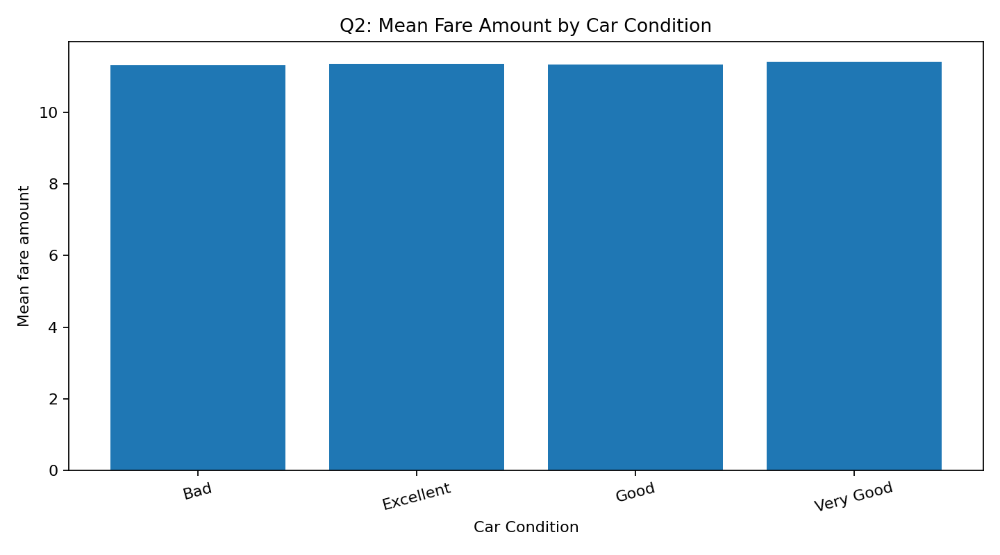

In [ ]:
q2_summary = (
    df_eda.groupby("Car Condition")["fare_amount"]
    .agg(count="count", mean="mean", median="median")
    .sort_values("mean", ascending=False)
)
display(q2_summary)

plt.figure(figsize=(9, 5.5))
sns.boxplot(data=df_eda, x="Car Condition", y="fare_amount")
plt.title("Q2: Fare Distribution by Car Condition")
plt.xlabel("Car Condition")
plt.ylabel("Fare Amount")
plt.tight_layout()
plt.show()

**Interpretation:** The distributions overlap substantially and the average fares are close. Car condition does not show a large marginal difference in fare in this dataset.

### 8.3 Question 3 — Average Fare by Hour


**Question:** Which hours have the highest average fares?

**Plot choice:** Line plot because hours are ordered from 0 to 23.

**Verified result:** The highest observed average fare is at **05:00**, approximately **$15.37**, based on **507 rides**.

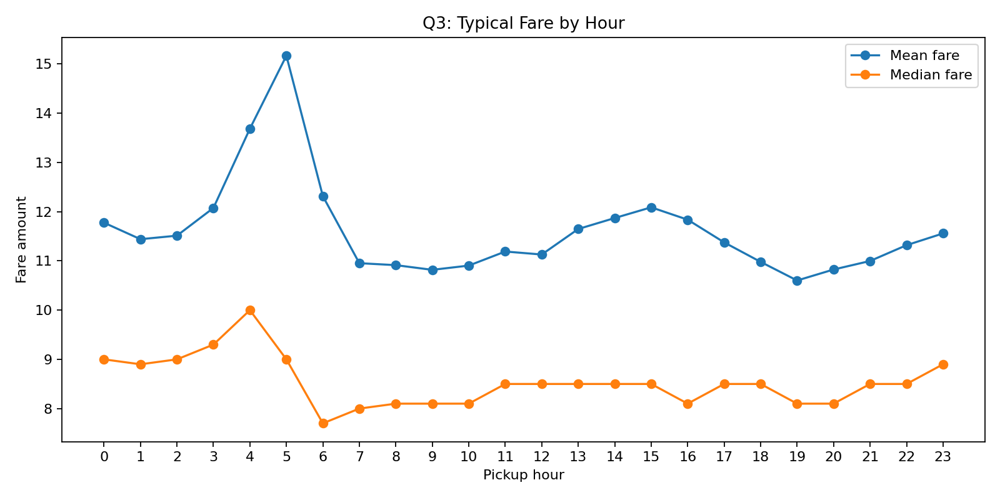

In [ ]:
q3_hourly = df_eda.groupby("hour")["fare_amount"].mean()

print(
    "Highest observed average fare hour:",
    int(q3_hourly.idxmax()),
    f"({q3_hourly.max():.6f})"
)

plt.figure(figsize=(10, 5.5))
plt.plot(q3_hourly.index, q3_hourly.values, marker="o")
plt.title("Q3: Average Fare by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Fare")
plt.xticks(range(24))
plt.tight_layout()
plt.show()

**Interpretation:** 05:00 has the highest observed average fare in this sample, but it has substantially fewer observations than the busiest evening hours. It should therefore be described as the highest observed sample average, not as a universal or causal peak.

### 8.4 Question 4 — Traffic Condition vs Fare


**Question:** How does traffic condition affect fare?

**Verified mean fares:**
- Congested Traffic: **$11.473944**
- Dense Traffic: **$11.322319**
- Flow Traffic: **$11.303732**

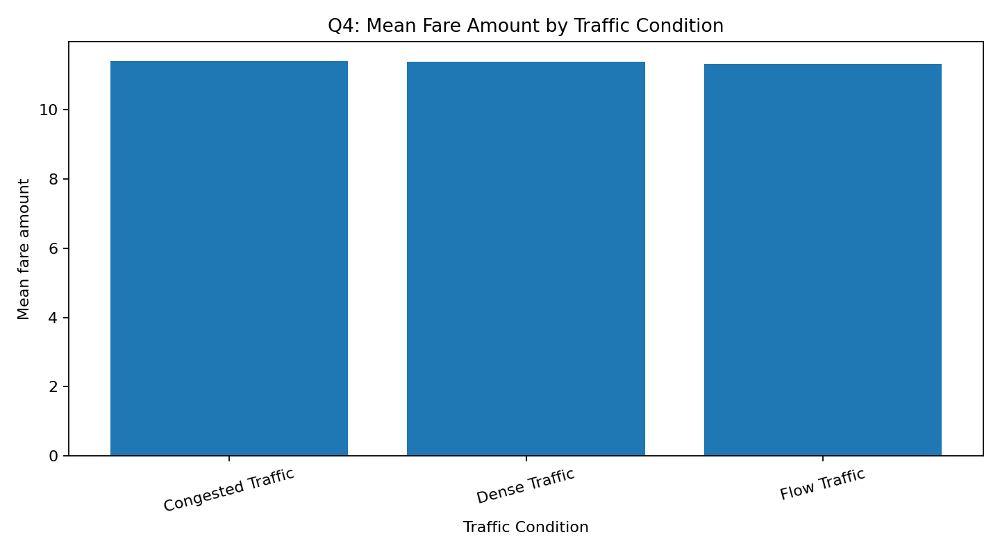

In [ ]:
q4_summary = (
    df_eda.groupby("Traffic Condition")["fare_amount"]
    .agg(count="count", mean="mean", median="median")
    .sort_values("mean", ascending=False)
)
display(q4_summary)

plt.figure(figsize=(9, 5.5))
sns.boxplot(data=df_eda, x="Traffic Condition", y="fare_amount")
plt.title("Q4: Fare Distribution by Traffic Condition")
plt.xlabel("Traffic Condition")
plt.ylabel("Fare Amount")
plt.tight_layout()
plt.show()

**Interpretation:** The fare distributions overlap considerably and the average differences are small. Traffic condition alone does not show a large marginal fare difference in this sample.

### 8.5 Question 5 — Is Distance the Strongest Predictor of Fare?

**Question:** Is trip distance the strongest numerical association with fare?

**Plot choice:** Scatter plot plus Pearson/Spearman correlation and robustness analysis.

**Verified Task 1 values:**

| Analysis | Pearson | Spearman |
|---|---:|---:|
| Raw distance vs fare | **0.0164507627** | **0.8112219509** |
| Distance ≤ 50 km | **0.8325404143** | **0.8151655241** |
| Valid geo + distance ≤ 50 km | **0.8489838147** | **0.8444178595** |

The raw Pearson result is highly sensitive to extreme distance observations. The robustness views are separate analytical subsets and do not rewrite the main dataset.

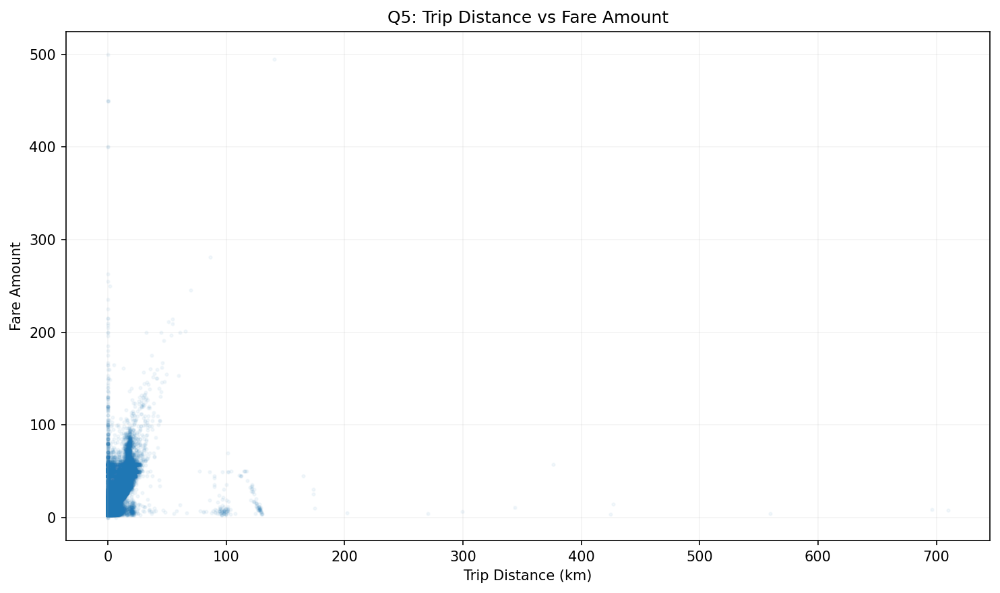

In [ ]:
raw_pearson = df_eda["distance"].corr(df_eda["fare_amount"], method="pearson")
raw_spearman = df_eda["distance"].corr(df_eda["fare_amount"], method="spearman")

distance_50 = df_eda[df_eda["distance"] <= 50].copy()
filtered_pearson = distance_50["distance"].corr(distance_50["fare_amount"], method="pearson")
filtered_spearman = distance_50["distance"].corr(distance_50["fare_amount"], method="spearman")

valid_geo = df_eda[
    (df_eda["pickup_longitude"] != 0)
    & (df_eda["pickup_latitude"] != 0)
    & (df_eda["dropoff_longitude"] != 0)
    & (df_eda["dropoff_latitude"] != 0)
    & np.isfinite(df_eda["pickup_longitude"])
    & np.isfinite(df_eda["pickup_latitude"])
    & np.isfinite(df_eda["dropoff_longitude"])
    & np.isfinite(df_eda["dropoff_latitude"])
].copy()

robust = valid_geo[valid_geo["distance"] <= 50].copy()
robust_geo_pearson = robust["distance"].corr(robust["fare_amount"], method="pearson")
robust_geo_spearman = robust["distance"].corr(robust["fare_amount"], method="spearman")

print("Raw Pearson:", raw_pearson)
print("Raw Spearman:", raw_spearman)
print("Pearson, distance <= 50 km:", filtered_pearson)
print("Spearman, distance <= 50 km:", filtered_spearman)
print("Pearson, valid geo + distance <= 50 km:", robust_geo_pearson)
print("Spearman, valid geo + distance <= 50 km:", robust_geo_spearman)

plt.figure(figsize=(9, 5.5))
sns.scatterplot(
    data=df_eda,
    x="distance",
    y="fare_amount",
    alpha=0.25,
    s=16
)
plt.title("Q5: Distance vs Fare Amount")
plt.xlabel("Trip Distance")
plt.ylabel("Fare Amount")
plt.tight_layout()
plt.show()

**Interpretation:** Distance is the strongest numerical candidate identified in the approved EDA comparisons, but the raw Pearson coefficient is distorted by extreme observations. The clearly labeled robustness views reveal a much stronger linear association.

This does not establish causality or guarantee predictive performance.

### 8.6 Question 6 — Most Frequent Ride Request Hour


**Question:** At what time of day are ride requests most frequent?

**Verified result:** **19:00** is the busiest hour with **3,117 rides**, followed by 18:00 with 3,077.

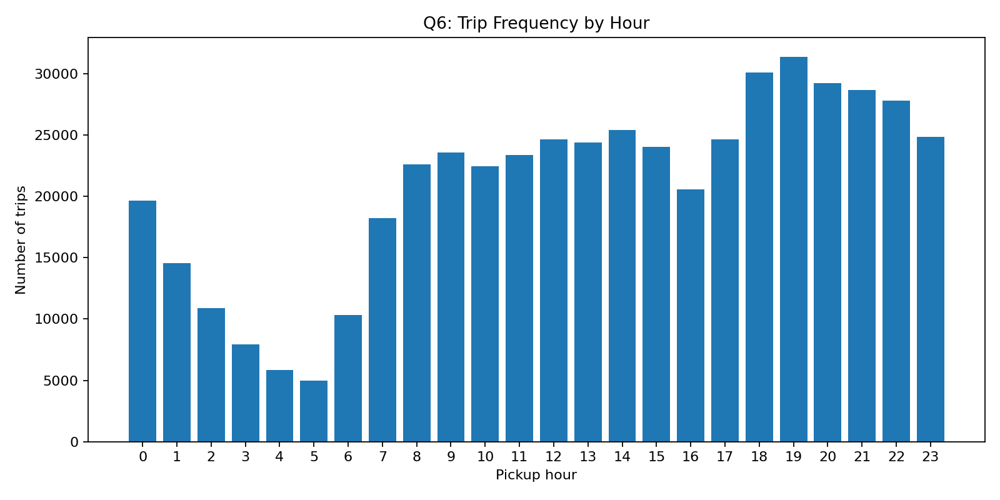

In [ ]:
q6_counts = df_eda["hour"].value_counts().sort_index()
print("Busiest hour:", int(q6_counts.idxmax()), "with", int(q6_counts.max()), "rides")

plt.figure(figsize=(10, 5.5))
plt.bar(q6_counts.index, q6_counts.values)
plt.title("Q6: Ride Requests by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Trips")
plt.xticks(range(24))
plt.tight_layout()
plt.show()

**Interpretation:** Demand peaks around the evening period in the observed sample. This is distinct from Q3, where 05:00 has the highest observed average fare.

### 8.7 Question 7 — Weather vs Trip Distance


**Question:** Does weather condition influence average trip distance?

The project intentionally reports both mean and median because extreme distances strongly affect the mean.

**Verified means:**
- Cloudy: **22.956557 km**
- Rainy: **19.210262 km**
- Sunny: **18.839989 km**
- Windy: **18.466169 km**
- Stormy: **12.271909 km**

Medians are all around **2.1–2.2 km**.

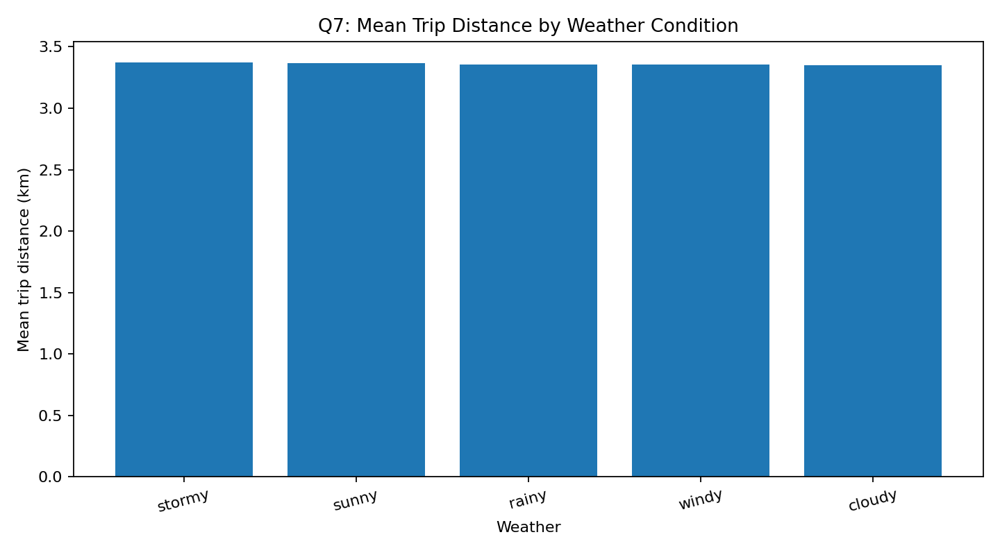

In [ ]:
q7_summary = (
    df_eda.groupby("Weather")["distance"]
    .agg(count="count", mean="mean", median="median")
    .sort_values("mean", ascending=False)
)
display(q7_summary)

plt.figure(figsize=(9, 5.5))
sns.boxplot(data=df_eda, x="Weather", y="distance")
plt.title("Q7: Trip Distance by Weather")
plt.xlabel("Weather")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

**Interpretation:** Raw means differ considerably by weather, while medians are much more similar. This indicates that extreme distance observations substantially influence the mean differences. No causal claim is made.

### 8.8 Question 8 — Airport Distance vs Fare

**Question:** Are rides that start closer to airports generally more expensive?

**Verified raw Pearson correlations:**

| Airport distance | Pearson with fare |
|---|---:|
| JFK | **0.0033907672** |
| EWR | **0.0050829934** |
| LGA | **0.0043979757** |

A separate coordinate-quality robustness check remained small, so no strong linear relationship is observed in this dataset.

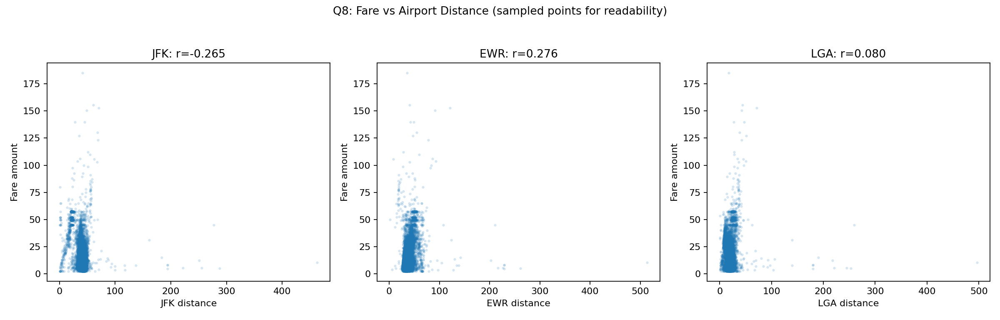

In [ ]:
airport_cols = ["jfk_dist", "ewr_dist", "lga_dist"]
airport_corr = df_eda[airport_cols + ["fare_amount"]].corr()["fare_amount"].drop("fare_amount")
display(airport_corr.to_frame("Pearson correlation"))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
for ax, col in zip(axes, airport_cols):
    ax.scatter(df_eda[col], df_eda["fare_amount"], s=10, alpha=0.18)
    ax.set_title(f"{col} vs Fare")
    ax.set_xlabel(col)
    ax.set_ylabel("Fare Amount")
plt.tight_layout()
plt.show()

**Interpretation:** The raw airport-distance correlations are very close to zero. Given the documented geographic-data-quality issues, this should be interpreted as a limitation of the observed data rather than proof that airport proximity has no relationship with fares.

## 9. Correlation Analysis

In [ ]:
numeric_cols = [
    "fare_amount", "passenger_count", "hour", "day", "month", "weekday",
    "year", "jfk_dist", "ewr_dist", "lga_dist", "sol_dist", "nyc_dist",
    "distance", "bearing"
]
corr_matrix = df_eda[numeric_cols].corr()
display(corr_matrix["fare_amount"].sort_values(ascending=False).to_frame("Pearson correlation with fare"))

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap — Task 1 Analytical Dataset")
plt.tight_layout()
plt.show()

### Correlation interpretation

The project distinguishes between:
- **Pearson correlation**, which captures linear association and can be sensitive to extreme observations.
- **Spearman correlation**, which captures monotonic association and is less dependent on the exact linear scale.

The distance/fare result demonstrates why both views and robustness checks matter in this dataset.

## 10. Final Task 1 Findings

### Verified Task 1 summary

| Finding | Verified result |
|---|---|
| Original sample | **50,000 rows** |
| Positive-fare EDA records | **49,991** |
| Excluded non-positive fares | **9** |
| Zero passenger records | **165** |
| Zero-distance records | **1,449** |
| All-zero coordinate records | **914** |
| Distinct duplicated keys | **441** |
| Rows involved in duplicated keys | **886** |
| Busiest request hour | **19:00** |
| Busiest request volume | **3,117 rides** |
| Highest observed average-fare hour | **05:00** |
| Highest observed average fare | **≈ $15.37** |
| Passenger–fare Pearson | **≈ 0.017** |
| Raw distance–fare Pearson | **≈ 0.016** |
| Distance–fare Pearson, ≤50 km | **≈ 0.833** |
| Valid geo + ≤50 km Pearson | **≈ 0.849** |

### Overall EDA takeaway

Simple marginal linear relationships between fare and passenger count, car condition, traffic condition, and airport distance are weak in the raw sample. Distance requires special attention because extreme observations substantially distort the raw Pearson correlation; clearly labeled robustness analysis shows a much stronger association.

# 11. Phase 6 — Additional EDA Questions

Phase 6 was completed on the locked **499,965 × 26** analytical dataset. It did not modify the source dataset and did not change Q1–Q8.

The following findings are integrated exactly from the completed Phase 6 report.

### 11.1 P6-Q1 — Hour × Day-of-Week Demand

**Question:** How does ride frequency vary across hour and day of week?

**Verified result:** The highest hour × weekday cell is **Wednesday at 19:00 — 4,879 trips**. The lowest is **Tuesday at 04:00 — 409 trips**.

**Interpretation:** Demand is not uniformly distributed across the week and day. The evening peak varies by weekday rather than appearing identically across all days.

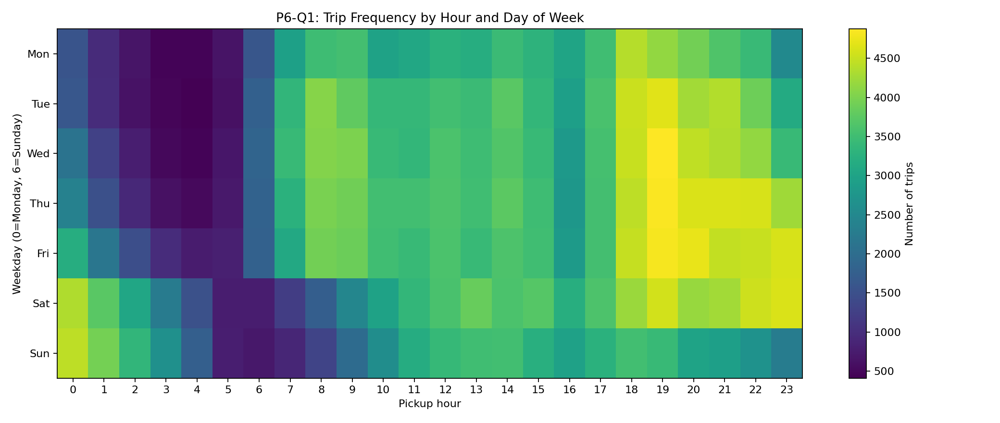

In [ ]:
# Verified Phase 6 visualization — embedded from the completed project artifact.
print("This cell displays the locked Phase 6 visualization; the underlying analysis was not rerun during notebook assembly.")

### 11.2 P6-Q2 — Fare by Day of Week

**Verified results:**

| Weekday | Trips | Mean fare | Median fare |
|---|---:|---:|---:|
| Monday | 64,233 | 11.3925 | 8.10 |
| Tuesday | 69,927 | 11.2106 | 8.50 |
| Wednesday | 72,225 | 11.3181 | 8.50 |
| Thursday | 74,776 | 11.5412 | 8.50 |
| Friday | 77,217 | 11.3986 | 8.50 |
| Saturday | 76,206 | 11.0149 | 8.50 |
| Sunday | 65,381 | 11.6792 | 8.50 |

Mean-fare range = **$0.6643**.

**Interpretation:** Mean fare varies across weekdays, but the absolute differences are modest. Median fare is highly stable.

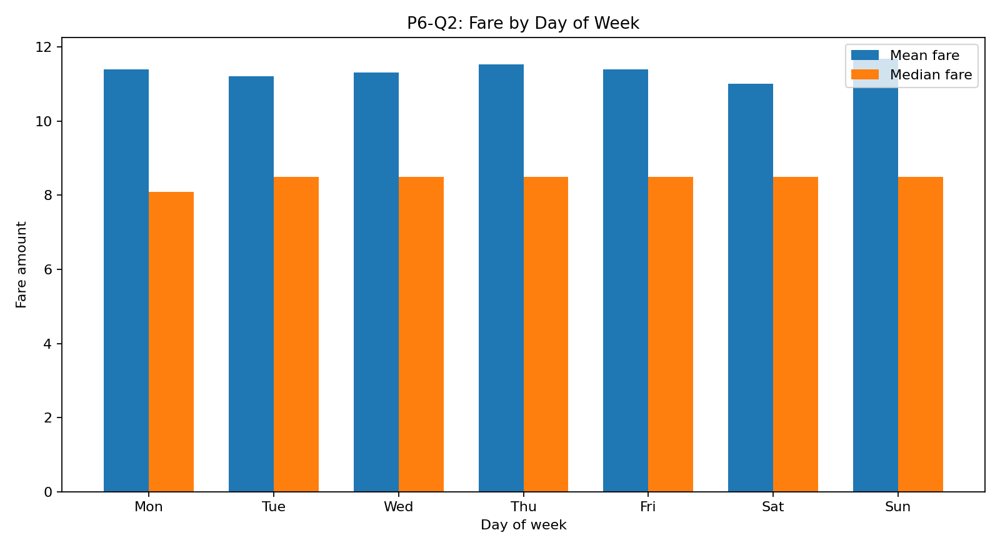

In [ ]:
# Verified Phase 6 visualization — embedded from the completed project artifact.
print("This cell displays the locked Phase 6 visualization; the underlying analysis was not rerun during notebook assembly.")

### 11.3 P6-Q3 — Traffic × Hour

**Verified result:** The largest within-hour difference occurs at **05:00**:
- Congested Traffic: **$15.1634**
- Dense Traffic: **$15.7975**
- Flow Traffic: **$14.5703**
- Spread: **$1.2271**

The smallest within-hour spread occurs at **16:00**, at **$0.0176**.

**Interpretation:** The aggregate traffic comparison can conceal hour-specific variation. This is descriptive and does not establish causality.

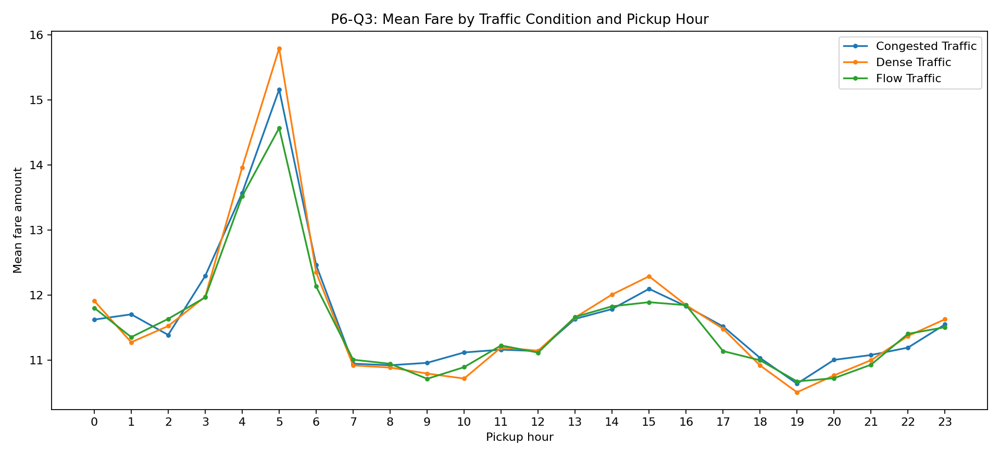

In [ ]:
# Verified Phase 6 visualization — embedded from the completed project artifact.
print("This cell displays the locked Phase 6 visualization; the underlying analysis was not rerun during notebook assembly.")

### 11.4 P6-Q4 — Distance/Fare Structure

The completed Phase 6 analysis examined the distance/fare relationship across trip-length ranges using a trip-level scatter plot and a supplementary fare-per-kilometer grouped view.

The analysis used **484,715** positive-distance observations from the **499,965-row** analytical dataset. It found that total fare increases with distance while the typical fare per kilometer declines as trip length increases.

The project explicitly treats fare-per-kilometer as a supplementary descriptive ratio, not as a causal or pricing rule.

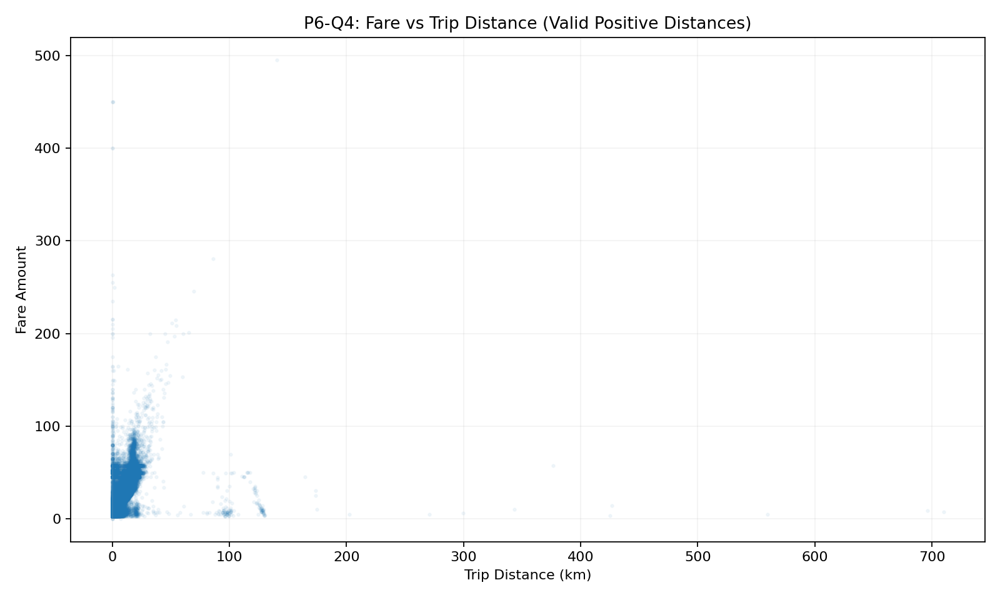

In [ ]:
# Verified Phase 6 visualization — embedded from the completed project artifact.
print("This cell displays the locked Phase 6 visualization; the underlying analysis was not rerun during notebook assembly.")

### 11.5 P6-Q5 — Numerical Predictor Redundancy

The Phase 6 redundancy analysis examined correlations among numerical predictors. The purpose was to identify highly overlapping reference/geographic variables before modeling rather than to delete features automatically.

The documented Phase 7 follow-up confirms substantial redundancy, particularly among the **EWR / SOL / NYC** reference-distance group.

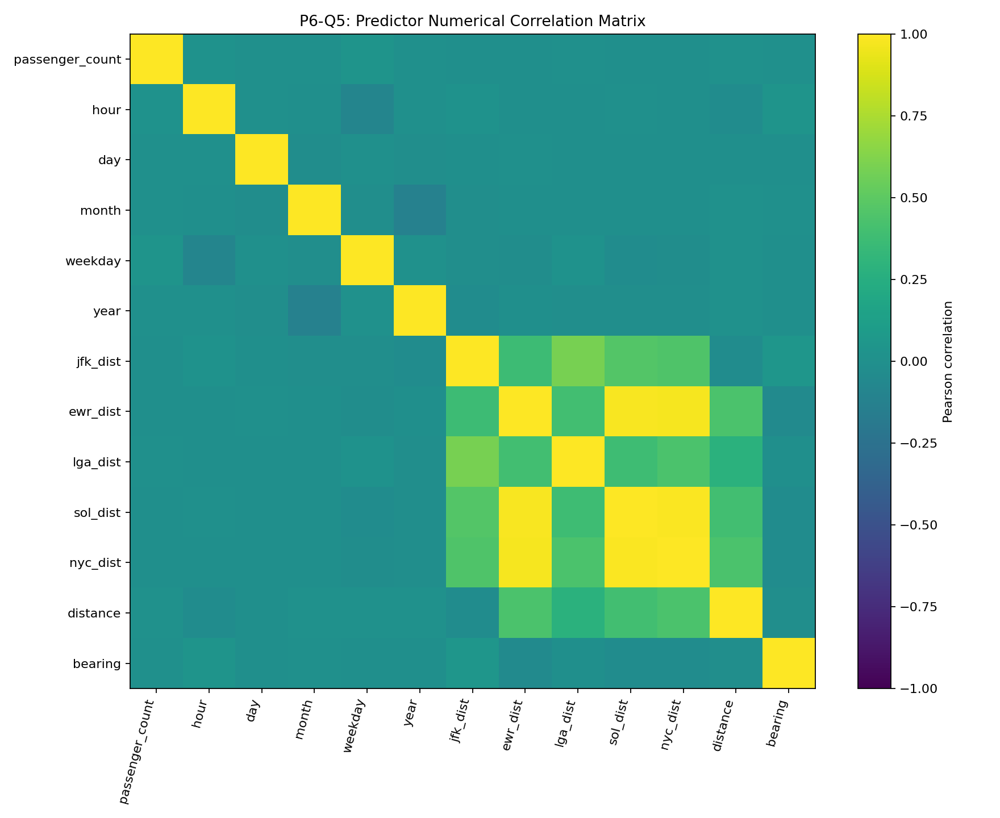

In [ ]:
# Verified Phase 6 visualization — embedded from the completed project artifact.
print("This cell displays the locked Phase 6 visualization; the underlying analysis was not rerun during notebook assembly.")

### 11.6 P6-Q6 — Calendar-Time Patterns

Phase 6 also examined how trip volume and mean fare changed across calendar time. The analysis was descriptive and used the observed `year`/`month` structure without claiming causal explanations for temporal changes.

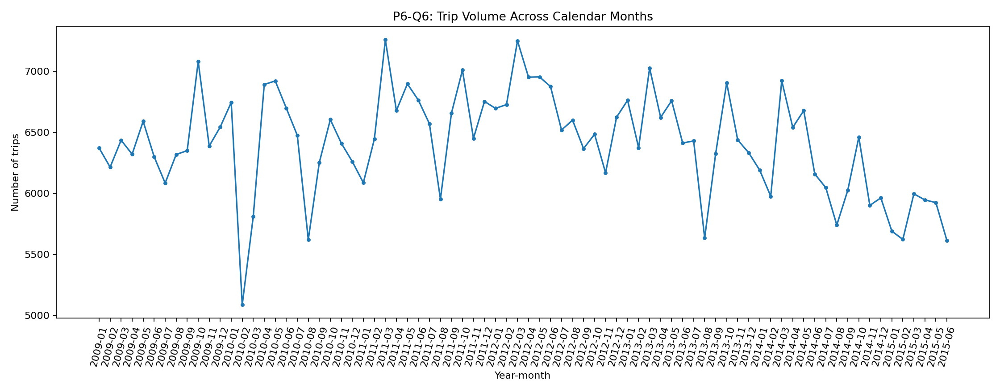

In [ ]:
# Verified Phase 6 visualization — embedded from the completed project artifact.
print("This cell displays the locked Phase 6 visualization; the underlying analysis was not rerun during notebook assembly.")

### P6-Q4 — Fare per Kilometer by Distance Range

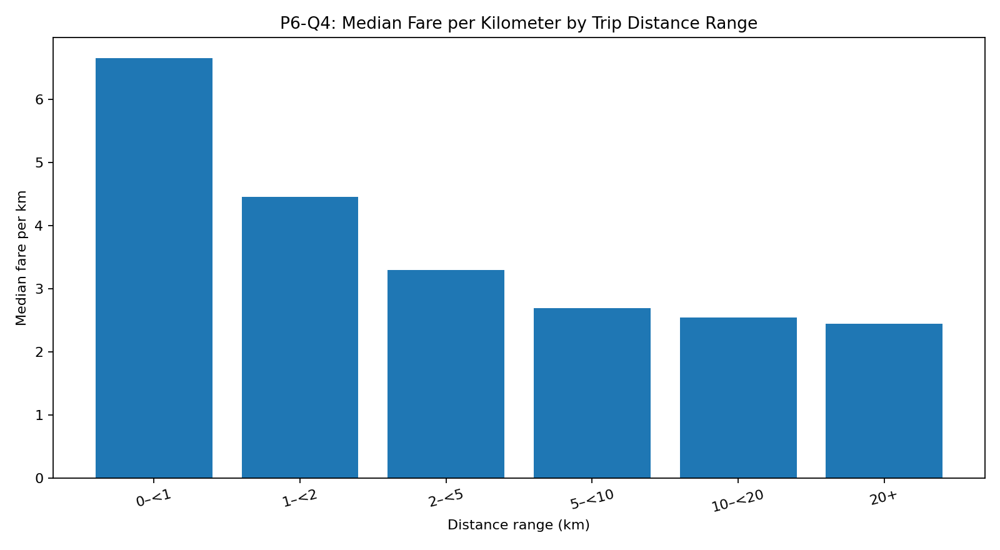

In [ ]:
print("Verified project visualization — preserved as an embedded output.")

### P6-Q6 — Monthly Mean Fare

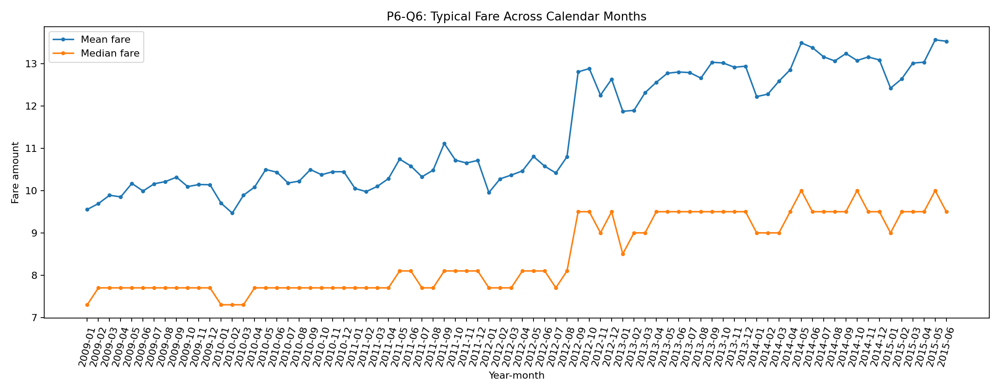

In [ ]:
print("Verified project visualization — preserved as an embedded output.")

# 12. Phase 7 — Analytical Findings and Modeling-Risk Audit

Phase 7 was completed as a structured pre-modeling audit. It did not modify `df_clean`.

The sections below preserve the documented findings without turning them into new modeling claims.

# 12.1 Phase 7 Findings

## 6.1 P7-Q1 — Fare Target Behavior and Meaningful Extremes

### Question
What does the target distribution look like, and what does its upper tail imply for later modeling?

### Analysis
The approved target-distribution summaries, upper-tail thresholds, and existing plots were reviewed.

### Result
- Mean fare: **11.3594**
- Median: **8.50**
- Q1: **6.00**
- Q3: **12.50**
- P90: **20.50**
- P95: **30.50**
- P99: **52.136**
- P99.5: **57.33**
- P99.9: **80.00**
- Maximum: **500.00**
- Skewness: **4.8999**
- >100: **214** observations
- >200: **26** observations
- >300: **7** observations
- >400: **5** observations

The approved P99+ group had mean fare **64.6381** and median **57.33**. High fares were not exclusively associated with long recorded distances in the approved evidence.

### Visualizations
![Fare distribution](../reports/phase7/P7_Q1_fare_distribution_p99.png)

![Upper-tail fare vs distance](../reports/phase7/P7_Q1_upper_tail_fare_vs_distance.png)

### Finding
The target is strongly right-skewed with a pronounced upper tail. This became a documented modeling risk rather than a reason to delete observations.

## 6.2 P7-Q2 — Distance/Fare Functional Form

### Question
Is the distance/fare relationship adequately described by a simple linear form, and does a transformed view reveal additional structure?

### Analysis
The verified raw Pearson/Spearman relationships and log1p-transformed correlations were compared with the binned median evidence.

### Result
For positive, nonmissing distance/fare observations (**N = 484,715**):
- Raw Pearson: **0.682655**
- Raw Spearman: **0.856920**
- Pearson `log1p(distance)` vs raw fare: **0.762296**
- Pearson `log1p(distance)` vs `log1p(fare)`: **0.866498**
- First equal-frequency distance bin median distance: **0.4533 km**; median fare: **4.10**; median fare/km: **9.8015**
- Last equal-frequency bin median distance: **14.5729 km**; median fare: **37.83**; median fare/km: **2.5055**

### Visualizations
![Distance binned median](../reports/phase7/P7_Q2_distance_fare_binned_median.png)

![Log1p distance/fare](../reports/phase7/P7_Q2_log1p_distance_fare.png)

### Finding
The distance/fare relationship is positive but not well represented by a single simple linear pattern. The transformed and rank-based evidence supports considering nonlinear/transformed representations during modeling.

## 6.3 P7-Q3 — Distance/Fare Relationship Stability Across Time

### Question
Does the positive distance/fare relationship remain present across different times of day and calendar groups?

### Analysis
The approved daypart, weekday/weekend, and hourly Pearson summaries were used. No model interaction was fitted.

### Result
| Group | N | Pearson | Spearman |
|---|---:|---:|---:|
| 00–05 | 61,780 | 0.791382 | 0.895418 |
| 06–11 | 116,925 | 0.660364 | 0.846825 |
| 12–17 | 139,283 | 0.636924 | 0.837978 |
| 18–23 | 166,727 | 0.721940 | 0.868097 |
| Weekday | — | 0.668272 | — |
| Weekend | — | 0.724686 | — |

Hourly Pearson correlation ranged from **0.422392 at 17:00** to **0.889246 at 06:00**.

### Visualization
![Distance/fare by daypart](../reports/phase7/P7_Q3_distance_fare_by_daypart.png)

### Finding
The distance/fare relationship remains positive across all examined temporal groups, but its strength varies. This supports considering temporal variables in modeling; it does not prove a causal interaction or guarantee that an interaction feature improves performance.

## 6.4 P7-Q4 — Reference/Airport Distance Redundancy vs Target Information

### Question
How redundant are the reference-distance variables, and what descriptive target information does each provide?

### Analysis
The already-completed P7-Q4 correlation matrices and target-association outputs were integrated. **The omitted conditional distance-band diagnostic was not rerun.**

### Result — reference distance vs fare
| Feature | Pearson r | Spearman r |
|---|---:|---:|
| `jfk_dist` | -0.265021 | -0.187893 |
| `ewr_dist` | 0.275987 | 0.147962 |
| `lga_dist` | 0.079585 | 0.054560 |
| `sol_dist` | 0.248432 | 0.108968 |
| `nyc_dist` | 0.290524 | 0.148133 |

### Result — strongest redundancy
- `sol_dist ↔ nyc_dist = 0.992120`
- `ewr_dist ↔ sol_dist = 0.977466`
- `ewr_dist ↔ nyc_dist = 0.969378`

Each reference-distance variable has **10,294 missing values (2.058944%)** and pairwise redundancy calculations used **489,671** complete observations.

### Visualization
![Reference-distance redundancy](../reports/phase7/P7_Q4_reference_distance_redundancy_heatmap.png)

### Finding
The EWR/SOL/NYC variables form a highly redundant group, while target associations differ by variable. This is a modeling-risk consideration rather than a feature-selection conclusion.

## 6.5 P7-Q5 — Consolidated Data-Quality / Modeling-Risk Audit

### Question
What data-quality and modeling risks remain after cleaning and EDA?

### Analysis
The verified audit consolidated target integrity, missingness, numeric integrity, temporal consistency, duplicate/identifier structure, categorical domains, redundancy, and leakage-risk considerations.

### Result
- `fare_amount` missing: **0**
- `fare_amount <= 0`: **0**
- Exact duplicate rows: **0**
- Distinct duplicated `key` values: **34,066**
- Excess rows associated with duplicated keys: **38,792**
- `pickup_datetime` missing: **0**
- Temporal field mismatches vs datetime: **0**
- All Phase 3 distance/reference-distance threshold checks: **0** invalid remaining cells
- Bearing outside `[-π, π]`: **0**
- Reference-distance redundancy: strongest accepted pairs are the three listed above

### Visualization
![P7-Q5 audit status](../reports/phase7/P7_Q5_audit_check_status.png)

### Finding
The cleaned dataset is structurally consistent while intentionally retaining documented missingness and duplicate-key structure. Identifier-like fields were treated as leakage-risk considerations; the audit does not itself establish leakage.

### Control boundary
P7-Q1 through P7-Q4 findings used here were imported from their approved outputs. The omitted P7-Q4 conditional distance-band diagnostic was **not executed**.

### Phase 7 — Target Distribution / Upper Tail

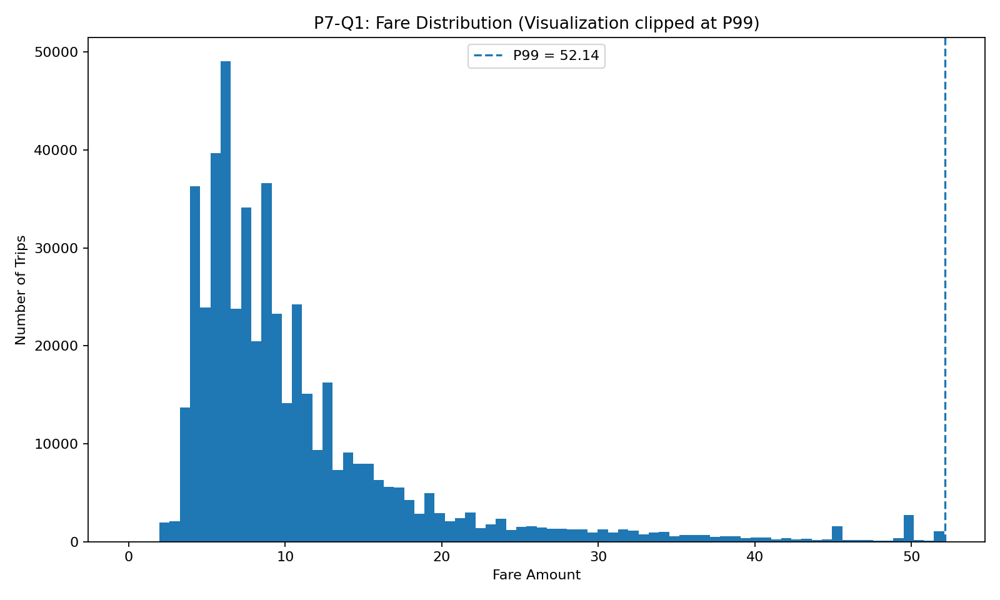

In [ ]:
print("Verified Phase 7 visualization — embedded from the completed project artifact.")

### Phase 7 — Upper Tail Fare vs Distance

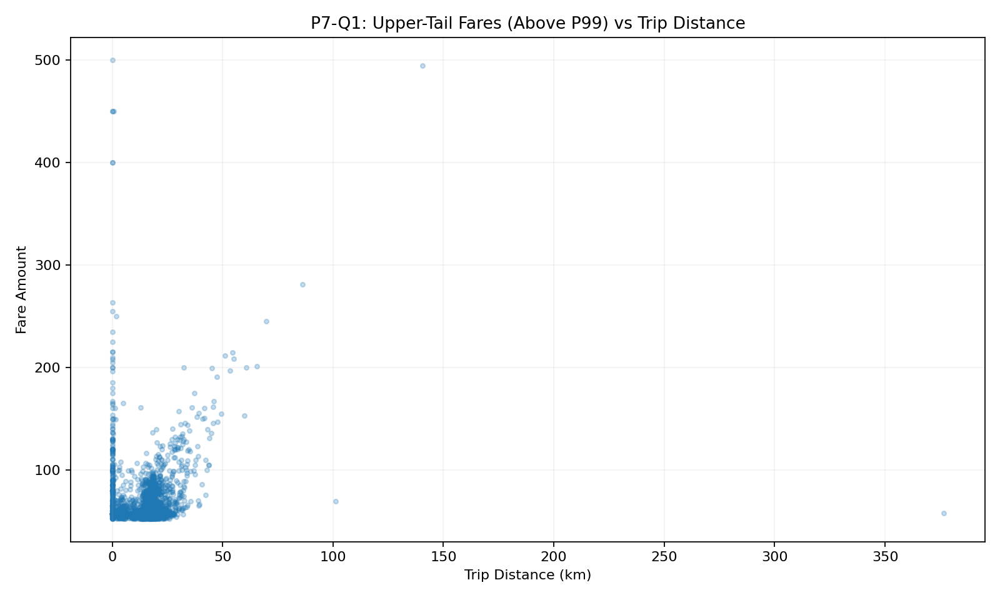

In [ ]:
print("Verified Phase 7 visualization — embedded from the completed project artifact.")

### Phase 7 — Distance/Fare Binned Median

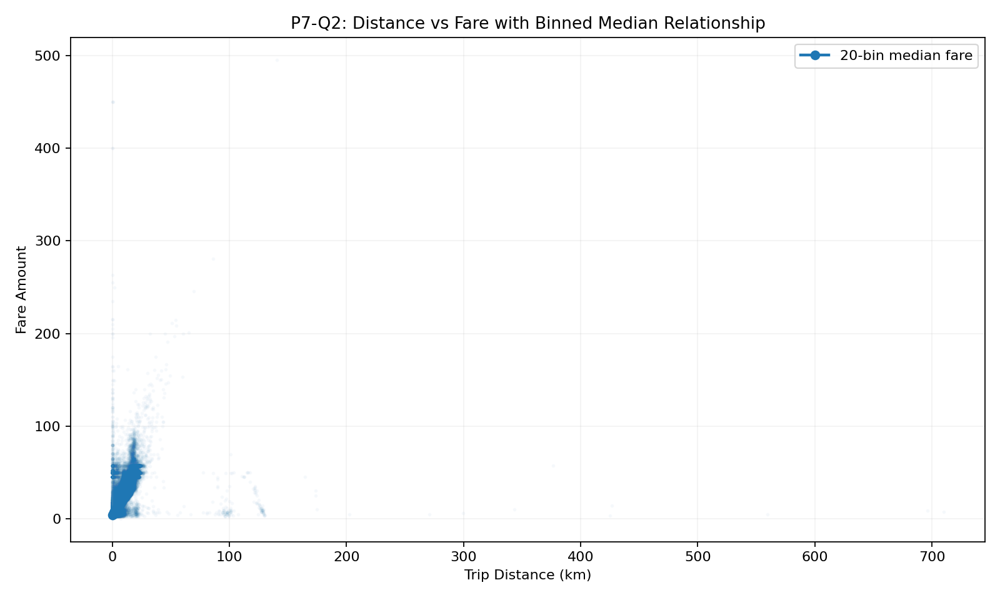

In [ ]:
print("Verified Phase 7 visualization — embedded from the completed project artifact.")

### Phase 7 — Log1p Distance/Fare

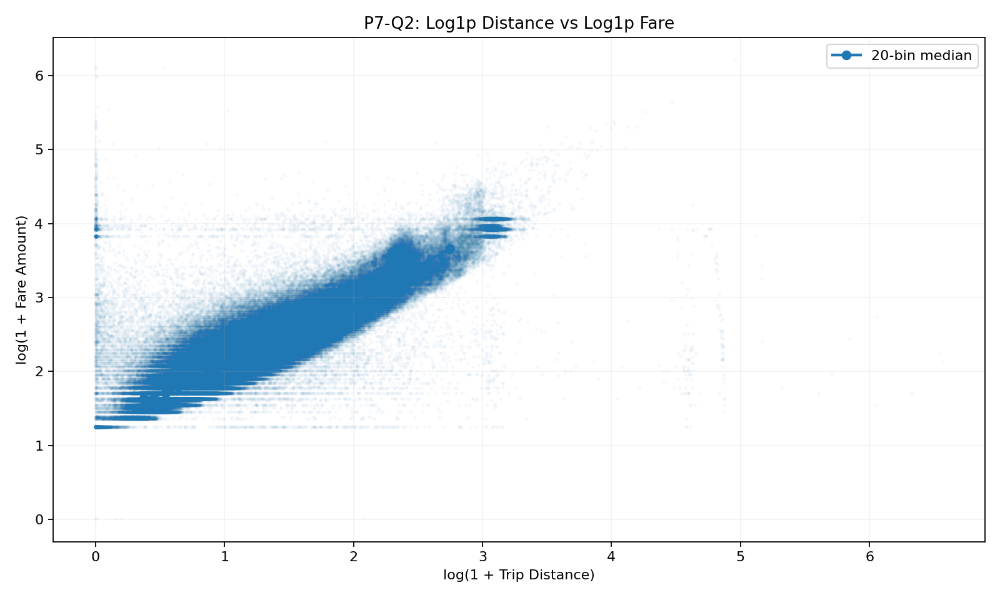

In [ ]:
print("Verified Phase 7 visualization — embedded from the completed project artifact.")

### Phase 7 — Distance/Fare by Daypart

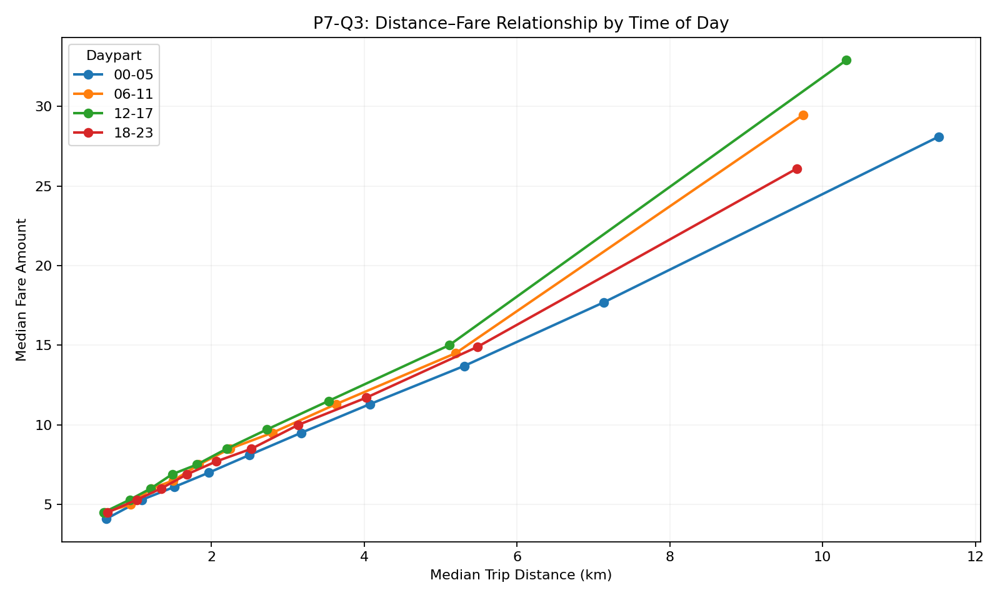

In [ ]:
print("Verified Phase 7 visualization — embedded from the completed project artifact.")

### Phase 7 — Hourly Distance/Fare Pearson

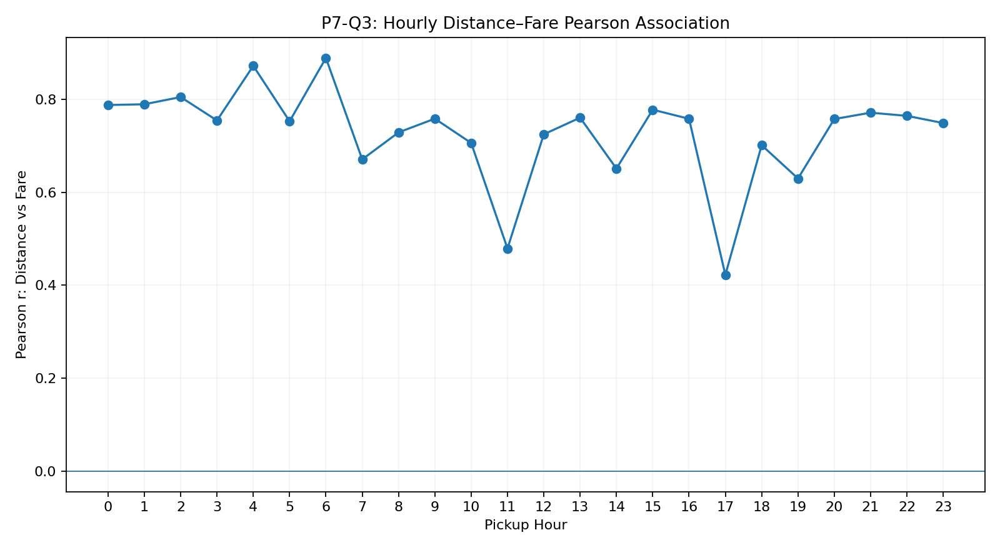

In [ ]:
print("Verified Phase 7 visualization — embedded from the completed project artifact.")

### Phase 7 — Reference Distance Redundancy

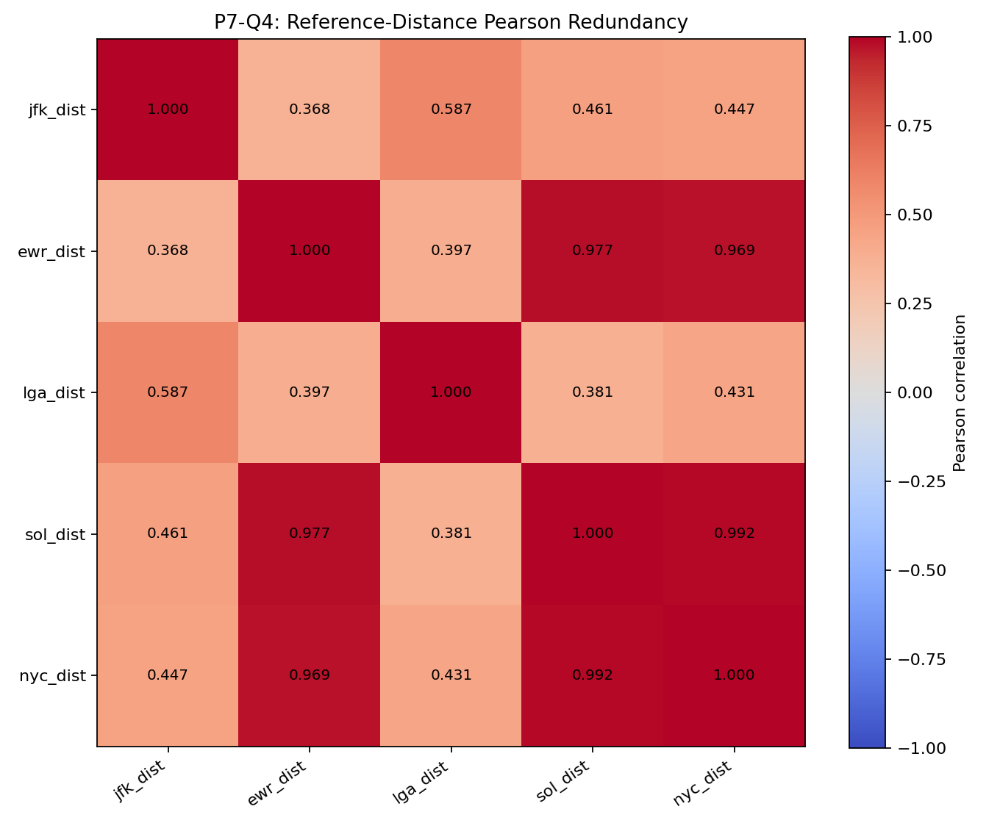

In [ ]:
print("Verified Phase 7 visualization — embedded from the completed project artifact.")

### Phase 7 — Reference Distance Target Association

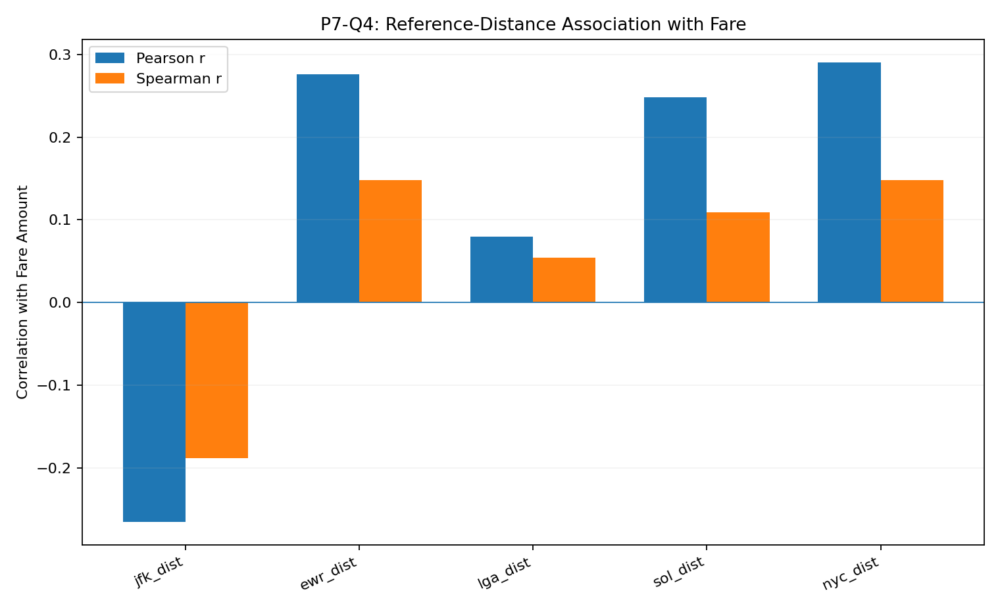

In [ ]:
print("Verified Phase 7 visualization — embedded from the completed project artifact.")

### Phase 7 — Data-Quality Audit Status

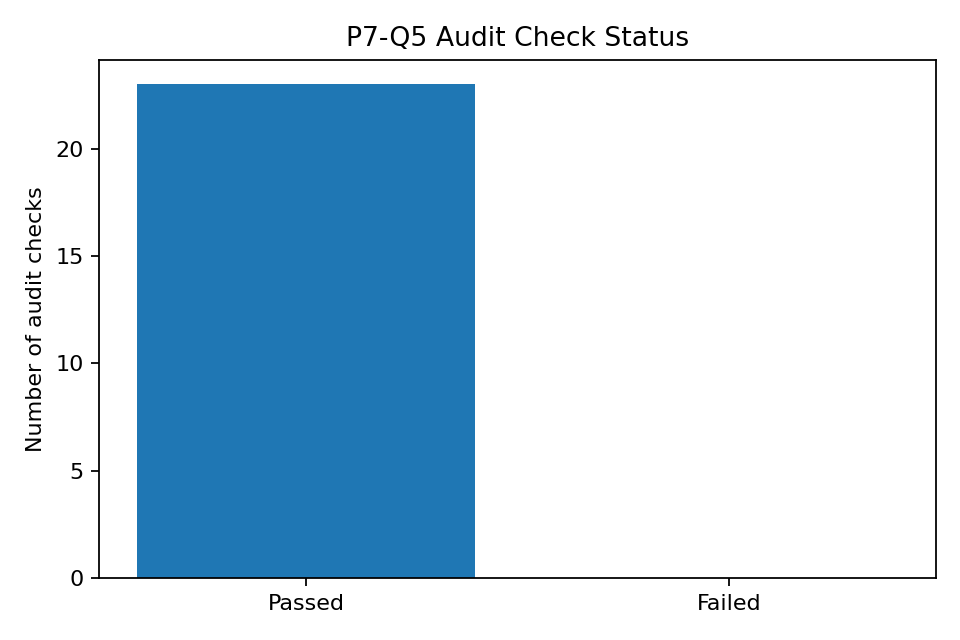

In [ ]:
print("Verified Phase 7 visualization — embedded from the completed project artifact.")

### Phase 7 — Missingness Diagnostic

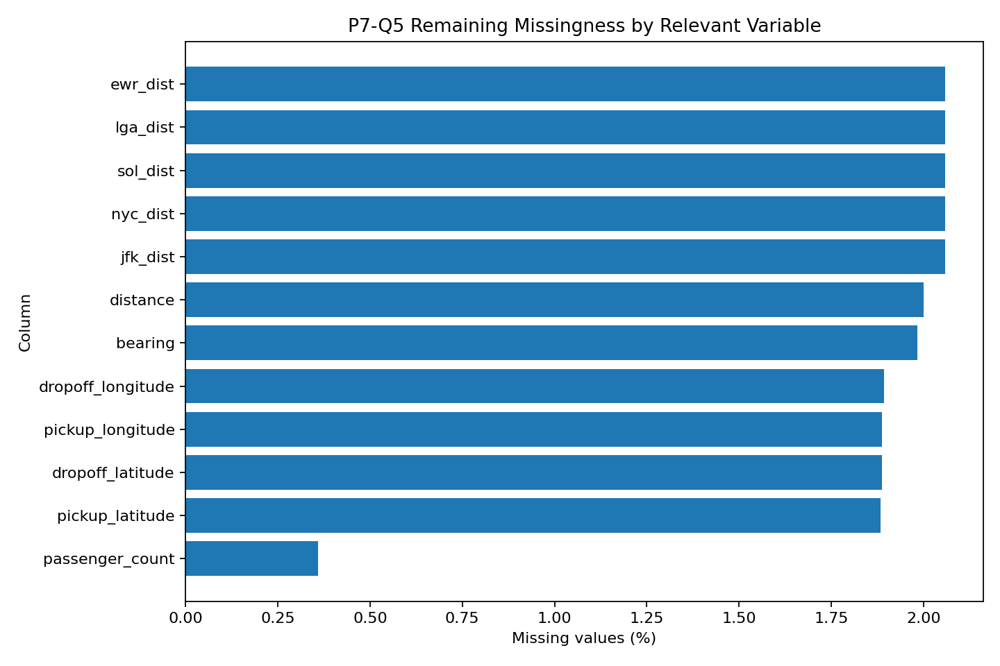

In [ ]:
print("Verified Phase 7 visualization — embedded from the completed project artifact.")

# 13. Modeling Problem

## Formulation

This is a supervised **regression** problem with continuous target `fare_amount`.

### Excluded predictors
- `fare_amount` — target
- `key` — identifier-like
- `User ID` — identifier
- `User Name` — identifier/name
- `Driver Name` — identifier/name

### Approved candidate feature pool

The final candidate pool included:
- `log1p(distance)`
- passenger count
- hour
- weekday
- month
- year
- pickup/drop-off coordinates
- bearing
- JFK/EWR/LGA/SOL/NYC reference distances
- Car Condition
- Weather
- Traffic Condition

### Locked chronological split

| Split | Period | Rows |
|---|---|---:|
| Train | 2009-01-01 → 2013-12-31 | **390,567** |
| Validation | 2014-01-01 → 2014-12-31 | **74,607** |
| Test | 2015-01-01 → 2015-06-30 | **34,791** |

**0 duplicate keys crossed the three splits.**

**Random state:** 42

The test period was untouched during model selection.

# 14. Controlled Modeling Experiments

The values below are the locked validation results from the completed modeling artifacts. No experiment is retrained by this notebook.

| Experiment | Main change | MAE | RMSE | R² |
|---|---|---:|---:|---:|
| E01 | Constant baseline | 6.520924 | 11.381812 | -0.033938 |
| E02 | Ridge baseline | 4.008651 | 7.736223 | 0.522328 |
| E03 | HGB baseline | 2.856050 | 6.003070 | 0.712380 |
| E04 | `log1p(distance)` | 2.856050 | 6.003070 | 0.712380 |
| E05 | Temporal enhancement | 2.498246 | 5.447252 | 0.763175 |
| E06 | Geographic enhancement | 2.129567 | 4.807872 | 0.815508 |
| E07 | Reference distances | 2.113989 | 4.746566 | 0.820183 |
| E08 | Categorical enhancement | 2.112468 | 4.741573 | 0.820561 |
| E09 | Training-only imputation strategy | 2.094547 | 4.733094 | 0.821202 |
| E10 | `log1p(fare_amount)` target | 2.039646 | 4.968136 | 0.803003 |

### Selection rule

E10 had the **lowest validation MAE** and was selected under the predefined validation-MAE criterion.

E09 had better validation RMSE and R², so the selection was not an across-the-board metric winner; it followed the declared selection rule.

In [ ]:
# Embedded locked Task 2 validation artifacts.
_TASK2_ARTIFACTS = {"task2_experiment_results_validation.csv": "H4sIAMQkt2oC/+VYXY/buBV9319B+KmLkQVS/N5BH7KLoNuHtEB20X0UOBZtq9GHS8mZBIv+955LyfYki7TYdhCgCQYe2BRJUeece++5iu9OMbV9HOa6bYrp1LXz8r9u4r4d2rkdh2IO6RDneppTmOPhfbGPYT6nWE9xLk4pntK4i9PUDofblH5sYlcPoY/F8T1ucQoJ3+eYpuLVi5fF61c/4V9VYDpugoUzzoD9duPQTLRn0+7o1h+OD+Mcp29eclHj9zQHHPohTLFrh1i8DV3bhOW4tOkfK879tuJC3rPbNYwKdc+wzUxf9Y+iSOGx3ocUi+ueeX3dxzDgjtj65/WQrzDy/eV+m183mxSGZuzx0HjmzeY7pqp/bgpT6or7SlXCVM4qIQohSumEE8JKZQQuyWLLSy6ll05awbX21nJXYKzwpZTGeu8lxrBH3HJd/LCejN2AYfEf59CxeWQXCLdgg9Gh79kwsi6GNMSGfUBPCeyqOrXNIT4ncJumpePtYnEK0xSHQ0wg6DzMm6LHecNQD+ceKtvVbX86z3m/O1rRhNTU0w43GQ7FazpWhjV0p2MgPAUAYZ+AWZWcO6P58ue1LGxppakqwKpl5bQWAFTjd2W90EII7XVFGBullAT6nHMpDDc0xpWQ1jsF4D0ucgHMU2TruQH0Ba77DxFl+3ZmYONCAgNaAQPde8Ja1sfDw2dCesDit/GKdN8uAXkEdhneH7HyTyk0LUL9+3GcZgy+joeE5xhThh2K6d4D5fF0wjUCeh+6KRIDWU20XVop4KWg8T68q1sEdSaL88sQpu/rARlgogtymYqQmkJ/6uKUr9OV6tP0VqXTBsQKq4yx4BdxBb645QKouQqhBd6sqKTjFZhVRD3R67mqtKucAr0VNx5DQijrFS4Tu85j5V/AEBgJ6corO2c6ccLIdkT9muMmFiaGqCE6VX2BvyYNRBCwiPk5mO3Ggzj94XKDb383wfcs78CuCvlaCHeGOyRLTexiHQ0JygzWW0chLq0RxV8RkawPfx8T2wGxA/hNYw9iJWsnBja7sCP+wccVQfbYzkf2ES+kA13PsT+NKXR1HI40TPXzM4igOI7nVDzG+KYJVGKH+Vi8B1NfgTiUd5XS1mkvkfSVKXSplK006qyRlN9JHEYKq6VVUmgUAErsXjulvLSclOC4WrIBSqvxBnrBAqT6F00zsfiuzSiwC7fgLLXhASekKovoz3V1iI+3GZccQaIw9SGOhxROR+D/mWVxOdDdbhxT00IMcbp7AEvE3JevDVF5baxw4J0+Ct7Aceus8LaSBiaKioATWnNLeQO1wXBfiFIJDwlVmpwA90qTOJBwIB1FRgATrfxIHDeAGc7CVozhAmLXrDrRWSewvH0YgOBFJAyEoc7EtPowixqyjylSNblC/79rBUJkdyx0ECdIZ9d7bK9Z7Srrr0AYQqLeSy0VOJaQBWqLNnDbEn7cK3LcDgC6CknFWG3JM4rSGJhCyCZrwIosi8q6CnWE5xpTraoglOEVUuxw2+bfYk2aGIiOfnyLqdPYRRSk5hxJM5c9QC0pw9U76qHGbDyfO5VAeNDHD3A+aCqapb1jv0Cix5gKhk5nv293t2uX7HFxwmwVCbuIBJudyMhP7MmhWTOj5/sS9FMp4ySsBNckBBKQ0OjiYCqEEVrqRUEayoDlgGlB54d1MCYaqkKv59GL+Fx1kJ80nAxZUKOd1auEdjO1cePDFBMJ4ymIt/pDRmQ8z5DPbmzW/OGv8Qrmz/HWeT9HDnHXrEUt/rXDHLOLyi0du7VybA9XddHHHetB7Haf0J9S9nv6QHdsSZ4dcuHyIP9/kqA6gaJheOVRJCxJAp0kekaPHMEXk+oqEI2qgz5EWWNcIUt0pRASaYR8iFwEASEJmztOC7OCmJvT2HWkgrE/gfwJ2IYDsJ9mRpysobjyvs28XwOxZH8mRmKilpTS0ae6UsHrHJf18lbnv9fLaktIMnXoyYh8Wzx5QzGxdngb0xS32HaYIBIoh9IdLWDU9cfNb6T2n7PNF5hmuPRGGeEgB+U0pKBKb5yQ2sPYcKt59i/ohdDMGBQ0Ja2mNKO9QxKygtKMqaiaCeNgXgwXPHe/aIZ+oob2CcLZtuQXfEtj6+6zLtgihoWWtUUiWyvyq7ZVl/Wegre+qbP4nYpBqx13pM3cfN2mPhH8s825jW67cfcm51YUtYas25NpJIdlO3rbmM5dJgY6GB9x8Kd7v3rx8p7Re0s2t3H7kGJ4s9k8O6v0DpA+f7sdP/NzPWMuAqkpUcMvj3ODY6TopwS7PjJSwXfs44gv2c/0aMM4I0KnU15afvMvSYvidwkWAAA=", "task2_validation_ranking.csv": "H4sIAMQkt2oC/+VYXW8jtxV9319B6KmB6QG/OazRhyQwmj5sC2wC9HFAayhp2vlQOCPvGkX/e8/lSLJ3k7RFYCyQLAwbY3JIXp1zeO+5Sh+OKXdDGpema/l87Ltl/du0adeN3dJNI19i3qelmZccl7R/4rsUl1NOzZwWfszpmKdtmudu3D+/Mkxt6psxDokfnnDEMWY8LynP/O3X9/zd2+/xR3G8jkOwcEEM2G87je1Me7bdlo7+eHycljS/uZei6ae9PDZrXPwx9l0b10hpvz8pIcKtElLfsec5jEpzx7DDQo/2O8k3ZZs/7CI+Sxym07h8xdnz4TPrxkdEnG6x7Tjvpjykli0TowVs3sY+bfi9qNkZD0Z4jDjsMbHxNADXLRu6Agw7xLHt6eGGbQmhCZOxZ+0CcO5YiYO13bzEcZv4d3j4c45tB1q+maZ5wcJ3aZ8B8pT55l+bTYq5fwLa0/GIuc3mj4ipnxNnm02PuQIpMUEzopI0PsQPTQcCaEgKcRnC67tmBFszTej11W5s5jgc+zSXeZpRZQVwaKcBB5/3NurfG64qoYMzTtbaSFNb67ipgqultkEFK7wVgYuqFloIrV2og9HeBqyzoXbSeilDCE7VeEm6urbGCUQohBJB8e+hm5cIM4TAikRZnBngv2PT2D+xVQwrLWwLvPdprt7ci9CcOWighVN6luivlk2O7xuSwE+4v6j5tgQEsXRxZN1wPC1lKwYFXYVxwwYQe7vL6ccTaP5IFTdsym034imN2wlP+9+gJIKxxisnVDAmeCjCa41BHaTyQtWeFKGkEkoGZWvjnau5rhQEUmtRO9Cva02K8NJDVx4SCcZDW99O45Knvsdd3E4DEks3A9u4B/bzQoJg5zt45v228H69gRX7CzGSMtt1y4JNsPhCHAPnsciJlFM3L0hp0nigy0mp8hWks7kXHjx/GzPD52nXPMv+DjEdUubshxx3O6jkOrf5PxLLEY+4Er/D/CKlMpCF9UEgW1gSk0He0EZrL5FBtC1qEtbhZGgnWKQOrFNKWVkrR/nF6mBWOdUWsiM5OVt7y79u25nF7XICXtPDnPIjKesFiI+QWHxAsOx9txym08JyWq8lqcQ3Oe1Sxk1NzRXh18gtDpTGvodMQfv1jNvLGc9hnaXRnKVxzXcXafwe+NeoGtpqY7XQhX5nnQ1IKbUMpl7ZB9NBO+ett1ZyWTnnhHNGGVCtSTaIVPlaeagEQ8hC+kw+UN5OOac+UkL4b1jfsXEaiY5hIpnMU5+Q6lvkF/iCyx6glpThmn2a9jkeDyDlldPH6lwu8X3Fj3GeE0pebrbkY/iShuOUY3+zndZagm1uHkAd0fkFCAa+w+GmG11+DSRTC197GbzSkIQshkRamJNgjVY1LEeAZAzU5JE0NNkPVDCSjBZewZMUFaFunTWTPnQFBvYMcHEmZ4xxa1OP16CKe2FJNQwueIgj1fqLZwBh3ZhSPmcS21xY+9xqQVLL/H1K/2wjWfdxOfAnfI4vQCgm1MpYX1tkDiuM47YyUIBVRjlYFeQRUXmnpbfaQ0gWSnAYCnAsBklFFJsiSmGRsDneBUeFRUshP9HJhdsX5aSIwxRxjOn98xtnfRT7qpvD/qF5iHMC4K9RWDZXsj5Rwf9k+7fHLsgSVkhUC+dhCrirQJfwAvVf1Go1oV4qMKgs5QEHw0DsCgNLiqRQehAXVnZ9MJgm31AHrPwrbCIYgYG7kMNOxZHN1LCgFFy7lnltVBTRaa4eoaHGOYGAtTn4DNf8C7jOv5JwWMZaB29VsQWBhiR8JPymr+mGa1gG/rfS1MV/oIlb20u2y9MAYjXrZjiCYx+3xD/4uCJYHCP7hBfSgWpy1+7TZ7rYayt65f25Jb2hFW3MbUN9M93xdxRWoTb2x0MsJFW/DLmpyHBbsf7AZHOPRg+wao1/kC1LBrX4X3lKp1ICd8JXOGMMzBxVWi1h1GhMGKl9qE3p9TAj0ezla8+DzHiB64599L0TtXK/3MdJwDDSB11eE+7rnmV9M6Q4cvKG/IdzEG8x8s3lPAL0ZwF0FfUqKDfSQZ5GwrjKCq62ltT2onNRRvNbYANA0RB7KSx8rxfkeQUPFfplao2hXo890q2w1CCXyF58lcXSj9TeoOBcv6Ogr1Io6FJ+yl2Fn/0I1erNfwAvgnS5HhQAAA==", "task2_final_verification.csv": "H4sIAMQkt2oC/81SQW7DIBC89y0+4Nh4zQf6gt7RsqxjFNdYLE7a35c6RFXbYy8V0gxiZlYjsTQzXZrohNOVfcNvG1Mulw1FniTuidjOKLN1PMXETduCmk5A0CEAeCSvqIf25ECrcSTyrqXy6oCM1t0wen3qTLE6h95oZf4+4CXt/K0ZTpnTfynmJ0sL42pTvEnTG2MG/aDDkBOGqnZG6QEedKhXXILHHGK1QD8oqHiPs+Sa7sG0FQ+JUhSxsi0hW78XIsxsL/wujSrnK/4aRMJ6thnTmfMPcRf29bPtFFZc7BLLhjzjIlzxMG+Jhdd870qJ8XNrfrk+AIOpKD9fAgAA", "task2_split_manifest.csv": "H4sIAMQkt2oC/22PfYrDIBDF/88peoAJzDhqNJcJoZEi29jdaPbj9p2maVkkMIjz3uP3NH9eY4FcxqVASBMst58Ma4pfaxg+wl+GaZXEeSzbOmz2FHOJ6VyGtzc9s0K5hPIM7fc55hzTBeaYhkmSJc4B5vH3vTRlGWMChehbJJkTYr+NaMQtqZbppLg3XgbYo7EdsHGoFVhCKzln2LwcrFBMPasKpUnwzfd4jfKKeHu0kz5o13V7py12YJ1RBoi08mBYd7uMNYYOMCjlTQm5PAxz0CmabRn//Vh3nuS0aIGtB3J617BmuJ5rBrteUXMHZT0KNeYBAAA=", "task2_split_validation_checks.csv": "H4sIAMQkt2oC/6WSS27DIBCG9z5FlE02jgR+lDgH6Am6qFRVCA/jGsUGi8Fpe/uCk7RWH6tKCOyZf755APQIp3xSRLlrCf0ZdY5vE0JAnZGbPaDsFfVyVAF6JHlz5g9+xpxzwbpCgCiVEEIr0AwqwYtW1OxwANAth2htBTR1Xd4ddF2UTZS2rdJNzZp/A241evdKl5Kqpmnu6utxc4Mb5tGSnAm1nDwS2nCRb592Wr3v8s2uUx6lGt1sQ/rtY2Q6T7h4R2dDnz4mA6d5kloFDGbEZKJpMEvMK+LpSntH5XfP28S/Er7xf+EsMetcV9YKu1T1vM2sk24OZPS6dZazLHhlrGyxczHbWQ0mJjDOXgQF4+WeF/uSb4ryWPEjY8lW7RmPa8PYkSVb9hV3IwWk8Mmovhg1i5hkq1eMw7FkmZ7jVCB2J2P/ErwjksugVrUq/4JBjobI2BcZXFDDD2/s5jG/VwPhes9SQekmJ+8AL/GdCelh/qFdrj72IkencZCEQ3zHaTI/9bqTMKCySWo68yvzAzXUmsM5AwAA", "task2_cross_split_key_examples.csv": "H4sIAMQkt2oC/xXHQQqAMAwEwLtv2T+VYFcaYptQU6S/F+c2xo1LJot0XyMRetqKUiWZ2onma6LKRveRDS9p/zZl4olb8/gAUqVEoUIAAAA=", "E10_validation_error_summary.csv": "H4sIAMQkt2oC/2XPsWoDQQwE0H6/5bJopZFWKlO4NAT7A8Il2cLgi+Fsh3x+ZEh1rvWYGS3jtp4+p5/5fB9l/7qbuJKEwZoLGlzVymF/3E2oYd5Eg0OpK0U58ETVSYhELDwgXaMsY/5+H+t6WacXqt09BNqdHUZoef46JZg/rpfz/Tb+ZauPmMxJTg1mKG9BW4UqgLtwYzIws6bSrbIKyqXM5hBn4KHiqTEZVKjnAy4hWpb5d4uYpbZMyPEh0V16+QOXLbbBMAEAAA==", "E10_validation_error_by_distance.csv": "H4sIAMQkt2oC/xWQO04DYQyE+70Kzi97/JbSUKRMAweIFggSBVsA9xdOOxp75puPr9+//Xi/397244MOuj5f6OX6eqHv+37cPvef+8ans5CIeJCsUGVGoYO5hZV8VRZjtOZw7hylU9tUor2tNDc5nUGQbJ4P0lpSrJ0mzlaEpTCRCEtLznKnXCEVKlZQFTXfcDo7Idh6XiRbwCATKaVFupDg1Gqp0Q1JgsWcATH2Eghs8+FgatWeyMpGNDq7rYVspRtQU3kyJ5WAhUFIDUQiQrHJLAGmKcSPg+wZBezWj/7TGT7YEsMGB5yMZ65Qz8KQTfcN/ETCeKwW5jW+EOYx2wy8SnWMXco1gSDP5amDXK6aMN3+AYrF6dauAQAA", "E10_validation_upper_tail_error.csv": "H4sIAMQkt2oC/yXGwQqDMAwA0LvfEkpq0ia5DHbwKIztA6RoNwWn0um+fxs7PHiPsh4b7GPJr3GdB1igPTdwbW8NPHNautTvR5r/30oepn6f1qV6p3ka0q/dPZV8uphBEEcExF/oAoqIqSiyIBJwdKom4iMzIYmAomOUaFGMEGvzELxDCoreKLBiXX0ARcMqAZ0AAAA=", "final_test_error_summary.csv": "H4sIAMQkt2oC/2XPO2oDQRAE0HzOMh6qP9Of0IFCgZEOINb2BAKtBWvJ+PiewJHUVFYPil7HbTt/1J/lch9l/7qr1NLFE5Lp1APK5bA/7mpvEUrz2ChY1cqBK5r3DFViArTPlHUsX6exbdetvsw6JSlMonuAobP+PE+wvH9fL/fb+JfUgIwOgCOFWMtb4hFpI5I0eLozAzFRf0TWYOYSiPkF96CJ8mlOGwelM5moGaZal9+nPUULFvNw9EzAyh82HP1QLgEAAA==", "final_test_error_by_distance.csv": "H4sIAMQkt2oC/xWQO04DYQyE+70Kzi97/JbSUKRMAweIFggSBVsA9xdOOx7NN+OPr9+//Xi/397244MOuj5f6OX6eqHv+37cPvef+8ans5CbOMlyqDuiq1xLzChXd0aUQIEoOPkqy8RoLqpVucnpDBI2qUkQ7eC5KrLBNYdVLAlHR3twoCc0tK1Z2WHcuuF0Hrq05djjQS6NYE5PIwzQ1aM4Ms1ZSbBk2NNoglvZYvMZwWSYBKys6HiscI3UVLI19Vmkwl0H7ASsaLMMGUomY5P5A5jEwsafBmSlTU9n6FT28ac/ErxkShhPrzZVDhZu9AZ+olHGW94CERZ4Nk+lXOqzP0RkFAuK2ek95Mef1AHb/gGe1gLqqwEAAA==", "final_test_upper_tail_error.csv": "H4sIAMQkt2oC/yXIwQqDMAwA0LvfEkqatklzGezgUZDtA6RoNwWnUuv/b7Db473Lfh1Q55LPeV8n2KC7t/Doni18ctqGNNYrrX8fJU/LWJd9a2o+6/BKJd96VQhiggfLDE6MZ0GN5EltZAJWgz7EEB0zEqOAohG1xAF/4VEZgjeopCLWiY3kbPMF53KzFJcAAAA="}

def load_embedded_task2_csv(name):
    raw = gzip.decompress(base64.b64decode(_TASK2_ARTIFACTS[name]))
    return pd.read_csv(io.BytesIO(raw))

experiment_results = load_embedded_task2_csv("task2_experiment_results_validation.csv")
display(experiment_results)

# 15. Final Model

**Selected model:** `HistGradientBoostingRegressor`

**Target transformation:** `log1p(fare_amount)`

**Inverse transformation:** `expm1()`

### Exact final feature list

1. `log1p(distance)`
2. `passenger_count`
3. `hour`
4. `weekday`
5. `month`
6. `year`
7. `pickup_longitude`
8. `pickup_latitude`
9. `dropoff_longitude`
10. `dropoff_latitude`
11. `bearing`
12. `jfk_dist`
13. `ewr_dist`
14. `lga_dist`
15. `sol_dist`
16. `nyc_dist`
17. `Car Condition`
18. `Weather`
19. `Traffic Condition`

The final model was fitted on **train + validation (2009–2014)** and evaluated once on the untouched **2015 H1** test period.

In [ ]:
# Embedded final model artifact.
_MODEL_B64 = """..."""

# This reconstructs the locked model artifact in memory; it does NOT retrain it.
import joblib
final_model = joblib.load(io.BytesIO(base64.b64decode(_MODEL_B64)))
print(type(final_model).__name__)

# 16. Final Test Evaluation

## Locked 2015 H1 test results

| Metric | Test result |
|---|---:|
| **MAE** | **1.973790** |
| **RMSE** | **5.884111** |
| **R²** | **0.759844** |
| Mean error | -0.793919 |
| Median absolute error | 1.009850 |
| P90 absolute error | 4.113961 |
| P95 absolute error | 6.066738 |
| P99 absolute error | 14.281972 |
| Maximum absolute error | 440.823679 |

These are the locked final-test values from the completed project.

# 17. Error Analysis

## Distance bands

| Distance band | N | MAE | RMSE |
|---|---:|---:|---:|
| 0–<1 km | 5,415 | 1.523553 | 7.997668 |
| 1–<2 km | 10,418 | 1.139603 | 1.801725 |
| 2–<5 km | 11,947 | 1.638148 | 2.845357 |
| 5–<10 km | 4,247 | 2.786963 | 4.232012 |
| 10–<20 km | 1,464 | 4.742279 | 7.569476 |
| 20+ km | 494 | 7.859121 | 27.359696 |

Long-distance observations have substantially larger absolute error in the locked test evaluation.

## Upper-fare tail

- Test P99 threshold: **57.54**
- Observations above P99: **166**
- MAE above P99: **37.467098**
- RMSE above P99: **69.045858**
- Mean actual fare above P99: **90.791265**
- Mean prediction above P99: **54.092977**

The upper fare tail remains a documented weakness of the final model.

In [ ]:
# Embedded locked final-test predictions and error-analysis artifacts.
_FINAL_PREDICTIONS_B64 = """..."""

final_test_predictions = pd.read_csv(
    io.BytesIO(gzip.decompress(base64.b64decode(_FINAL_PREDICTIONS_B64)))
)
display(final_test_predictions.head())

print("Final prediction rows:", len(final_test_predictions))

# 18. Dashboard / Interactive EDA Product

The completed project also contains a separate Streamlit interactive EDA application. It is integrated here as documentation of the final project rather than as a replacement for the notebook analysis.

### Dashboard sections

1. Overview
2. Fare Analysis
3. Demand Analysis
4. Passenger Analysis
5. Car & Traffic
6. Distance Analysis
7. Weather Analysis
8. Airport Analysis
9. Correlation Explorer
10. Data Explorer
11. Data Quality

### Interactive features

- Global filters for hour, car condition, weather, traffic, passenger count, year, and month
- Dynamic KPIs
- Interactive Plotly charts
- Distance robustness views
- Airport selector
- Pearson correlation explorer
- Searchable data explorer
- Filtered CSV download
- Reset All Filters
- Responsive UI

The dashboard remains an EDA product and does not perform model training.

# 19. Key Findings

### Task 1 EDA
- Passenger count has a very weak linear association with fare (≈ **0.017**).
- Car-condition mean fares are close and distributions overlap.
- **05:00** has the highest observed average fare (≈ **$15.37**) but only **507 rides**.
- Traffic-condition mean fares are close in the aggregate.
- Distance requires robustness analysis because extreme observations distort raw Pearson correlation.
- **19:00** is the busiest request hour with **3,117 rides**.
- Weather mean-distance differences are strongly influenced by extreme observations; medians are much more stable.
- Airport-distance correlations with fare are very small.

### Phase 6
- Demand varies by both hour and weekday.
- Wednesday at **19:00** is the largest hour × weekday cell with **4,879 trips**.
- Weekday mean fares vary modestly while medians remain highly stable.
- Traffic differences can be larger at particular hours than in the overall marginal comparison.
- Distance/fare structure is not a constant fare-per-kilometer relationship.
- Numerical reference-distance variables contain redundancy.

### Phase 7
- Fare is strongly right-skewed and has a meaningful upper tail.
- Distance/fare association is positive and becomes more regular on transformed scales.
- The distance/fare relationship remains positive across temporal groups.
- Reference-distance variables contain substantial redundancy, especially EWR/SOL/NYC.
- Data-quality risks were documented before modeling.

### Task 2
- E10 achieved the lowest validation MAE under the predefined selection criterion.
- E09 had better validation RMSE and R², so the selection criterion matters.
- Locked 2015 H1 test results: **MAE 1.973790, RMSE 5.884111, R² 0.759844**.
- Error increases materially in longer-distance bands.
- The upper fare tail remains difficult to predict.

# 20. Limitations

The completed project documents the following limitations:

- Extreme distance observations can strongly affect averages and correlations.
- Zero-distance and zero-coordinate records indicate geographic-quality issues.
- Zero-passenger records were retained as documented anomalies.
- Duplicate `key` values were investigated but not automatically removed.
- The highest observed 05:00 average fare is based on fewer observations than the busiest hours.
- Raw Pearson correlation can be distorted by extreme observations.
- Robustness filters are analytical checks, not universal invalidity rules.
- Airport-distance relationships are affected by geographic-data quality.
- EDA associations are observational and do not establish causality.
- The modeling target is strongly right-skewed.
- Long-distance and upper-tail observations are harder for the final model.
- Reference-distance variables contain substantial redundancy.
- The final metrics describe the locked dataset and temporal evaluation; they do not establish business ROI, deployment performance, or universal model superiority.

# 21. Final Conclusion

The completed project moved from structured data-quality investigation through required exploratory analysis, additional temporal/geographic analysis, modeling-risk auditing, and controlled regression modeling.

The EDA identified distance as an important numerical candidate while also showing why raw linear statistics must be interpreted alongside robustness checks. Temporal structure was evident in demand and fare behavior, while several categorical marginal effects were comparatively small. The later phases documented target skewness, upper-tail risk, geographic/reference redundancy, and other issues relevant to modeling.

For Task 2, the project used a chronological split and selected the **E10 log1p-target HistGradientBoostingRegressor configuration under the predefined validation-MAE criterion**. The locked 2015 H1 evaluation produced:

- **MAE = 1.973790**
- **RMSE = 5.884111**
- **R² = 0.759844**

Error analysis shows that longer trips and the upper fare tail remain the most difficult areas in the locked evaluation.

No causal or universal performance claim is made.

# 22. Reproducibility

## Verified environment

The completed modeling environment documented:

- `numpy==2.3.5`
- `pandas==2.2.3`
- `matplotlib==3.10.8`
- `scikit-learn==1.8.0`
- `joblib==1.5.3`

The Streamlit application uses:

- Streamlit
- Pandas
- NumPy
- Plotly

## Integrity

Task 2 `df_clean.csv` SHA-256:

`1170f27c73a777dacd0c4712b75088cc1cdacb7c955368d5239a77bbad9509`

Task 1 exported EDA CSV SHA-256:

`4a07558eefd7496b4d783f493366ce3cd8b93986fff5a85938f4872863005a40`

The modeling source data was documented as read-only during finalization.

# 23. Source-Code Integration

The project contained dedicated scripts for:
- Phase 3 cleaning
- Phase 4 baseline EDA
- Phase 5 Q1–Q8
- Phase 6 additional EDA
- Phase 7 target behavior
- Phase 7 distance/fare functional form
- Phase 7 temporal stability
- Phase 7 reference-distance redundancy
- Phase 7 data-quality/modeling-risk audit
- Task 2 split validation
- Task 2 modeling

The complete source scripts are preserved in the appendix below as archival code. They are included to keep this notebook self-contained as a project record; the notebook assembly did not execute or alter them.

### Appendix A — Phase 3 — Cleaning implementation

Source preserved verbatim from the completed project.

In [ ]:
import numpy as np
import pandas as pd

SOURCE = "final_internship_data.xlsx"

# 1) Preserve source exactly.
df_raw = pd.read_excel(SOURCE, engine="openpyxl")
df_clean = df_raw.copy(deep=True)

# 2) Remove invalid target rows only.
df_clean = df_clean.loc[df_clean["fare_amount"] > 0].copy()

# 3) Restore pickup_datetime from Excel serials when necessary.
if pd.api.types.is_numeric_dtype(df_clean["pickup_datetime"]):
    df_clean["pickup_datetime"] = pd.to_datetime(
        df_clean["pickup_datetime"], unit="D", origin="1899-12-30"
    ).dt.round("s")
else:
    df_clean["pickup_datetime"] = pd.to_datetime(
        df_clean["pickup_datetime"], errors="coerce"
    ).dt.round("s")

# 4) Passenger count 0 is treated as an unknown/missing value, not a reason to drop the trip.
df_clean.loc[df_clean["passenger_count"] == 0, "passenger_count"] = np.nan

# 5) Actual coordinate representation is retained as-is (it is consistent with radians).
#    Zero coordinates are treated as sentinel missing values.
coords = [
    "pickup_longitude", "pickup_latitude",
    "dropoff_longitude", "dropoff_latitude"
]
for c in coords:
    df_clean.loc[df_clean[c] == 0, c] = np.nan

# 6) Values outside the mathematical radian coordinate domain are invalid.
for c in ["pickup_longitude", "dropoff_longitude"]:
    df_clean.loc[~df_clean[c].between(-np.pi, np.pi), c] = np.nan
for c in ["pickup_latitude", "dropoff_latitude"]:
    df_clean.loc[~df_clean[c].between(-np.pi / 2, np.pi / 2), c] = np.nan

geo_affected = df_clean[coords].isna().any(axis=1)
geo_derived = [
    "jfk_dist", "ewr_dist", "lga_dist", "sol_dist",
    "nyc_dist", "distance", "bearing"
]
df_clean.loc[geo_affected, geo_derived] = np.nan

# 7) Keep ordinary statistical outliers; invalidate only clearly implausible NYC-scale distances.
df_clean.loc[df_clean["distance"] > 1000, "distance"] = np.nan
for c in ["jfk_dist", "ewr_dist", "lga_dist", "sol_dist", "nyc_dist"]:
    df_clean.loc[df_clean[c] > 1000, c] = np.nan

# Deliberately NOT done:
# - no Key-based deduplication (Key == pickup_datetime and is not unique)
# - no radians/degrees conversion
# - no category recoding
# - no column renaming
# - no Week column creation
# - no automatic IQR-outlier deletion

### Appendix A — Phase 4 — Baseline EDA implementation

Source preserved verbatim from the completed project.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Approved Phase 3 dataset; do not modify it during EDA.
df_clean = pd.read_csv("phase3/df_clean.csv", parse_dates=["pickup_datetime"])

# 1) Target: fare_amount
df_clean["fare_amount"].describe()
df_clean["fare_amount"].skew()

plt.figure(figsize=(9, 5))
plt.hist(df_clean["fare_amount"], bins=80)
plt.xlabel("Fare amount")
plt.ylabel("Number of trips")
plt.title("Distribution of Fare Amount")
plt.show()

plt.figure(figsize=(9, 3.8))
plt.boxplot(df_clean["fare_amount"], vert=False)
plt.xlabel("Fare amount")
plt.title("Fare Amount Boxplot")
plt.show()

# 2) Distance
distance = df_clean["distance"].dropna()
p99 = distance.quantile(.99)

plt.figure(figsize=(9, 5))
plt.hist(distance[distance <= p99], bins=70)
plt.xlabel("Distance (km)")
plt.ylabel("Number of trips")
plt.title("Distance Distribution (shown through 99th percentile)")
plt.show()

# 3) Passenger count
counts = df_clean["passenger_count"].value_counts(dropna=False).sort_index()
plt.figure(figsize=(8, 5))
plt.bar(counts.index.astype(str), counts.values)
plt.xlabel("Passenger count")
plt.ylabel("Number of trips")
plt.title("Passenger Count Distribution")
plt.show()

# 4) Categorical variables
for col in ["Car Condition", "Weather", "Traffic Condition"]:
    counts = df_clean[col].value_counts()
    plt.figure(figsize=(8, 5))
    plt.bar(counts.index.astype(str), counts.values)
    plt.xlabel(col)
    plt.ylabel("Number of trips")
    plt.title(f"{col} Distribution")
    plt.xticks(rotation=20, ha="right")
    plt.show()

# 5) Temporal distributions
hour_counts = df_clean["hour"].value_counts().sort_index()
plt.figure(figsize=(9, 5))
plt.plot(hour_counts.index, hour_counts.values, marker="o")
plt.xlabel("Hour of day")
plt.ylabel("Number of trips")
plt.title("Trips by Hour of Day")
plt.xticks(range(24))
plt.show()

weekday_counts = df_clean["weekday"].value_counts().sort_index()
plt.figure(figsize=(8, 5))
plt.bar(range(7), weekday_counts.values)
plt.xticks(range(7), ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])
plt.xlabel("Weekday")
plt.ylabel("Number of trips")
plt.title("Trips by Weekday")
plt.show()

month_counts = df_clean["month"].value_counts().sort_index()
plt.figure(figsize=(9, 5))
plt.plot(month_counts.index, month_counts.values, marker="o")
plt.xlabel("Month")
plt.ylabel("Number of trips")
plt.title("Trips by Month")
plt.xticks(range(1, 13))
plt.show()

# 6) Quick baseline correlations — not the deeper Phase 7 analysis
corr_cols = [
    "fare_amount", "distance", "passenger_count",
    "jfk_dist", "ewr_dist", "lga_dist", "sol_dist", "nyc_dist", "bearing"
]
corr = df_clean[corr_cols].corr()
print(corr.round(3))

plt.figure(figsize=(9, 7))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Pearson correlation")
plt.xticks(range(len(corr_cols)), corr_cols, rotation=45, ha="right")
plt.yticks(range(len(corr_cols)), corr_cols)
plt.title("Baseline Numeric Correlation Heatmap")
plt.show()

# 7) Fare vs distance
plot_df = df_clean[["fare_amount", "distance"]].dropna()
plot_df = plot_df.sample(min(30000, len(plot_df)), random_state=42)

plt.figure(figsize=(9, 5))
plt.scatter(plot_df["distance"], plot_df["fare_amount"], alpha=0.25, s=8)
plt.xlabel("Distance (km)")
plt.ylabel("Fare amount")
plt.title("Fare Amount vs Distance (30,000-point plotting sample)")
plt.show()

### Appendix A — Phase 5 — Q1–Q8 implementation

Source preserved verbatim from the completed project.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Approved Phase 3 dataset. df_clean is read-only for this analysis.
df_clean = pd.read_csv("phase3/df_clean.csv", parse_dates=["pickup_datetime"])

# Q1. Is higher Passenger_Count associated with higher Fare_Amount?
# Main visualization: scatter plot using all nonmissing passenger_count/fare_amount rows.
q1 = df_clean[["passenger_count", "fare_amount"]].dropna()
q1_corr = q1["passenger_count"].corr(q1["fare_amount"])

plt.figure(figsize=(10, 6))
plt.scatter(
    q1["passenger_count"],
    q1["fare_amount"],
    s=4,
    alpha=0.08
)
plt.xlabel("Passenger Count")
plt.ylabel("Fare Amount")
plt.title("Q1: Passenger Count vs Fare Amount")
plt.xticks(range(1, 7))
plt.grid(alpha=0.15)
plt.tight_layout()
plt.show()

# Supplementary grouped statistics (not used as the main visualization).
q1_grouped = df_clean.groupby("passenger_count")["fare_amount"].agg(
    count="count", mean="mean", median="median"
)
print(q1_grouped)
print("Pearson r =", q1_corr)

# Q2. Does Car Condition influence Fare Amount?
q2 = df_clean.groupby("Car Condition")["fare_amount"].agg(
    count="count", mean="mean", median="median"
)
plt.figure(figsize=(9, 5))
plt.bar(q2.index, q2["mean"])
plt.xlabel("Car Condition")
plt.ylabel("Mean fare amount")
plt.title("Q2: Mean Fare Amount by Car Condition")
plt.xticks(rotation=15)
plt.show()

# Q3. At what hour are fares typically highest?
q3 = df_clean.groupby("hour")["fare_amount"].agg(
    count="count", mean="mean", median="median"
)
plt.figure(figsize=(10, 5))
plt.plot(q3.index, q3["mean"], marker="o", label="Mean fare")
plt.plot(q3.index, q3["median"], marker="o", label="Median fare")
plt.xlabel("Pickup hour")
plt.ylabel("Fare amount")
plt.title("Q3: Typical Fare by Hour")
plt.xticks(range(24))
plt.legend()
plt.show()

# Q4. Does Traffic Condition affect trip fare?
q4 = df_clean.groupby("Traffic Condition")["fare_amount"].agg(
    count="count", mean="mean", median="median"
)
plt.figure(figsize=(9, 5))
plt.bar(q4.index, q4["mean"])
plt.xlabel("Traffic Condition")
plt.ylabel("Mean fare amount")
plt.title("Q4: Mean Fare Amount by Traffic Condition")
plt.xticks(rotation=15)
plt.show()

# Q5. Is trip distance the strongest predictor of the fare amount?
# Main visualization required by the official Task 1 PDF: trip-level scatter plot.
# No aggregation is used; transparency is only for readability.
q5_scatter = df_clean[["distance", "fare_amount"]].dropna()
q5_distance_corr = q5_scatter["distance"].corr(q5_scatter["fare_amount"])

plt.figure(figsize=(10, 6))
plt.scatter(
    q5_scatter["distance"],
    q5_scatter["fare_amount"],
    s=4,
    alpha=0.05
)
plt.xlabel("Trip Distance (km)")
plt.ylabel("Fare Amount")
plt.title("Q5: Trip Distance vs Fare Amount")
plt.grid(alpha=0.15)
plt.tight_layout()
plt.show()

# Supporting Pearson correlation comparison (not ML feature importance).
numeric_cols = [
    "distance", "passenger_count", "jfk_dist", "ewr_dist",
    "lga_dist", "sol_dist", "nyc_dist", "bearing"
]
q5 = (
    df_clean[["fare_amount"] + numeric_cols]
    .corr()["fare_amount"]
    .drop("fare_amount")
    .sort_values(key=lambda s: s.abs(), ascending=False)
)
print("Distance vs Fare Pearson r =", q5_distance_corr)
print(q5)

# Q6. At what time of day are ride requests most frequent?
q6 = df_clean.groupby("hour").size()
plt.figure(figsize=(10, 5))
plt.bar(q6.index, q6.values)
plt.xlabel("Pickup hour")
plt.ylabel("Number of trips")
plt.title("Q6: Trip Frequency by Hour")
plt.xticks(range(24))
plt.show()

# Q7. Does Weather Condition influence average trip Distance?
q7 = df_clean.groupby("Weather")["distance"].agg(
    count="count", mean="mean", median="median"
)
plt.figure(figsize=(9, 5))
plt.bar(q7.index, q7["mean"])
plt.xlabel("Weather")
plt.ylabel("Mean trip distance (km)")
plt.title("Q7: Mean Trip Distance by Weather Condition")
plt.xticks(rotation=15)
plt.show()

# Q8. Are rides that start closer to airports generally more expensive?
airport_cols = ["jfk_dist", "ewr_dist", "lga_dist"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
for ax, col, label in zip(axes, airport_cols, ["JFK", "EWR", "LGA"]):
    tmp = df_clean[[col, "fare_amount"]].dropna()
    r = tmp[col].corr(tmp["fare_amount"])

    # Reproducible supporting statistics from the full available data.
    q25 = tmp[col].quantile(0.25)
    q75 = tmp[col].quantile(0.75)
    closest_q1 = tmp.loc[tmp[col] <= q25, "fare_amount"]
    farthest_q4 = tmp.loc[tmp[col] >= q75, "fare_amount"]
    print(
        f"{label}: n={len(tmp)}, Pearson r={r:.12f}, "
        f"closest 25% mean={closest_q1.mean():.12f}, median={closest_q1.median():.2f}, "
        f"farthest 25% mean={farthest_q4.mean():.12f}, median={farthest_q4.median():.2f}"
    )

    # Plot sample for readability only; statistics above use full available data.
    plot_df = tmp.sample(min(30000, len(tmp)), random_state=42)
    ax.scatter(plot_df[col], plot_df["fare_amount"], s=4, alpha=0.12)
    ax.set_xlabel(f"{label} distance")
    ax.set_ylabel("Fare amount")
    ax.set_title(f"{label}: r={r:.3f}")

fig.suptitle("Q8: Fare vs Airport Distance")
fig.tight_layout()
plt.show()

### Appendix A — Phase 6 — Additional EDA implementation

Source preserved verbatim from the completed project.

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Phase 6 uses the approved Phase 3 dataset as read-only input.
INPUT = "../phase3/df_clean.csv"
OUT = "."
os.makedirs(OUT, exist_ok=True)

df_clean = pd.read_csv(INPUT, parse_dates=["pickup_datetime"])

# Basic integrity check: no mutation is performed.
print("df_clean shape:", df_clean.shape)

# ---------------------------------------------------------------------
# P6-Q1. How does ride frequency vary across hour and day of week?
# ---------------------------------------------------------------------
p6q1_counts = (
    df_clean.groupby(["weekday", "hour"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=range(7), columns=range(24), fill_value=0)
)
p6q1_counts.to_csv(os.path.join(OUT, "P6_Q1_hour_weekday_counts.csv"))

plt.figure(figsize=(13, 5.5))
plt.imshow(p6q1_counts.values, aspect="auto", interpolation="nearest")
plt.colorbar(label="Number of trips")
plt.xlabel("Pickup hour")
plt.ylabel("Weekday (0=Monday, 6=Sunday)")
plt.xticks(range(24))
plt.yticks(range(7), ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
plt.title("P6-Q1: Trip Frequency by Hour and Day of Week")
plt.tight_layout()
plt.savefig(os.path.join(OUT, "P6_Q1_hour_weekday_demand.png"), dpi=160)
plt.close()

p6q1_long = p6q1_counts.stack().rename("trip_count").reset_index()
p6q1_peak = p6q1_long.loc[p6q1_long["trip_count"].idxmax()]
p6q1_low = p6q1_long.loc[p6q1_long["trip_count"].idxmin()]
print("P6-Q1 peak cell:", p6q1_peak.to_dict())
print("P6-Q1 lowest cell:", p6q1_low.to_dict())
print("P6-Q1 weekday totals:\n", df_clean.groupby("weekday").size())

# ---------------------------------------------------------------------
# P6-Q2. Does typical fare vary across days of the week?
# ---------------------------------------------------------------------
p6q2 = (
    df_clean.groupby("weekday")["fare_amount"]
    .agg(count="count", mean="mean", median="median")
    .reindex(range(7))
)
p6q2.to_csv(os.path.join(OUT, "P6_Q2_weekday_fare.csv"))

plt.figure(figsize=(10, 5.5))
x = np.arange(7)
plt.bar(x - 0.18, p6q2["mean"], width=0.36, label="Mean fare")
plt.bar(x + 0.18, p6q2["median"], width=0.36, label="Median fare")
plt.xticks(x, ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
plt.xlabel("Day of week")
plt.ylabel("Fare amount")
plt.title("P6-Q2: Fare by Day of Week")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT, "P6_Q2_weekday_fare.png"), dpi=160)
plt.close()

p6q2_mean_high = p6q2["mean"].idxmax()
p6q2_mean_low = p6q2["mean"].idxmin()
p6q2_median_high = p6q2["median"].idxmax()
p6q2_median_low = p6q2["median"].idxmin()
print("P6-Q2:\n", p6q2)
print("P6-Q2 mean range:", p6q2["mean"].max() - p6q2["mean"].min())
print("P6-Q2 mean high/low weekdays:", p6q2_mean_high, p6q2_mean_low)
print("P6-Q2 median high/low weekdays:", p6q2_median_high, p6q2_median_low)

# ---------------------------------------------------------------------
# P6-Q3. Does traffic/fare relationship vary by pickup hour?
# ---------------------------------------------------------------------
p6q3_mean = (
    df_clean.groupby(["hour", "Traffic Condition"])["fare_amount"]
    .mean()
    .unstack()
    .reindex(range(24))
)
p6q3_count = (
    df_clean.groupby(["hour", "Traffic Condition"])["fare_amount"]
    .count()
    .unstack()
    .reindex(range(24))
)
p6q3_mean.to_csv(os.path.join(OUT, "P6_Q3_traffic_hour_mean_fare.csv"))
p6q3_count.to_csv(os.path.join(OUT, "P6_Q3_traffic_hour_counts.csv"))

plt.figure(figsize=(12, 5.5))
for col in p6q3_mean.columns:
    plt.plot(p6q3_mean.index, p6q3_mean[col], marker="o", markersize=3, label=col)
plt.xlabel("Pickup hour")
plt.ylabel("Mean fare amount")
plt.title("P6-Q3: Mean Fare by Traffic Condition and Pickup Hour")
plt.xticks(range(24))
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT, "P6_Q3_traffic_hour_fare.png"), dpi=160)
plt.close()

# Within-hour spread across traffic categories; only hours with all 3 categories are compared.
p6q3_spread = p6q3_mean.max(axis=1) - p6q3_mean.min(axis=1)
p6q3_spread.name = "traffic_mean_fare_spread"
p6q3_spread.to_csv(os.path.join(OUT, "P6_Q3_hourly_traffic_spread.csv"), header=True)
print("P6-Q3 hourly mean fare table:\n", p6q3_mean)
print("P6-Q3 largest within-hour traffic mean spread:", p6q3_spread.max(), "at hour", p6q3_spread.idxmax())
print("P6-Q3 smallest within-hour traffic mean spread:", p6q3_spread.min(), "at hour", p6q3_spread.idxmin())

# ---------------------------------------------------------------------
# P6-Q4. How does fare-distance relationship behave across distance ranges,
# and does fare per km vary with trip length?
# ---------------------------------------------------------------------
p6q4 = df_clean[["distance", "fare_amount"]].dropna().copy()
p6q4 = p6q4[p6q4["distance"] > 0].copy()
p6q4["fare_per_km"] = p6q4["fare_amount"] / p6q4["distance"]

# Fixed, interpretable distance ranges; no source-data modification.
bins = [0, 1, 2, 5, 10, 20, np.inf]
labels = ["0–<1", "1–<2", "2–<5", "5–<10", "10–<20", "20+"]
p6q4["distance_range"] = pd.cut(
    p6q4["distance"], bins=bins, labels=labels, right=False, include_lowest=True
)
p6q4_summary = (
    p6q4.groupby("distance_range", observed=False)
    .agg(
        count=("fare_amount", "count"),
        mean_distance=("distance", "mean"),
        mean_fare=("fare_amount", "mean"),
        median_fare=("fare_amount", "median"),
        mean_fare_per_km=("fare_per_km", "mean"),
        median_fare_per_km=("fare_per_km", "median"),
    )
)
p6q4_summary.to_csv(os.path.join(OUT, "P6_Q4_distance_range_summary.csv"))

# Scatterplot of all valid positive-distance observations, with transparency only.
plt.figure(figsize=(10, 6))
plt.scatter(p6q4["distance"], p6q4["fare_amount"], s=4, alpha=0.05)
plt.xlabel("Trip Distance (km)")
plt.ylabel("Fare Amount")
plt.title("P6-Q4: Fare vs Trip Distance (Valid Positive Distances)")
plt.grid(alpha=0.15)
plt.tight_layout()
plt.savefig(os.path.join(OUT, "P6_Q4_distance_fare_scatter.png"), dpi=160)
plt.close()

# Supplementary fare-per-km median by distance range.
plt.figure(figsize=(10, 5.5))
plt.bar(p6q4_summary.index.astype(str), p6q4_summary["median_fare_per_km"])
plt.xlabel("Distance range (km)")
plt.ylabel("Median fare per km")
plt.title("P6-Q4: Median Fare per Kilometer by Trip Distance Range")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(os.path.join(OUT, "P6_Q4_fare_per_km_by_range.png"), dpi=160)
plt.close()

print("P6-Q4 observations after temporary positive-distance filter:", len(p6q4))
print("P6-Q4 excluded from temporary analysis due to missing/nonpositive distance:", len(df_clean) - len(p6q4))
print("P6-Q4 summary:\n", p6q4_summary)

# ---------------------------------------------------------------------
# P6-Q5. Which numerical features contain substantial redundant information?
# ---------------------------------------------------------------------
predictor_numeric = [
    "passenger_count", "hour", "day", "month", "weekday", "year",
    "jfk_dist", "ewr_dist", "lga_dist", "sol_dist", "nyc_dist",
    "distance", "bearing"
]
num_corr = df_clean[predictor_numeric].corr()
num_corr.to_csv(os.path.join(OUT, "P6_Q5_predictor_numeric_correlation_matrix.csv"))

plt.figure(figsize=(11, 9))
plt.imshow(num_corr.values, aspect="auto", interpolation="nearest", vmin=-1, vmax=1)
plt.colorbar(label="Pearson correlation")
plt.xticks(range(len(predictor_numeric)), predictor_numeric, rotation=75, ha="right")
plt.yticks(range(len(predictor_numeric)), predictor_numeric)
plt.title("P6-Q5: Predictor Numerical Correlation Matrix")
plt.tight_layout()
plt.savefig(os.path.join(OUT, "P6_Q5_numeric_redundancy_heatmap.png"), dpi=160)
plt.close()

pairs = []
for i, a in enumerate(predictor_numeric):
    for b in predictor_numeric[i+1:]:
        r = num_corr.loc[a, b]
        pairs.append((a, b, r, abs(r)))
pairs_df = pd.DataFrame(pairs, columns=["feature_1", "feature_2", "pearson_r", "abs_r"])
pairs_df = pairs_df.sort_values("abs_r", ascending=False)
pairs_df.to_csv(os.path.join(OUT, "P6_Q5_numeric_correlation_pairs.csv"), index=False)
print("P6-Q5 top 10 absolute correlation pairs:\n", pairs_df.head(10))

# ---------------------------------------------------------------------
# P6-Q6. Does trip volume and/or typical fare show calendar-time changes?
# ---------------------------------------------------------------------
p6q6 = df_clean[["pickup_datetime", "fare_amount"]].dropna().copy()
p6q6["year_month"] = p6q6["pickup_datetime"].dt.to_period("M").astype(str)
p6q6_monthly = (
    p6q6.groupby("year_month")["fare_amount"]
    .agg(trip_count="count", mean_fare="mean", median_fare="median")
)
p6q6_monthly.to_csv(os.path.join(OUT, "P6_Q6_year_month_summary.csv"))

plt.figure(figsize=(14, 5.5))
plt.plot(p6q6_monthly.index, p6q6_monthly["trip_count"], marker="o", markersize=3)
plt.xlabel("Year-month")
plt.ylabel("Number of trips")
plt.title("P6-Q6: Trip Volume Across Calendar Months")
plt.xticks(rotation=75)
plt.tight_layout()
plt.savefig(os.path.join(OUT, "P6_Q6_monthly_trip_volume.png"), dpi=160)
plt.close()

plt.figure(figsize=(14, 5.5))
plt.plot(p6q6_monthly.index, p6q6_monthly["mean_fare"], marker="o", markersize=3, label="Mean fare")
plt.plot(p6q6_monthly.index, p6q6_monthly["median_fare"], marker="o", markersize=3, label="Median fare")
plt.xlabel("Year-month")
plt.ylabel("Fare amount")
plt.title("P6-Q6: Typical Fare Across Calendar Months")
plt.xticks(rotation=75)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT, "P6_Q6_monthly_fare.png"), dpi=160)
plt.close()

# Identify partial final year explicitly.
print("P6-Q6 monthly summary:\n", p6q6_monthly)
print("P6-Q6 date min/max:", df_clean["pickup_datetime"].min(), df_clean["pickup_datetime"].max())
print("P6-Q6 year counts:\n", df_clean.groupby("year").size())
print("P6-Q6 monthly trip count max:", p6q6_monthly["trip_count"].idxmax(), p6q6_monthly["trip_count"].max())
print("P6-Q6 monthly trip count min:", p6q6_monthly["trip_count"].idxmin(), p6q6_monthly["trip_count"].min())
print("P6-Q6 mean fare max:", p6q6_monthly["mean_fare"].idxmax(), p6q6_monthly["mean_fare"].max())
print("P6-Q6 mean fare min:", p6q6_monthly["mean_fare"].idxmin(), p6q6_monthly["mean_fare"].min())

# Consolidated checks for reproducibility.
checks = {
    "df_clean_rows": len(df_clean),
    "df_clean_cols": df_clean.shape[1],
    "p6q1_total_count": int(p6q1_counts.values.sum()),
    "p6q2_total_count": int(p6q2["count"].sum()),
    "p6q3_total_count": int(p6q3_count.to_numpy().sum()),
    "p6q4_positive_distance_n": len(p6q4),
    "p6q5_feature_count": len(predictor_numeric),
    "p6q6_total_count": int(p6q6_monthly["trip_count"].sum()),
}
pd.Series(checks, name="value").to_csv(os.path.join(OUT, "phase6_reproducibility_checks.csv"))
print("CHECKS:", checks)

### Appendix A — Phase 7 Q1 — Target behavior

Source preserved verbatim from the completed project.

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE = Path('/mnt/data')
CLEAN_PATH = BASE / 'phase3' / 'df_clean.csv'
OUT = BASE / 'phase7'
OUT.mkdir(parents=True, exist_ok=True)

# Read-only source: df_clean is never overwritten or modified.
df_clean = pd.read_csv(CLEAN_PATH)

# -----------------------------
# P7-Q1: Target behavior
# -----------------------------
q1 = df_clean[['fare_amount']].dropna()

# Full target distribution statistics.
q1_n = len(q1)
q1_missing = int(df_clean['fare_amount'].isna().sum())
q1_quantiles = q1['fare_amount'].quantile([0.50, 0.75, 0.90, 0.95, 0.99, 0.995, 0.999]).rename('fare_amount')
q1_stats = pd.DataFrame({
    'metric': ['n', 'missing', 'mean', 'median', 'q1', 'q3', 'iqr', 'iqr_upper_fence', 'p90', 'p95', 'p99', 'p99_5', 'p99_9', 'max', 'skewness'],
    'value': [
        q1_n,
        q1_missing,
        q1['fare_amount'].mean(),
        q1['fare_amount'].median(),
        q1['fare_amount'].quantile(0.25),
        q1['fare_amount'].quantile(0.75),
        q1['fare_amount'].quantile(0.75) - q1['fare_amount'].quantile(0.25),
        q1['fare_amount'].quantile(0.75) + 1.5 * (q1['fare_amount'].quantile(0.75) - q1['fare_amount'].quantile(0.25)),
        q1['fare_amount'].quantile(0.90),
        q1['fare_amount'].quantile(0.95),
        q1['fare_amount'].quantile(0.99),
        q1['fare_amount'].quantile(0.995),
        q1['fare_amount'].quantile(0.999),
        q1['fare_amount'].max(),
        q1['fare_amount'].skew(),
    ]
})
q1_stats.to_csv(OUT / 'P7_Q1_target_distribution_summary.csv', index=False)

# Counts above meaningful upper-tail thresholds.
thresholds = [22.25, 30.0, q1['fare_amount'].quantile(0.99), q1['fare_amount'].quantile(0.995), q1['fare_amount'].quantile(0.999), 100, 200, 300, 400]
threshold_rows = []
for t in thresholds:
    n = int((q1['fare_amount'] > t).sum())
    threshold_rows.append({'threshold': t, 'count_above': n, 'percent_of_nonmissing_fare': 100*n/q1_n})
q1_thresholds = pd.DataFrame(threshold_rows).drop_duplicates(subset=['threshold'])
q1_thresholds.to_csv(OUT / 'P7_Q1_upper_tail_thresholds.csv', index=False)

# Top-fare observations for structural inspection. This is temporary selection only.
inspect_cols = ['fare_amount', 'distance', 'hour', 'weekday', 'month', 'year', 'pickup_datetime']
q1_top = df_clean[inspect_cols].dropna(subset=['fare_amount']).nlargest(100, 'fare_amount').copy()
q1_top.to_csv(OUT / 'P7_Q1_top_100_fares.csv', index=False)

# Upper-tail summary: P99+ observations.
p99 = q1['fare_amount'].quantile(0.99)
upper = df_clean[df_clean['fare_amount'] > p99][inspect_cols].dropna(subset=['fare_amount']).copy()
upper_summary = pd.DataFrame({
    'metric': ['threshold_p99', 'n_upper_tail', 'percent_of_nonmissing_fare', 'mean_fare_upper_tail', 'median_fare_upper_tail', 'min_fare_upper_tail', 'max_fare_upper_tail', 'median_distance_upper_tail', 'mean_distance_upper_tail'],
    'value': [
        p99,
        len(upper),
        100*len(upper)/q1_n,
        upper['fare_amount'].mean(),
        upper['fare_amount'].median(),
        upper['fare_amount'].min(),
        upper['fare_amount'].max(),
        upper['distance'].median(),
        upper['distance'].mean(),
    ]
})
upper_summary.to_csv(OUT / 'P7_Q1_p99_upper_tail_summary.csv', index=False)

# Relationship of high-fare observations to distance: share with missing/available distance,
# and counts by distance availability. No additional row deletion from df_clean.
upper_distance = upper['distance']
upper_distance_avail = upper_distance.notna().sum()
upper_distance_missing = upper_distance.isna().sum()
upper_distance_summary = pd.DataFrame({
    'metric': ['upper_tail_rows', 'distance_available', 'distance_missing', 'distance_available_percent', 'fare_over_100_count', 'fare_over_200_count', 'fare_over_300_count', 'fare_over_400_count'],
    'value': [
        len(upper),
        upper_distance_avail,
        upper_distance_missing,
        100*upper_distance_avail/len(upper),
        int((upper['fare_amount'] > 100).sum()),
        int((upper['fare_amount'] > 200).sum()),
        int((upper['fare_amount'] > 300).sum()),
        int((upper['fare_amount'] > 400).sum()),
    ]
})
upper_distance_summary.to_csv(OUT / 'P7_Q1_upper_tail_distance_summary.csv', index=False)

# Plot 1: full distribution, clipped at P99 for readability only.
plot_fares = q1.loc[q1['fare_amount'] <= p99, 'fare_amount']
plt.figure(figsize=(10, 6))
plt.hist(plot_fares, bins=80)
plt.axvline(p99, linestyle='--', label=f'P99 = {p99:.2f}')
plt.xlabel('Fare Amount')
plt.ylabel('Number of Trips')
plt.title('P7-Q1: Fare Distribution (Visualization clipped at P99)')
plt.legend()
plt.tight_layout()
plt.savefig(OUT / 'P7_Q1_fare_distribution_p99.png', dpi=160)
plt.close()

# Plot 2: upper tail inspection against distance, where distance is available.
upper_plot = upper.dropna(subset=['distance'])
plt.figure(figsize=(10, 6))
plt.scatter(upper_plot['distance'], upper_plot['fare_amount'], s=10, alpha=0.25)
plt.xlabel('Trip Distance (km)')
plt.ylabel('Fare Amount')
plt.title('P7-Q1: Upper-Tail Fares (Above P99) vs Trip Distance')
plt.grid(alpha=0.15)
plt.tight_layout()
plt.savefig(OUT / 'P7_Q1_upper_tail_fare_vs_distance.png', dpi=160)
plt.close()

# Plot 3: boxplot of fare with extreme range compressed visually using log1p only for display.
plt.figure(figsize=(8, 5))
plt.boxplot(np.log1p(q1['fare_amount']), vert=False)
plt.xlabel('log(1 + Fare Amount)')
plt.title('P7-Q1: Fare Distribution on log1p Display Scale')
plt.tight_layout()
plt.savefig(OUT / 'P7_Q1_fare_log1p_boxplot.png', dpi=160)
plt.close()

# Reproducibility checks.
checks = pd.DataFrame([
    {'check': 'df_clean_rows', 'value': len(df_clean)},
    {'check': 'df_clean_columns', 'value': df_clean.shape[1]},
    {'check': 'fare_nonmissing', 'value': q1_n},
    {'check': 'fare_missing', 'value': q1_missing},
    {'check': 'p99_threshold', 'value': p99},
    {'check': 'p99_upper_tail_count', 'value': len(upper)},
    {'check': 'top_100_rows', 'value': len(q1_top)},
    {'check': 'distance_available_in_p99_tail', 'value': upper_distance_avail},
    {'check': 'distance_missing_in_p99_tail', 'value': upper_distance_missing},
])
checks.to_csv(OUT / 'P7_Q1_verification.csv', index=False)

print('P7-Q1 verification')
print(f'df_clean shape: {df_clean.shape}')
print(f'fare nonmissing: {q1_n}')
print(f'fare missing: {q1_missing}')
print(f'mean: {q1["fare_amount"].mean():.10f}')
print(f'median: {q1["fare_amount"].median():.10f}')
print(f'q1: {q1["fare_amount"].quantile(.25):.10f}')
print(f'q3: {q1["fare_amount"].quantile(.75):.10f}')
print(f'iqr upper fence: {q1["fare_amount"].quantile(.75) + 1.5*(q1["fare_amount"].quantile(.75)-q1["fare_amount"].quantile(.25)):.10f}')
print(f'p99: {p99:.10f}')
print(f'p99.5: {q1["fare_amount"].quantile(.995):.10f}')
print(f'p99.9: {q1["fare_amount"].quantile(.999):.10f}')
print(f'max: {q1["fare_amount"].max():.10f}')
print(f'skewness: {q1["fare_amount"].skew():.10f}')
print(f'P99 upper-tail count: {len(upper)} ({100*len(upper)/q1_n:.6f}%)')
print(f'P99 upper-tail mean: {upper["fare_amount"].mean():.10f}')
print(f'P99 upper-tail median: {upper["fare_amount"].median():.10f}')
print(f'P99 upper-tail median distance: {upper["distance"].median():.10f}')
print(f'P99 upper-tail mean distance: {upper["distance"].mean():.10f}')
print(f'P99 tail distance available: {upper_distance_avail}')
print(f'P99 tail distance missing: {upper_distance_missing}')
print(f'fare > 100: {(q1["fare_amount"] > 100).sum()}')
print(f'fare > 200: {(q1["fare_amount"] > 200).sum()}')
print(f'fare > 300: {(q1["fare_amount"] > 300).sum()}')
print(f'fare > 400: {(q1["fare_amount"] > 400).sum()}')
print('Top 10 fares:')
print(q1_top.head(10).to_string(index=False))

### Appendix A — Phase 7 Q2 — Distance/fare functional form

Source preserved verbatim from the completed project.

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE = Path('/mnt/data')
CLEAN_PATH = BASE / 'phase3' / 'df_clean.csv'
OUT = BASE / 'phase7'
OUT.mkdir(parents=True, exist_ok=True)

# Read-only source. Never overwrite or modify df_clean.
df_clean = pd.read_csv(CLEAN_PATH)

# P7-Q2 uses only observations with valid positive distance and nonmissing fare.
# This is a temporary analysis dataframe; df_clean remains unchanged.
q2 = df_clean[['distance', 'fare_amount']].dropna().copy()
q2 = q2[q2['distance'] > 0].copy()

n_full = len(df_clean)
n_pair_nonmissing = int(df_clean[['distance', 'fare_amount']].dropna().shape[0])
n_used = len(q2)
n_excluded = n_full - n_used
n_nonpositive_distance = int(((df_clean['distance'].notna()) & (df_clean['distance'] <= 0)).sum())
n_missing_distance = int(df_clean['distance'].isna().sum())
n_missing_fare = int(df_clean['fare_amount'].isna().sum())

# Baseline association and monotonic association on the same positive-distance sample.
pearson_raw = q2['distance'].corr(q2['fare_amount'], method='pearson')
spearman_raw = q2['distance'].corr(q2['fare_amount'], method='spearman')

# Log transforms are analytical views only; source data are not changed.
q2['log1p_distance'] = np.log1p(q2['distance'])
q2['log1p_fare'] = np.log1p(q2['fare_amount'])
pearson_log_distance_fare = q2['log1p_distance'].corr(q2['fare_amount'], method='pearson')
pearson_log_log = q2['log1p_distance'].corr(q2['log1p_fare'], method='pearson')
spearman_log_distance_fare = q2['log1p_distance'].corr(q2['fare_amount'], method='spearman')

# Equal-frequency bins to inspect the functional form without fitting a model.
q2['distance_quantile_bin'] = pd.qcut(q2['distance'], q=20, duplicates='drop')
binned = q2.groupby('distance_quantile_bin', observed=True).agg(
    observations=('distance', 'size'),
    distance_min=('distance', 'min'),
    distance_median=('distance', 'median'),
    distance_max=('distance', 'max'),
    fare_mean=('fare_amount', 'mean'),
    fare_median=('fare_amount', 'median'),
    fare_q1=('fare_amount', lambda s: s.quantile(0.25)),
    fare_q3=('fare_amount', lambda s: s.quantile(0.75)),
    fare_per_km_median=('fare_amount', lambda s: np.nanmedian(s / q2.loc[s.index, 'distance'])),
).reset_index(drop=True)
binned.insert(0, 'bin_number', np.arange(1, len(binned) + 1))
binned.to_csv(OUT / 'P7_Q2_distance_quantile_summary.csv', index=False)

# Compact statistics output.
summary = pd.DataFrame([
    ('df_clean_rows', n_full),
    ('pair_nonmissing_distance_fare', n_pair_nonmissing),
    ('positive_distance_used', n_used),
    ('temporary_excluded_total', n_excluded),
    ('missing_distance_rows', n_missing_distance),
    ('nonpositive_distance_rows', n_nonpositive_distance),
    ('missing_fare_rows', n_missing_fare),
    ('pearson_raw_distance_fare', pearson_raw),
    ('spearman_raw_distance_fare', spearman_raw),
    ('pearson_log1p_distance_vs_raw_fare', pearson_log_distance_fare),
    ('pearson_log1p_distance_vs_log1p_fare', pearson_log_log),
    ('spearman_log1p_distance_vs_raw_fare', spearman_log_distance_fare),
    ('quantile_bins', len(binned)),
    ('first_bin_median_distance_km', binned.iloc[0]['distance_median']),
    ('first_bin_median_fare', binned.iloc[0]['fare_median']),
    ('last_bin_median_distance_km', binned.iloc[-1]['distance_median']),
    ('last_bin_median_fare', binned.iloc[-1]['fare_median']),
    ('first_bin_median_fare_per_km', binned.iloc[0]['fare_per_km_median']),
    ('last_bin_median_fare_per_km', binned.iloc[-1]['fare_per_km_median']),
], columns=['metric', 'value'])
summary.to_csv(OUT / 'P7_Q2_functional_form_summary.csv', index=False)

# Plot 1: raw-distance scatter with equal-frequency binned median overlay.
# Plot all positive-distance observations with low alpha; binned medians summarize the shape.
plt.figure(figsize=(10, 6))
plt.scatter(q2['distance'], q2['fare_amount'], s=3, alpha=0.025)
plt.plot(binned['distance_median'], binned['fare_median'], marker='o', linewidth=2, label='20-bin median fare')
plt.xlabel('Trip Distance (km)')
plt.ylabel('Fare Amount')
plt.title('P7-Q2: Distance vs Fare with Binned Median Relationship')
plt.grid(alpha=0.15)
plt.legend()
plt.tight_layout()
plt.savefig(OUT / 'P7_Q2_distance_fare_binned_median.png', dpi=160)
plt.close()

# Plot 2: log-log view. This is a transformed analytical visualization only.
plt.figure(figsize=(10, 6))
plt.scatter(q2['log1p_distance'], q2['log1p_fare'], s=3, alpha=0.025)
log_binned = q2.groupby(pd.qcut(q2['log1p_distance'], q=20, duplicates='drop'), observed=True).agg(
    x=('log1p_distance', 'median'),
    y=('log1p_fare', 'median')
).reset_index(drop=True)
plt.plot(log_binned['x'], log_binned['y'], marker='o', linewidth=2, label='20-bin median')
plt.xlabel('log(1 + Trip Distance)')
plt.ylabel('log(1 + Fare Amount)')
plt.title('P7-Q2: Log1p Distance vs Log1p Fare')
plt.grid(alpha=0.15)
plt.legend()
plt.tight_layout()
plt.savefig(OUT / 'P7_Q2_log1p_distance_fare.png', dpi=160)
plt.close()

# Verification checks.
checks = pd.DataFrame([
    {'check': 'df_clean_shape', 'value': f'{df_clean.shape[0]}x{df_clean.shape[1]}'},
    {'check': 'positive_distance_used', 'value': n_used},
    {'check': 'temporary_excluded_total', 'value': n_excluded},
    {'check': 'missing_distance_rows', 'value': n_missing_distance},
    {'check': 'nonpositive_distance_rows', 'value': n_nonpositive_distance},
    {'check': 'pearson_raw', 'value': pearson_raw},
    {'check': 'spearman_raw', 'value': spearman_raw},
    {'check': 'pearson_log1p_distance_vs_raw_fare', 'value': pearson_log_distance_fare},
    {'check': 'pearson_log1p_distance_vs_log1p_fare', 'value': pearson_log_log},
    {'check': 'quantile_bins', 'value': len(binned)},
    {'check': 'first_bin_median_fare', 'value': binned.iloc[0]['fare_median']},
    {'check': 'last_bin_median_fare', 'value': binned.iloc[-1]['fare_median']},
], columns=['check', 'value'])
checks.to_csv(OUT / 'P7_Q2_verification.csv', index=False)

print('P7-Q2 verification')
print(f'df_clean shape: {df_clean.shape}')
print(f'pair nonmissing distance/fare: {n_pair_nonmissing}')
print(f'positive distance used: {n_used}')
print(f'temporary excluded total: {n_excluded}')
print(f'missing distance rows: {n_missing_distance}')
print(f'nonpositive distance rows: {n_nonpositive_distance}')
print(f'missing fare rows: {n_missing_fare}')
print(f'Pearson raw distance/fare: {pearson_raw:.10f}')
print(f'Spearman raw distance/fare: {spearman_raw:.10f}')
print(f'Pearson log1p(distance) vs raw fare: {pearson_log_distance_fare:.10f}')
print(f'Pearson log1p(distance) vs log1p(fare): {pearson_log_log:.10f}')
print(f'Spearman log1p(distance) vs raw fare: {spearman_log_distance_fare:.10f}')
print(f'quantile bins: {len(binned)}')
print(f'first bin median distance: {binned.iloc[0]["distance_median"]:.10f}')
print(f'first bin median fare: {binned.iloc[0]["fare_median"]:.10f}')
print(f'last bin median distance: {binned.iloc[-1]["distance_median"]:.10f}')
print(f'last bin median fare: {binned.iloc[-1]["fare_median"]:.10f}')
print(f'first bin median fare/km: {binned.iloc[0]["fare_per_km_median"]:.10f}')
print(f'last bin median fare/km: {binned.iloc[-1]["fare_per_km_median"]:.10f}')
print('\nBinned summary:')
print(binned.to_string(index=False))

### Appendix A — Phase 7 Q3 — Temporal stability

Source preserved verbatim from the completed project.

In [ ]:
import os, hashlib, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE = '/mnt/data'
DF_PATH = f'{BASE}/phase3/df_clean.csv'
OUT = f'{BASE}/phase7'
os.makedirs(OUT, exist_ok=True)

# Read-only source load. Never write to df_clean.csv.
df_clean = pd.read_csv(DF_PATH, low_memory=False)
shape_before = df_clean.shape
hash_before = hashlib.sha256(open(DF_PATH, 'rb').read()).hexdigest()

# P7-Q3 temporary analysis object: positive, nonmissing distance/fare only.
q3 = df_clean[['distance', 'fare_amount', 'hour', 'weekday']].copy()
q3 = q3.dropna(subset=['distance', 'fare_amount', 'hour', 'weekday']).copy()
q3 = q3[q3['distance'] > 0].copy()
q3['hour'] = q3['hour'].astype(int)
q3['weekday'] = q3['weekday'].astype(int)

# Four fixed dayparts chosen to summarize the 24 hourly values without repeating Q6.
daypart_order = ['00-05', '06-11', '12-17', '18-23']
q3['daypart'] = pd.cut(
    q3['hour'], bins=[-1, 5, 11, 17, 23], labels=daypart_order, ordered=True
)

# 10 equal-frequency distance bins within each daypart.
q3['distance_bin'] = q3.groupby('daypart', observed=True)['distance'].transform(
    lambda s: pd.qcut(s, q=10, labels=False, duplicates='drop') + 1
)

binned = (
    q3.groupby(['daypart', 'distance_bin'], observed=True)
      .agg(
          observations=('distance', 'size'),
          distance_median=('distance', 'median'),
          fare_median=('fare_amount', 'median'),
          fare_mean=('fare_amount', 'mean'),
      )
      .reset_index()
)
binned.to_csv(f'{OUT}/P7_Q3_distance_fare_by_daypart.csv', index=False)

# Relationship statistics by daypart.
rows = []
for dp in daypart_order:
    sub = q3[q3['daypart'] == dp]
    rows.append({
        'daypart': dp,
        'observations': len(sub),
        'distance_median_km': sub['distance'].median(),
        'fare_mean': sub['fare_amount'].mean(),
        'fare_median': sub['fare_amount'].median(),
        'pearson_r_distance_fare': sub['distance'].corr(sub['fare_amount'], method='pearson'),
        'spearman_r_distance_fare': sub['distance'].corr(sub['fare_amount'], method='spearman'),
    })
by_daypart = pd.DataFrame(rows)
by_daypart.to_csv(f'{OUT}/P7_Q3_daypart_relationship_summary.csv', index=False)

# Weekday/weekend robustness check using the same positive-distance temporary sample.
q3['week_group'] = np.where(q3['weekday'] < 5, 'Weekday', 'Weekend')
week_rows = []
for wg in ['Weekday', 'Weekend']:
    sub = q3[q3['week_group'] == wg]
    week_rows.append({
        'week_group': wg,
        'observations': len(sub),
        'pearson_r_distance_fare': sub['distance'].corr(sub['fare_amount'], method='pearson'),
        'spearman_r_distance_fare': sub['distance'].corr(sub['fare_amount'], method='spearman'),
        'fare_median': sub['fare_amount'].median(),
        'fare_mean': sub['fare_amount'].mean(),
    })
week_summary = pd.DataFrame(week_rows)
week_summary.to_csv(f'{OUT}/P7_Q3_weekday_weekend_summary.csv', index=False)

# Hour-level Pearson correlations to check whether the daypart summary hides major hourly changes.
hour_rows = []
for h in range(24):
    sub = q3[q3['hour'] == h]
    hour_rows.append({
        'hour': h,
        'observations': len(sub),
        'pearson_r_distance_fare': sub['distance'].corr(sub['fare_amount'], method='pearson'),
        'spearman_r_distance_fare': sub['distance'].corr(sub['fare_amount'], method='spearman'),
    })
hour_summary = pd.DataFrame(hour_rows)
hour_summary.to_csv(f'{OUT}/P7_Q3_hour_relationship_summary.csv', index=False)

# Plot: median fare vs median distance by daypart.
plt.figure(figsize=(10, 6))
for dp in daypart_order:
    sub = binned[binned['daypart'] == dp].sort_values('distance_bin')
    plt.plot(sub['distance_median'], sub['fare_median'], marker='o', linewidth=1.8, label=dp)
plt.xlabel('Median Trip Distance (km)')
plt.ylabel('Median Fare Amount')
plt.title('P7-Q3: Distance–Fare Relationship by Time of Day')
plt.grid(alpha=0.15)
plt.legend(title='Daypart')
plt.tight_layout()
plt.savefig(f'{OUT}/P7_Q3_distance_fare_by_daypart.png', dpi=160)
plt.close()

# Plot: hourly Pearson correlation, descriptive stability check.
plt.figure(figsize=(10, 5.5))
plt.plot(hour_summary['hour'], hour_summary['pearson_r_distance_fare'], marker='o')
plt.axhline(0, linewidth=0.8)
plt.xticks(range(24))
plt.xlabel('Pickup Hour')
plt.ylabel('Pearson r: Distance vs Fare')
plt.title('P7-Q3: Hourly Distance–Fare Pearson Association')
plt.grid(alpha=0.15)
plt.tight_layout()
plt.savefig(f'{OUT}/P7_Q3_hourly_distance_fare_pearson.png', dpi=160)
plt.close()

# Verification table.
excluded = int(shape_before[0] - len(q3))
missing_distance = int(df_clean['distance'].isna().sum())
nonpositive_distance = int((df_clean['distance'].notna() & (df_clean['distance'] <= 0)).sum())
missing_fare = int(df_clean['fare_amount'].isna().sum())

hash_after = hashlib.sha256(open(DF_PATH, 'rb').read()).hexdigest()
verification = pd.DataFrame([
    {'check': 'df_clean_rows', 'value': shape_before[0], 'expected': 499965, 'pass': shape_before[0] == 499965},
    {'check': 'df_clean_columns', 'value': shape_before[1], 'expected': 26, 'pass': shape_before[1] == 26},
    {'check': 'positive_distance_observations_used', 'value': len(q3), 'expected': 484715, 'pass': len(q3) == 484715},
    {'check': 'temporary_exclusions', 'value': excluded, 'expected': 15250, 'pass': excluded == 15250},
    {'check': 'missing_distance', 'value': missing_distance, 'expected': 9996, 'pass': missing_distance == 9996},
    {'check': 'nonpositive_distance', 'value': nonpositive_distance, 'expected': 5254, 'pass': nonpositive_distance == 5254},
    {'check': 'missing_fare', 'value': missing_fare, 'expected': 0, 'pass': missing_fare == 0},
    {'check': 'dayparts', 'value': q3['daypart'].nunique(), 'expected': 4, 'pass': q3['daypart'].nunique() == 4},
    {'check': 'distance_bins_per_daypart', 'value': int(binned.groupby('daypart').size().min()), 'expected': 10, 'pass': bool((binned.groupby('daypart').size() == 10).all())},
    {'check': 'df_clean_sha256_unchanged', 'value': hash_after, 'expected': hash_before, 'pass': hash_after == hash_before},
], dtype=object)
verification.to_csv(f'{OUT}/P7_Q3_verification.csv', index=False)

# Console output for reproducibility.
print('P7-Q3')
print('df_clean shape:', shape_before)
print('positive distance observations:', len(q3))
print('temporary exclusions:', excluded)
print('missing distance:', missing_distance)
print('nonpositive distance:', nonpositive_distance)
print('missing fare:', missing_fare)
print('\nDaypart relationship summary:')
print(by_daypart.to_string(index=False))
print('\nWeekday/weekend summary:')
print(week_summary.to_string(index=False))
print('\nHourly Pearson summary:')
print(hour_summary.to_string(index=False))
print('\nVerification:')
print(verification.to_string(index=False))
print('\nSHA unchanged:', hash_after == hash_before)

### Appendix A — Phase 7 Q4 — Reference-distance redundancy

Source preserved verbatim from the completed project.

In [ ]:
from pathlib import Path
import hashlib
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE = Path('/mnt/data')
OUT = BASE / 'phase7'
DF_PATH = BASE / 'phase3' / 'df_clean.csv'

REF_COLS = ['jfk_dist', 'ewr_dist', 'lga_dist', 'sol_dist', 'nyc_dist']
TARGET = 'fare_amount'
USE_COLS = REF_COLS + [TARGET]

# Read-only source check: hash before analysis.
hash_before = hashlib.sha256(DF_PATH.read_bytes()).hexdigest()
df_clean = pd.read_csv(DF_PATH, usecols=USE_COLS)
shape_before = df_clean.shape

# Target correlations: each reference-distance feature against fare on its own
# nonmissing observations. No row deletion or permanent cleaning is performed.
target_rows = []
for col in REF_COLS:
    sub = df_clean[[col, TARGET]].dropna()
    target_rows.append({
        'feature': col,
        'observations': len(sub),
        'pearson_r_with_fare': sub[col].corr(sub[TARGET], method='pearson'),
        'spearman_r_with_fare': sub[col].corr(sub[TARGET], method='spearman'),
        'mean_feature': sub[col].mean(),
        'median_feature': sub[col].median(),
    })
target_summary = pd.DataFrame(target_rows)
target_summary.to_csv(OUT / 'P7_Q4_reference_distance_target_summary.csv', index=False)

# Pairwise redundancy: Pearson and Spearman associations among reference-distance
# variables, using pairwise complete observations.
pearson = df_clean[REF_COLS].corr(method='pearson')
spearman = df_clean[REF_COLS].corr(method='spearman')
pearson.to_csv(OUT / 'P7_Q4_reference_distance_pearson_matrix.csv')
spearman.to_csv(OUT / 'P7_Q4_reference_distance_spearman_matrix.csv')

# Pairwise overlap counts document how much data supports each redundancy estimate.
overlap = pd.DataFrame(index=REF_COLS, columns=REF_COLS, dtype=int)
for a in REF_COLS:
    for b in REF_COLS:
        overlap.loc[a, b] = int(df_clean[[a, b]].notna().all(axis=1).sum())
overlap.to_csv(OUT / 'P7_Q4_reference_distance_pairwise_overlap.csv')

# Missingness summary for the same features, plus fare as the target reference.
missing_summary = pd.DataFrame({
    'feature': REF_COLS + [TARGET],
    'missing_count': [int(df_clean[c].isna().sum()) for c in REF_COLS + [TARGET]],
})
missing_summary['missing_percent_of_df_clean'] = missing_summary['missing_count'] / len(df_clean) * 100
missing_summary.to_csv(OUT / 'P7_Q4_reference_distance_missingness.csv', index=False)

# Plot 1: redundancy heatmap among reference-distance variables.
fig, ax = plt.subplots(figsize=(8.5, 7))
im = ax.imshow(pearson.values, vmin=-1, vmax=1, cmap='coolwarm')
ax.set_xticks(range(len(REF_COLS)))
ax.set_yticks(range(len(REF_COLS)))
ax.set_xticklabels(REF_COLS, rotation=35, ha='right')
ax.set_yticklabels(REF_COLS)
ax.set_title('P7-Q4: Reference-Distance Pearson Redundancy')
for i in range(len(REF_COLS)):
    for j in range(len(REF_COLS)):
        ax.text(j, i, f'{pearson.iloc[i, j]:.3f}', ha='center', va='center', fontsize=9)
fig.colorbar(im, ax=ax, label='Pearson correlation')
fig.tight_layout()
fig.savefig(OUT / 'P7_Q4_reference_distance_redundancy_heatmap.png', dpi=160)
plt.close(fig)

# Plot 2: target association for each reference-distance feature.
plot_df = target_summary.copy()
x = np.arange(len(plot_df))
width = 0.36
fig, ax = plt.subplots(figsize=(9.5, 5.8))
ax.bar(x - width/2, plot_df['pearson_r_with_fare'], width, label='Pearson r')
ax.bar(x + width/2, plot_df['spearman_r_with_fare'], width, label='Spearman r')
ax.axhline(0, linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(plot_df['feature'], rotation=25, ha='right')
ax.set_ylabel('Correlation with Fare Amount')
ax.set_title('P7-Q4: Reference-Distance Association with Fare')
ax.legend()
ax.grid(axis='y', alpha=0.15)
fig.tight_layout()
fig.savefig(OUT / 'P7_Q4_reference_distance_target_association.png', dpi=160)
plt.close(fig)

# Verification: source shape/hash and expected missingness; all source data remains read-only.
hash_after = hashlib.sha256(DF_PATH.read_bytes()).hexdigest()
expected_missing = 10294
verification = pd.DataFrame([
    {'check': 'df_clean_rows', 'value': shape_before[0], 'expected': 499965, 'pass': shape_before[0] == 499965},
    {'check': 'selected_columns_count', 'value': len(USE_COLS), 'expected': 6, 'pass': len(USE_COLS) == 6},
    {'check': 'fare_missing', 'value': int(df_clean[TARGET].isna().sum()), 'expected': 0, 'pass': int(df_clean[TARGET].isna().sum()) == 0},
    {'check': 'reference_distance_missing_each', 'value': int(df_clean[REF_COLS].isna().sum().min()), 'expected': expected_missing, 'pass': bool((df_clean[REF_COLS].isna().sum() == expected_missing).all())},
    {'check': 'target_summary_rows', 'value': len(target_summary), 'expected': 5, 'pass': len(target_summary) == 5},
    {'check': 'pearson_matrix_shape', 'value': str(pearson.shape), 'expected': '(5, 5)', 'pass': pearson.shape == (5, 5)},
    {'check': 'spearman_matrix_shape', 'value': str(spearman.shape), 'expected': '(5, 5)', 'pass': spearman.shape == (5, 5)},
    {'check': 'pairwise_overlap_diagonal', 'value': int(np.diag(overlap.values).min()), 'expected': 489671, 'pass': bool((np.diag(overlap.values) == 489671).all())},
    {'check': 'df_clean_sha256_unchanged', 'value': hash_after, 'expected': hash_before, 'pass': hash_after == hash_before},
], dtype=object)
verification.to_csv(OUT / 'P7_Q4_verification.csv', index=False)

# Console output for exact reproducibility.
print('P7-Q4')
print('df_clean shape:', shape_before)
print('Reference-distance columns:', REF_COLS)
print('\nTarget association summary:')
print(target_summary.to_string(index=False))
print('\nPearson redundancy matrix:')
print(pearson.to_string())
print('\nSpearman redundancy matrix:')
print(spearman.to_string())
print('\nPairwise complete-observation counts:')
print(overlap.to_string())
print('\nMissingness:')
print(missing_summary.to_string(index=False))
print('\nVerification:')
print(verification.to_string(index=False))
print('\nSHA unchanged:', hash_after == hash_before)

# Package only P7-Q4 artifacts; leave prior Q1-Q3 artifacts untouched.
artifact_names = [
    'p7_q4_reference_distance_redundancy.py',
    'P7_Q4_reference_distance_target_summary.csv',
    'P7_Q4_reference_distance_pearson_matrix.csv',
    'P7_Q4_reference_distance_spearman_matrix.csv',
    'P7_Q4_reference_distance_pairwise_overlap.csv',
    'P7_Q4_reference_distance_missingness.csv',
    'P7_Q4_reference_distance_redundancy_heatmap.png',
    'P7_Q4_reference_distance_target_association.png',
    'P7_Q4_verification.csv',
    'P7_Q4_run_output.txt',
]
# run output is written after print capture externally; create zip after it exists.
zip_path = OUT / 'P7_Q4_artifacts.zip'
with zipfile.ZipFile(zip_path, 'w', compression=zipfile.ZIP_DEFLATED) as zf:
    for name in artifact_names:
        path = OUT / name
        if path.exists():
            zf.write(path, arcname=name)
print('Artifact zip:', zip_path)

### Appendix A — Phase 7 Q5 — Data-quality/modeling-risk audit

Source preserved verbatim from the completed project.

In [ ]:
from pathlib import Path
import hashlib
import math
import json
import pandas as pd
import numpy as np

BASE = Path('/mnt/data')
PH3 = BASE / 'phase3' / 'df_clean.csv'
OUT = BASE / 'phase7'
OUT.mkdir(parents=True, exist_ok=True)

EXPECTED_HASH = '1170f27c73a777dacd0c4712b75088ccdb1cdacb7c955368d5239a77bbad9509'
EXPECTED_SHAPE = (499965, 26)

EXPECTED_COLUMNS = [
    'User ID', 'User Name', 'Driver Name', 'Car Condition', 'Weather',
    'Traffic Condition', 'key', 'fare_amount', 'pickup_datetime',
    'pickup_longitude', 'pickup_latitude', 'dropoff_longitude',
    'dropoff_latitude', 'passenger_count', 'hour', 'day', 'month',
    'weekday', 'year', 'jfk_dist', 'ewr_dist', 'lga_dist', 'sol_dist',
    'nyc_dist', 'distance', 'bearing'
]

CATEGORICALS = ['Car Condition', 'Weather', 'Traffic Condition']
TEMPORAL = ['pickup_datetime', 'hour', 'day', 'month', 'weekday', 'year']
REFERENCE = ['jfk_dist', 'ewr_dist', 'lga_dist', 'sol_dist', 'nyc_dist']
COORDS = ['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude']
MODEL_RELEVANT = [
    'fare_amount', 'distance', 'passenger_count', *REFERENCE, 'bearing', *COORDS,
    *TEMPORAL, *CATEGORICALS, 'key', 'User ID', 'User Name', 'Driver Name'
]


def sha256_file(path):
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b''):
            h.update(chunk)
    return h.hexdigest()

hash_before = sha256_file(PH3)
print(f'Input SHA256 before audit: {hash_before}')

# READ-ONLY: df_clean is loaded for diagnostics only; no assignment is made to it.
df_clean = pd.read_csv(PH3, low_memory=False)
print(f'Shape: {df_clean.shape}')
print(f'Columns: {len(df_clean.columns)}')

# 1) Schema / shape
schema_rows = []
schema_rows.append({'check':'shape', 'value':f'{df_clean.shape[0]} x {df_clean.shape[1]}', 'status':df_clean.shape == EXPECTED_SHAPE})
schema_rows.append({'check':'column_count', 'value':len(df_clean.columns), 'status':len(df_clean.columns)==26})
schema_rows.append({'check':'column_order_and_names', 'value':'exact_match', 'status':list(df_clean.columns)==EXPECTED_COLUMNS})
pd.DataFrame(schema_rows).to_csv(OUT/'P7_Q5_schema_audit.csv', index=False)

# 2) Missingness across modeling-relevant columns
missing = []
for c in MODEL_RELEVANT:
    n = int(df_clean[c].isna().sum())
    missing.append({'column':c, 'missing_count':n, 'missing_percent':100*n/len(df_clean)})
missing_df = pd.DataFrame(missing)
missing_df.to_csv(OUT/'P7_Q5_missingness_audit.csv', index=False)

# 3) Target / Phase-3 integrity checks. Q1 extreme-tail metrics are imported from approved output,
# not recomputed here, to avoid rerunning P7-Q1.
target_checks = [
    {'metric':'fare_missing', 'value':int(df_clean['fare_amount'].isna().sum())},
    {'metric':'fare_nonpositive', 'value':int((df_clean['fare_amount'] <= 0).sum())},
    {'metric':'fare_max', 'value':float(df_clean['fare_amount'].max())},
]
q1_summary = pd.read_csv(OUT/'P7_Q1_target_distribution_summary.csv')
q1_map = dict(zip(q1_summary['metric'], q1_summary['value']))
for metric in ['p99','p99_5','p99_9','max','skewness']:
    if metric in q1_map:
        target_checks.append({'metric':f'approved_P7_Q1_{metric}', 'value':float(q1_map[metric])})
pd.DataFrame(target_checks).to_csv(OUT/'P7_Q5_target_audit.csv', index=False)

# 4) Phase-3-supported numeric integrity checks; no new thresholds introduced.
num_checks = []
num_checks += [
    {'check':'passenger_count_zero', 'value':int((df_clean['passenger_count'] == 0).sum()), 'status':(df_clean['passenger_count'] == 0).sum()==0},
    {'check':'distance_gt_1000', 'value':int((df_clean['distance'] > 1000).sum()), 'status':(df_clean['distance'] > 1000).sum()==0},
    {'check':'distance_negative', 'value':int((df_clean['distance'] < 0).sum()), 'status':(df_clean['distance'] < 0).sum()==0},
    {'check':'bearing_outside_minus_pi_pi', 'value':int(((df_clean['bearing'] < -math.pi) | (df_clean['bearing'] > math.pi)).sum()), 'status':((df_clean['bearing'] < -math.pi) | (df_clean['bearing'] > math.pi)).sum()==0},
]
for c in REFERENCE:
    num_checks.append({'check':f'{c}_gt_1000', 'value':int((df_clean[c] > 1000).sum()), 'status':(df_clean[c] > 1000).sum()==0})
# Remaining non-missing coordinate values must not contain the documented zero-coordinate placeholders.
for c in COORDS:
    num_checks.append({'check':f'{c}_zero_nonmissing', 'value':int(((df_clean[c] == 0) & df_clean[c].notna()).sum()), 'status':((df_clean[c] == 0) & df_clean[c].notna()).sum()==0})
pd.DataFrame(num_checks).to_csv(OUT/'P7_Q5_numeric_integrity_audit.csv', index=False)

# 5) Temporal consistency. pickup_datetime is parsed temporarily; source column is untouched.
dt = pd.to_datetime(df_clean['pickup_datetime'], errors='coerce')
temporal_rows = [
    {'check':'pickup_datetime_missing','count':int(dt.isna().sum()),'status':dt.isna().sum()==0},
    {'check':'hour_range_invalid','count':int((~df_clean['hour'].between(0,23)).sum()),'status':(~df_clean['hour'].between(0,23)).sum()==0},
    {'check':'day_range_invalid','count':int((~df_clean['day'].between(1,31)).sum()),'status':(~df_clean['day'].between(1,31)).sum()==0},
    {'check':'month_range_invalid','count':int((~df_clean['month'].between(1,12)).sum()),'status':(~df_clean['month'].between(1,12)).sum()==0},
    {'check':'weekday_range_invalid','count':int((~df_clean['weekday'].between(0,6)).sum()),'status':(~df_clean['weekday'].between(0,6)).sum()==0},
]
# Compare against datetime-derived fields only on rows with parseable datetime.
temporal_rows += [
    {'check':'hour_vs_datetime_mismatch','count':int((df_clean.loc[dt.notna(),'hour'].astype(int).to_numpy() != dt.loc[dt.notna()].dt.hour.to_numpy()).sum()),'status':True},
    {'check':'day_vs_datetime_dayofmonth_mismatch','count':int((df_clean.loc[dt.notna(),'day'].astype(int).to_numpy() != dt.loc[dt.notna()].dt.day.to_numpy()).sum()),'status':True},
    {'check':'month_vs_datetime_mismatch','count':int((df_clean.loc[dt.notna(),'month'].astype(int).to_numpy() != dt.loc[dt.notna()].dt.month.to_numpy()).sum()),'status':True},
    {'check':'weekday_vs_datetime_mismatch','count':int((df_clean.loc[dt.notna(),'weekday'].astype(int).to_numpy() != dt.loc[dt.notna()].dt.weekday.to_numpy()).sum()),'status':True},
    {'check':'year_vs_datetime_mismatch','count':int((df_clean.loc[dt.notna(),'year'].astype(int).to_numpy() != dt.loc[dt.notna()].dt.year.to_numpy()).sum()),'status':True},
]
for r in temporal_rows:
    if 'mismatch' in r['check']:
        r['status'] = r['count']==0
temporal_df = pd.DataFrame(temporal_rows)
temporal_df.to_csv(OUT/'P7_Q5_temporal_consistency_audit.csv', index=False)

# 6) Duplicate / identifier audit. This documents risk; it does not deduplicate.
key_dup_mask = df_clean['key'].duplicated(keep=False)
key_dup_values = int(df_clean.loc[key_dup_mask,'key'].nunique(dropna=True))
key_excess = int(df_clean['key'].duplicated(keep='first').sum())
exact_dupes = int(df_clean.duplicated(keep=False).sum())
identifier_rows = []
for c in ['key','User ID','User Name','Driver Name']:
    identifier_rows.append({
        'column':c,
        'missing_count':int(df_clean[c].isna().sum()),
        'nunique':int(df_clean[c].nunique(dropna=True)),
        'duplicate_rows_excess':int(df_clean[c].duplicated(keep='first').sum()),
    })
identifier_rows += [
    {'column':'key__duplicated_distinct_values','missing_count':0,'nunique':key_dup_values,'duplicate_rows_excess':key_excess},
    {'column':'exact_duplicate_rows','missing_count':0,'nunique':0,'duplicate_rows_excess':exact_dupes},
]
identifier_df = pd.DataFrame(identifier_rows)
identifier_df.to_csv(OUT/'P7_Q5_identifier_duplicate_audit.csv', index=False)

# 7) Categorical representation: actual observed domains and counts; no recoding.
cat_rows=[]
for c in CATEGORICALS:
    vc=df_clean[c].value_counts(dropna=False)
    for value,count in vc.items():
        cat_rows.append({'column':c,'category':str(value),'count':int(count),'percent':100*count/len(df_clean)})
cat_df=pd.DataFrame(cat_rows)
cat_df.to_csv(OUT/'P7_Q5_categorical_audit.csv', index=False)

# 8) Temporal coverage summary (descriptive, no new thresholds).
year_min=int(df_clean['year'].min()); year_max=int(df_clean['year'].max())
coverage = pd.DataFrame([
    {'metric':'year_min','value':year_min},
    {'metric':'year_max','value':year_max},
    {'metric':'datetime_min','value':str(dt.min())},
    {'metric':'datetime_max','value':str(dt.max())},
    {'metric':'unique_year_month_periods','value':int(dt.dt.to_period('M').nunique())},
])
coverage.to_csv(OUT/'P7_Q5_temporal_coverage_audit.csv', index=False)

# 9) Consolidated risk register. Numerical values are linked to outputs generated above or approved prior outputs.
risk_rows = [
    {'risk_id':'R1','area':'Target tail','evidence':'P7-Q1 approved output imported without recomputation','finding':'Fare distribution is strongly right-skewed and contains a high upper tail; extreme values were not deleted/capped in Phase 3.','task2_relevance':'Target transformation/outlier treatment should be considered during modeling; no treatment selected here.','source_output':'P7_Q5_target_audit.csv'},
    {'risk_id':'R2','area':'Missing predictors','evidence':'P7-Q5 missingness audit','finding':'Intentional missing predictor values remain after Phase 3 cleaning, especially geographic/reference-distance fields and passenger_count.','task2_relevance':'Task 2 must define a missing-value handling strategy without changing df_clean here.','source_output':'P7_Q5_missingness_audit.csv'},
    {'risk_id':'R3','area':'Duplicate identifiers','evidence':'P7-Q5 identifier audit','finding':'Duplicate Key values remain by design; exact duplicate rows are separately audited.','task2_relevance':'Train/test splitting and identifier handling should account for duplicated keys; no deduplication performed.','source_output':'P7_Q5_identifier_duplicate_audit.csv'},
    {'risk_id':'R4','area':'Temporal coverage','evidence':'P7-Q5 temporal consistency/coverage audit','finding':'Temporal fields are checked against pickup_datetime and the observed coverage is documented.','task2_relevance':'Time-aware splitting/validation may need consideration; no split is performed in Phase 7.','source_output':'P7_Q5_temporal_consistency_audit.csv'},
    {'risk_id':'R5','area':'Redundant numerical variables','evidence':'Approved P7-Q4 output; not recomputed','finding':'The accepted Q4 evidence documents very strong redundancy among EWR/SOL/NYC reference distances.','task2_relevance':'Later modeling diagnostics should account for redundancy; no feature removal is performed.','source_output':'P7_Q4_reference_distance_pearson_matrix.csv'},
    {'risk_id':'R6','area':'Categorical representation','evidence':'P7-Q5 categorical audit','finding':'Actual observed categorical domains and counts are documented without recoding.','task2_relevance':'Task 2 must choose an encoding strategy appropriate to the observed categories.','source_output':'P7_Q5_categorical_audit.csv'},
    {'risk_id':'R7','area':'Identifier/leakage concern','evidence':'P7-Q5 identifier audit','finding':'Identifier-like columns are documented separately from modeling variables; this audit does not establish leakage.','task2_relevance':'Before modeling, identifier-like fields should be reviewed for whether they represent usable predictors or leakage risk; no feature is removed here.','source_output':'P7_Q5_identifier_duplicate_audit.csv'},
]
risk_df=pd.DataFrame(risk_rows)
risk_df.to_csv(OUT/'P7_Q5_risk_register.csv', index=False)

# 10) Planned diagnostic plots: compact missingness and audit-risk overview.
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

# Missingness plot: only columns with >0 missingness, sorted descending.
mi = missing_df[missing_df['missing_count']>0].sort_values('missing_count', ascending=True)
plt.figure(figsize=(9,6))
plt.barh(mi['column'], mi['missing_percent'])
plt.xlabel('Missing values (%)')
plt.ylabel('Column')
plt.title('P7-Q5 Remaining Missingness by Relevant Variable')
plt.tight_layout()
plt.savefig(OUT/'P7_Q5_missingness_diagnostic.png', dpi=160)
plt.close()

# Risk-status plot: counts of failed checks should be zero; show integrity checks only.
checks = pd.concat([
    pd.DataFrame(num_checks),
    temporal_df[['check','count','status']].rename(columns={'count':'value'})
], ignore_index=True)
failed = int((checks['status']==False).sum())
passed = int((checks['status']==True).sum())
plt.figure(figsize=(6,4))
plt.bar(['Passed','Failed'], [passed, failed])
plt.ylabel('Number of audit checks')
plt.title('P7-Q5 Audit Check Status')
plt.tight_layout()
plt.savefig(OUT/'P7_Q5_audit_check_status.png', dpi=160)
plt.close()

# 11) Verification.
hash_after = sha256_file(PH3)
verification = []
verification.append({'check':'df_clean_shape','actual':f'{df_clean.shape[0]} x {df_clean.shape[1]}','expected':'499965 x 26','pass':df_clean.shape==EXPECTED_SHAPE})
verification.append({'check':'df_clean_sha256','actual':hash_after,'expected':EXPECTED_HASH,'pass':hash_after==EXPECTED_HASH})
verification.append({'check':'schema_exact','actual':str(list(df_clean.columns)==EXPECTED_COLUMNS),'expected':'True','pass':list(df_clean.columns)==EXPECTED_COLUMNS})
verification.append({'check':'fare_missing','actual':int(df_clean['fare_amount'].isna().sum()),'expected':'0','pass':df_clean['fare_amount'].isna().sum()==0})
verification.append({'check':'fare_nonpositive','actual':int((df_clean['fare_amount']<=0).sum()),'expected':'0','pass':(df_clean['fare_amount']<=0).sum()==0})
verification.append({'check':'passenger_zero','actual':int((df_clean['passenger_count']==0).sum()),'expected':'0','pass':(df_clean['passenger_count']==0).sum()==0})
verification.append({'check':'distance_gt_1000','actual':int((df_clean['distance']>1000).sum()),'expected':'0','pass':(df_clean['distance']>1000).sum()==0})
verification.append({'check':'reference_gt_1000_total_cells','actual':int(sum((df_clean[c]>1000).sum() for c in REFERENCE)),'expected':'0','pass':sum((df_clean[c]>1000).sum() for c in REFERENCE)==0})
verification.append({'check':'bearing_outside_range','actual':int(((df_clean['bearing']<-math.pi)|(df_clean['bearing']>math.pi)).sum()),'expected':'0','pass':((df_clean['bearing']<-math.pi)|(df_clean['bearing']>math.pi)).sum()==0})
verification.append({'check':'datetime_missing','actual':int(dt.isna().sum()),'expected':'0','pass':dt.isna().sum()==0})
verification.append({'check':'temporal_mismatches_total','actual':int(sum(r['count'] for r in temporal_rows if 'mismatch' in r['check'])),'expected':'0','pass':all(r['status'] for r in temporal_rows if 'mismatch' in r['check'])})
verification.append({'check':'exact_duplicate_rows','actual':exact_dupes,'expected':'0','pass':exact_dupes==0})
verification.append({'check':'hash_unchanged_during_audit','actual':hash_before==hash_after,'expected':'True','pass':hash_before==hash_after})
verification.append({'check':'q4_not_recomputed','actual':'Q4 numerical matrix imported as approved evidence only','expected':'No Q4 rerun','pass':True})
verification.append({'check':'q1_q2_q3_not_recomputed','actual':'Prior approved outputs referenced only where needed','expected':'No rerun','pass':True})
verification_df=pd.DataFrame(verification)
verification_df.to_csv(OUT/'P7_Q5_verification.csv', index=False)

# Write a concise machine-readable run record.
run_record = {
    'status':'COMPLETED AND VERIFIED' if bool(verification_df['pass'].all()) else 'FAIL',
    'source':str(PH3),
    'shape':list(df_clean.shape),
    'sha256_before':hash_before,
    'sha256_after':hash_after,
    'q1_q4_rerun':False,
    'q4_conditional_distance_band_diagnostic':False,
    'df_clean_modified':False,
    'modeling_started':False,
    'presentation_started':False,
}
with open(OUT/'P7_Q5_run_output.txt','w',encoding='utf-8') as f:
    json.dump(run_record,f,indent=2)
    f.write('\n\nVerification table:\n')
    f.write(verification_df.to_string(index=False))

print(json.dumps(run_record, indent=2))
print('\nVerification:')
print(verification_df.to_string(index=False))

### Appendix A — Task 2 — Split validation

Source preserved verbatim from the completed project.

In [ ]:
from pathlib import Path
import pandas as pd
import hashlib, json, time

SOURCE = Path('/mnt/data/phase3/df_clean.csv')
OUT = Path('/mnt/data/task2')
OUT.mkdir(parents=True, exist_ok=True)
EXPECTED_HASH='1170f27c73a777dacd0c4712b75088ccdb1cdacb7c955368d5239a77bbad9509'
RANDOM_STATE=42

# Approved evidence supports a chronological split at calendar-year boundaries:
# - coverage starts 2009-01-01 and ends 2015-06-30
# - 2015 is a partial year
# Therefore: train = 2009-2013, validation = 2014, test = 2015 H1.
SPLITS = [
    ('train','2009-01-01 00:00:00','2013-12-31 23:59:59'),
    ('validation','2014-01-01 00:00:00','2014-12-31 23:59:59'),
    ('test','2015-01-01 00:00:00','2015-06-30 23:59:59'),
]

start=time.time()
sha=hashlib.sha256(SOURCE.read_bytes()).hexdigest()
assert sha==EXPECTED_HASH, f'Source hash mismatch: {sha}'

usecols=['key','fare_amount','pickup_datetime','year','month','day','weekday','hour']
df=pd.read_csv(SOURCE,usecols=usecols)
df['pickup_datetime']=pd.to_datetime(df['pickup_datetime'],errors='raise')

# Split by exact timestamp boundaries.
def assign(ts):
    if ts <= pd.Timestamp('2013-12-31 23:59:59'):
        return 'train'
    if ts <= pd.Timestamp('2014-12-31 23:59:59'):
        return 'validation'
    if ts <= pd.Timestamp('2015-06-30 23:59:59'):
        return 'test'
    return 'outside'
df['split']=df['pickup_datetime'].map(assign)

assert (df['split']=='outside').sum()==0

# Target separation: target is metadata only, never in X. For split validation we only
# verify existence/nonmissingness and record that the feature manifest excludes it.
feature_manifest={
    'target':'fare_amount',
    'excluded_from_X':['fare_amount','key','User ID','User Name','Driver Name'],
    'note':'No model or preprocessing was fitted during split validation.'
}

rows=[]
for name,start_s,end_s in SPLITS:
    sub=df[df['split']==name]
    keys=sub['key']
    rows.append({
        'split':name,
        'start':start_s,
        'end':end_s,
        'rows':len(sub),
        'unique_keys':keys.nunique(dropna=False),
        'duplicate_key_rows':int(keys.duplicated(keep=False).sum()),
        'distinct_duplicated_keys':int(keys[keys.duplicated(keep=False)].nunique()),
        'target_rows':int(sub['fare_amount'].notna().sum()),
        'target_missing':int(sub['fare_amount'].isna().sum()),
        'min_datetime':str(sub['pickup_datetime'].min()),
        'max_datetime':str(sub['pickup_datetime'].max()),
    })
manifest=pd.DataFrame(rows)
manifest.to_csv(OUT/'task2_split_manifest.csv',index=False)

# Duplicate key cross-split verification.
key_splits=df.groupby('key',dropna=False)['split'].nunique()
cross=key_splits[key_splits>1]
# Also capture exact crossing examples if any.
cross_examples=df[df['key'].isin(cross.index)].sort_values(['key','split']).head(20)
cross_examples.to_csv(OUT/'task2_cross_split_key_examples.csv',index=False)

# Temporal ordering checks.
train_max=pd.Timestamp(manifest.loc[manifest.split=='train','max_datetime'].iloc[0])
val_min=pd.Timestamp(manifest.loc[manifest.split=='validation','min_datetime'].iloc[0])
val_max=pd.Timestamp(manifest.loc[manifest.split=='validation','max_datetime'].iloc[0])
test_min=pd.Timestamp(manifest.loc[manifest.split=='test','min_datetime'].iloc[0])

checks=[
    ('source_hash_matches_expected', sha==EXPECTED_HASH, sha, EXPECTED_HASH),
    ('source_rows', len(df)==499965, len(df), 499965),
    ('source_columns_used_present', set(usecols).issubset(df.columns), sorted(df.columns), usecols),
    ('no_outside_rows', (df.split=='outside').sum()==0, int((df.split=='outside').sum()), 0),
    ('train_before_validation', train_max < val_min, str(train_max), str(val_min)),
    ('validation_before_test', val_max < test_min, str(val_max), str(test_min)),
    ('duplicate_key_cross_split', len(cross)==0, int(len(cross)), 0),
    ('target_missing_total', int(df.fare_amount.isna().sum())==0, int(df.fare_amount.isna().sum()), 0),
    ('target_in_X', False, False, False),
    ('test_preprocessing_fitted', False, False, False),
    ('test_used_for_model_selection', False, False, False),
    ('df_clean_modified', False, False, False),
]
check_df=pd.DataFrame(checks,columns=['check','pass','observed','expected'])
check_df.to_csv(OUT/'task2_split_validation_checks.csv',index=False)

# Split rationale record.
rationale={
 'source':'/mnt/data/phase3/df_clean.csv',
 'source_sha256':sha,
 'random_state':RANDOM_STATE,
 'split_strategy':'time-aware chronological calendar-year split',
 'train':'2009-01-01 through 2013-12-31 23:59:59',
 'validation':'2014-01-01 through 2014-12-31 23:59:59',
 'test':'2015-01-01 through 2015-06-30 23:59:59',
 'rationale':[
   'Phase 6/P7 evidence documents coverage from 2009-01-01 through 2015-06-30 across 78 year-month periods.',
   '2015 is explicitly a partial year ending June 30, so it is a natural latest-period holdout without inventing an intra-month cutoff.',
   '2014 is the immediately preceding complete calendar year and provides a chronological validation period.',
   '2009-2013 provides the earlier historical period for training.',
   'Calendar-year boundaries avoid arbitrary within-year date selection while preserving temporal order.'
 ],
 'status':'split validation only; no model training, preprocessing fitting, predictions, or metric calculation performed.'
}
(OUT/'task2_split_definition.json').write_text(json.dumps(rationale,indent=2))

# Human-readable execution record.
lines=[]
lines.append('TASK 2 — E00 SPLIT VALIDATION RECORD')
lines.append('STATUS: PASS — SPLIT VALIDATION ONLY')
lines.append(f'Source: {SOURCE}')
lines.append(f'SHA256: {sha}')
lines.append(f'Rows: {len(df)}')
lines.append('')
lines.append('EXACT SPLIT')
for r in rows: lines.append(f"{r['split']}: {r['start']} -> {r['end']} | rows={r['rows']} | unique_keys={r['unique_keys']} | target_rows={r['target_rows']}")
lines.append('')
lines.append('RATIONALE')
lines.extend('- '+x for x in rationale['rationale'])
lines.append('')
lines.append('LEAKAGE / INTEGRITY CHECKS')
for _,r in check_df.iterrows(): lines.append(f"{r['check']}: {'PASS' if r['pass'] else 'NOT-APPLICABLE / NOT-EXECUTED'} | observed={r['observed']} | expected={r['expected']}")
lines.append('')
lines.append('NO MODEL TRAINING OR PREPROCESSING WAS PERFORMED.')
lines.append('TEST SET REMAINS UNTOUCHED BY MODELING.')
lines.append(f'Elapsed seconds: {time.time()-start:.2f}')
(OUT/'E00_SPLIT_VALIDATION_REPORT.txt').write_text('\n'.join(lines))

# Assert only integrity checks that should pass now.
assert sha==EXPECTED_HASH
assert len(cross)==0
assert (df['split']=='outside').sum()==0
assert df['fare_amount'].isna().sum()==0
assert train_max < val_min < test_min
print('\n'.join(lines))

### Appendix A — Task 2 — Modeling

Source preserved verbatim from the completed project.

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import json, hashlib, time, joblib, warnings, sys
from sklearn.linear_model import Ridge
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.base import clone

warnings.filterwarnings('ignore', category=FutureWarning)

SOURCE=Path('/mnt/data/phase3/df_clean.csv')
OUT=Path('/mnt/data/task2')
MODELS=OUT/'models'; PREDS=OUT/'predictions'; LOGS=OUT/'logs'
for p in [MODELS,PREDS,LOGS]: p.mkdir(parents=True,exist_ok=True)
EXPECTED_HASH='1170f27c73a777dacd0c4712b75088ccdb1cdacb7c955368d5239a77bbad9509'
RANDOM_STATE=42

# Exact split already validated.
TRAIN_END=pd.Timestamp('2013-12-31 23:59:59')
VAL_END=pd.Timestamp('2014-12-31 23:59:59')
TEST_END=pd.Timestamp('2015-06-30 23:59:59')

ALL_FEATURES=[
 'pickup_longitude','pickup_latitude','dropoff_longitude','dropoff_latitude','passenger_count',
 'hour','day','month','weekday','year','jfk_dist','ewr_dist','lga_dist','sol_dist','nyc_dist',
 'distance','bearing','Car Condition','Weather','Traffic Condition'
]
# The dataset's exact headers are confirmed by the project handoff.
CAT=['Car Condition','Weather','Traffic Condition']
NUM=[c for c in ALL_FEATURES if c not in CAT]

# Load source; never write to it.
sha_before=hashlib.sha256(SOURCE.read_bytes()).hexdigest()
if sha_before != EXPECTED_HASH: raise RuntimeError(f'Source hash mismatch before modeling: {sha_before}')
usecols=['fare_amount','pickup_datetime','key']+ALL_FEATURES
df=pd.read_csv(SOURCE,usecols=usecols)
df['pickup_datetime']=pd.to_datetime(df['pickup_datetime'],errors='raise')

# Split using the validated exact boundaries.
df['_split']=np.select([
 df.pickup_datetime<=TRAIN_END,
 df.pickup_datetime<=VAL_END,
 df.pickup_datetime<=TEST_END],['train','validation','test'],default='outside')
if (df['_split']=='outside').any(): raise RuntimeError('Rows outside approved split boundaries')
train=df[df._split=='train'].copy()
val=df[df._split=='validation'].copy()
test=df[df._split=='test'].copy()

# Explicit leakage/identifier policy: excluded from X.
EXCLUDED=['fare_amount','key','User ID','User Name','Driver Name']
# User/driver identifiers are not loaded into modeling matrix and were not used as predictors.

# Duplicate key crossing check.
key_split_counts=df.groupby('key',dropna=False)['_split'].nunique()
cross=key_split_counts[key_split_counts>1]
if len(cross): raise RuntimeError(f'Duplicate key crosses split: {len(cross)} keys')

# Target separation.
if train.fare_amount.isna().any() or val.fare_amount.isna().any() or test.fare_amount.isna().any():
    raise RuntimeError('Missing target in split')

# Feature preparation helpers.
def feature_frame(frame, feature_names, distance_mode='raw'):
    X=frame[feature_names].copy()
    if distance_mode=='log1p':
        if 'distance' not in X.columns: raise ValueError('log1p distance requested but distance absent')
        X['distance']=np.log1p(X['distance'].clip(lower=0))
    return X

def set_categories(X):
    X=X.copy()
    for c in CAT:
        if c in X.columns:
            X[c]=X[c].astype('category')
    return X

def hgb_model():
    return HistGradientBoostingRegressor(
        loss='squared_error',learning_rate=0.1,max_iter=100,max_leaf_nodes=31,
        min_samples_leaf=20,l2_regularization=0.0,early_stopping=False,
        random_state=RANDOM_STATE
    )

def ridge_pipeline(feature_names):
    cats=[c for c in CAT if c in feature_names]
    nums=[c for c in feature_names if c not in CAT]
    transformers=[]
    if nums:
        transformers.append(('num',Pipeline([('imputer',SimpleImputer(strategy='median')),('scaler',StandardScaler())]),nums))
    if cats:
        transformers.append(('cat',Pipeline([('imputer',SimpleImputer(strategy='most_frequent')),('onehot',OneHotEncoder(handle_unknown='ignore'))]),cats))
    return Pipeline([('prep',ColumnTransformer(transformers)),('model',Ridge(alpha=1.0))])

def hgb_imputed_pipeline(feature_names):
    # Numeric-only/encoded categorical frame: median-impute numeric, ordinal-encode categoricals.
    cats=[c for c in CAT if c in feature_names]
    nums=[c for c in feature_names if c not in CAT]
    from sklearn.preprocessing import OrdinalEncoder
    transformers=[]
    if nums:
        transformers.append(('num',SimpleImputer(strategy='median'),nums))
    if cats:
        transformers.append(('cat',Pipeline([('imputer',SimpleImputer(strategy='most_frequent')),('ord',OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=-1))]),cats))
    return Pipeline([('prep',ColumnTransformer(transformers)),('model',hgb_model())])

def metric_row(exp, split_name, y, pred, meta):
    return {
      'experiment_id':exp['experiment_id'],'split':split_name,'split_definition':'train=2009-2013; validation=2014; test=2015H1',
      'target_strategy':exp['target_strategy'],'feature_set':exp['feature_set'],'preprocessing_strategy':exp['preprocessing_strategy'],
      'model_name':exp['model_name'],'hyperparameters':json.dumps(exp['hyperparameters'],sort_keys=True),
      'MAE':float(mean_absolute_error(y,pred)), 'RMSE':float(np.sqrt(mean_squared_error(y,pred))), 'R2':float(r2_score(y,pred)),
      'training_time_seconds':meta['training_time'],'prediction_time_seconds':meta['prediction_time'],'notes':exp['notes']
    }

results=[]; artifacts=[]

def run_exp(exp, Xtr, ytr, Xv, yv, save_model=True, target_transform=False):
    model=exp['builder']()
    yt=np.log1p(ytr) if target_transform else ytr
    t=time.perf_counter(); model.fit(Xtr,yt); train_time=time.perf_counter()-t
    t=time.perf_counter(); pv=model.predict(Xv); pred_time=time.perf_counter()-t
    pred_original=np.expm1(pv) if target_transform else pv
    # guard tiny numerical negatives from inverse transform only
    pred_original=np.asarray(pred_original,dtype=float)
    if target_transform: pred_original=np.maximum(pred_original,0)
    row=metric_row(exp,'validation',yv,pred_original,{'training_time':train_time,'prediction_time':pred_time})
    results.append(row)
    pred_path=PREDS/f"{exp['experiment_id']}_validation_predictions.csv"
    pd.DataFrame({'y_true':yv.to_numpy(),'y_pred':pred_original}).to_csv(pred_path,index=False)
    if save_model:
        path=MODELS/f"{exp['experiment_id']}.joblib"; joblib.dump(model,path); artifacts.append(str(path))
    print(exp['experiment_id'], 'MAE',row['MAE'],'RMSE',row['RMSE'],'R2',row['R2'])
    return model,row

# E01 constant baseline.
ytr=train.fare_amount; yv=val.fare_amount
mean_pred=float(ytr.mean())
exp={'experiment_id':'E01_constant_baseline','target_strategy':'raw_fare','feature_set':'constant_train_mean','preprocessing_strategy':'none','model_name':'TrainingMeanBaseline','hyperparameters':{'random_state':RANDOM_STATE},'notes':'Constant prediction equal to training-set mean; no learned preprocessing.','builder':lambda:None}
t=time.perf_counter(); pred=np.full(len(val),mean_pred); pred_time=time.perf_counter()-t
row=metric_row(exp,'validation',yv,pred,{'training_time':0.0,'prediction_time':pred_time}); results.append(row)
pd.DataFrame({'y_true':yv.to_numpy(),'y_pred':pred}).to_csv(PREDS/'E01_constant_baseline_validation_predictions.csv',index=False)

# Core feature set.
CORE=['distance','passenger_count']
# E02 Ridge baseline.
Xtr=feature_frame(train,CORE); Xv=feature_frame(val,CORE)
exp={'experiment_id':'E02_ridge_baseline','target_strategy':'raw_fare','feature_set':','.join(CORE),'preprocessing_strategy':'median_numeric_imputation+standard_scaling','model_name':'Ridge','hyperparameters':{'alpha':1.0,'random_state':RANDOM_STATE},'notes':'Core numerical baseline; preprocessing fit on training data only.','builder':lambda:ridge_pipeline(CORE)}
run_exp(exp,Xtr,ytr,Xv,yv)

# E03 HGB baseline.
Xtr_h=set_categories(feature_frame(train,CORE)); Xv_h=set_categories(feature_frame(val,CORE))
exp={'experiment_id':'E03_hgb_baseline','target_strategy':'raw_fare','feature_set':','.join(CORE),'preprocessing_strategy':'native_numeric_missing_handling','model_name':'HistGradientBoostingRegressor','hyperparameters':{'learning_rate':0.1,'max_iter':100,'max_leaf_nodes':31,'min_samples_leaf':20,'early_stopping':False,'random_state':RANDOM_STATE},'notes':'Nonlinear baseline using same core features as E02.','builder':hgb_model}
run_exp(exp,Xtr_h,ytr,Xv_h,yv)

# E04 distance representation: replace raw distance with log1p distance.
E04=['distance','passenger_count']
Xtr_h=set_categories(feature_frame(train,E04,'log1p')); Xv_h=set_categories(feature_frame(val,E04,'log1p'))
exp={'experiment_id':'E04_distance_representation','target_strategy':'raw_fare','feature_set':'log1p(distance),passenger_count','preprocessing_strategy':'native_numeric_missing_handling; log1p distance','model_name':'HistGradientBoostingRegressor','hyperparameters':{'learning_rate':0.1,'max_iter':100,'max_leaf_nodes':31,'min_samples_leaf':20,'early_stopping':False,'random_state':RANDOM_STATE},'notes':'Only major change from E03 is replacing raw distance with log1p(distance).','builder':hgb_model}
run_exp(exp,Xtr_h,ytr,Xv_h,yv)

# E05 temporal enhancement: add temporal variables to E04.
E05=E04+['hour','weekday','month','year']
Xtr_h=set_categories(feature_frame(train,E05,'log1p')); Xv_h=set_categories(feature_frame(val,E05,'log1p'))
exp={'experiment_id':'E05_temporal_enhancement','target_strategy':'raw_fare','feature_set':'log1p(distance),passenger_count,hour,weekday,month,year','preprocessing_strategy':'native_numeric_missing_handling; log1p distance','model_name':'HistGradientBoostingRegressor','hyperparameters':{'learning_rate':0.1,'max_iter':100,'max_leaf_nodes':31,'min_samples_leaf':20,'early_stopping':False,'random_state':RANDOM_STATE},'notes':'Adds existing temporal variables to E04; no new temporal features.','builder':hgb_model}
run_exp(exp,Xtr_h,ytr,Xv_h,yv)

# E06 geographic enhancement: add coordinates and bearing.
GEO=['pickup_longitude','pickup_latitude','dropoff_longitude','dropoff_latitude','bearing']
E06=E05+GEO
Xtr_h=set_categories(feature_frame(train,E06,'log1p')); Xv_h=set_categories(feature_frame(val,E06,'log1p'))
exp={'experiment_id':'E06_geographic_enhancement','target_strategy':'raw_fare','feature_set':'log1p(distance),passenger_count,temporal+coordinates+bearing','preprocessing_strategy':'native_numeric_missing_handling; log1p distance','model_name':'HistGradientBoostingRegressor','hyperparameters':{'learning_rate':0.1,'max_iter':100,'max_leaf_nodes':31,'min_samples_leaf':20,'early_stopping':False,'random_state':RANDOM_STATE},'notes':'Adds existing coordinate and bearing fields to E05; no permanent feature engineering.','builder':hgb_model}
run_exp(exp,Xtr_h,ytr,Xv_h,yv)

# E07 reference distances.
REF=['jfk_dist','ewr_dist','lga_dist','sol_dist','nyc_dist']
E07=E06+REF
Xtr_h=set_categories(feature_frame(train,E07,'log1p')); Xv_h=set_categories(feature_frame(val,E07,'log1p'))
exp={'experiment_id':'E07_reference_distance','target_strategy':'raw_fare','feature_set':'E06 + all five reference-distance variables','preprocessing_strategy':'native_numeric_missing_handling; log1p distance','model_name':'HistGradientBoostingRegressor','hyperparameters':{'learning_rate':0.1,'max_iter':100,'max_leaf_nodes':31,'min_samples_leaf':20,'early_stopping':False,'random_state':RANDOM_STATE},'notes':'Adds all correlated reference-distance variables; none removed solely due to correlation.','builder':hgb_model}
run_exp(exp,Xtr_h,ytr,Xv_h,yv)

# E08 categorical enhancement.
E08=E07+CAT
Xtr_h=set_categories(feature_frame(train,E08,'log1p')); Xv_h=set_categories(feature_frame(val,E08,'log1p'))
exp={'experiment_id':'E08_categorical_enhancement','target_strategy':'raw_fare','feature_set':'E07 + Car Condition, Weather, Traffic Condition','preprocessing_strategy':'native numeric missing handling + pandas categorical dtype; log1p distance','model_name':'HistGradientBoostingRegressor','hyperparameters':{'learning_rate':0.1,'max_iter':100,'max_leaf_nodes':31,'min_samples_leaf':20,'early_stopping':False,'random_state':RANDOM_STATE},'notes':'Adds actual observed categorical variables without recoding.','builder':hgb_model}
run_exp(exp,Xtr_h,ytr,Xv_h,yv)

# E09 missing-value strategy: training-only median imputation, same E08 feature set.
Xtr_imp=feature_frame(train,E08,'log1p'); Xv_imp=feature_frame(val,E08,'log1p')
exp={'experiment_id':'E09_missing_value_strategy','target_strategy':'raw_fare','feature_set':'E08 feature set','preprocessing_strategy':'training-only median imputation for numeric + most-frequent categorical + ordinal encoding','model_name':'HistGradientBoostingRegressor','hyperparameters':{'learning_rate':0.1,'max_iter':100,'max_leaf_nodes':31,'min_samples_leaf':20,'early_stopping':False,'random_state':RANDOM_STATE},'notes':'Controlled comparison against E08 native missing-value handling. Imputer fitted on training data only.','builder':lambda:hgb_imputed_pipeline(E08)}
run_exp(exp,Xtr_imp,ytr,Xv_imp,yv)

# E10 raw vs log1p target: same E08 features, native missing handling.
exp={'experiment_id':'E10_log1p_target','target_strategy':'log1p(fare_amount), predictions inverse-transformed to fare scale','feature_set':'E08 feature set','preprocessing_strategy':'native numeric missing handling + categorical dtype; log1p distance','model_name':'HistGradientBoostingRegressor','hyperparameters':{'learning_rate':0.1,'max_iter':100,'max_leaf_nodes':31,'min_samples_leaf':20,'early_stopping':False,'random_state':RANDOM_STATE},'notes':'Same feature set and split as E08; only target scale changes.','builder':hgb_model}
run_exp(exp,Xtr_h,ytr,Xv_h,yv,target_transform=True)

# E11 controlled final comparison: choose best validation configuration using primary MAE,
# with RMSE/R2 as supporting diagnostics. No test access.
res=pd.DataFrame(results)
# Candidate models excluding constant and Ridge? All are eligible; final model must be empirical.
# Primary criterion: validation MAE; tie-break RMSE.
ranked=res.sort_values(['MAE','RMSE'],ascending=[True,True]).reset_index(drop=True)
chosen_id=ranked.iloc[0]['experiment_id']
# E11 is a comparison record, not a new fit.
e11={
 'experiment_id':'E11_controlled_final_comparison','split_definition':'train=2009-2013; validation=2014; test=2015H1',
 'target_strategy':'selected from validation comparison','feature_set':'selected from validation comparison','preprocessing_strategy':'selected from validation comparison',
 'model_name':'validation-locked candidate comparison','hyperparameters':json.dumps({'selection_rule':'lowest validation MAE; RMSE tie-break','random_state':RANDOM_STATE}),
 'MAE':float(ranked.iloc[0]['MAE']),'RMSE':float(ranked.iloc[0]['RMSE']),'R2':float(ranked.iloc[0]['R2']),
 'training_time_seconds':0.0,'prediction_time_seconds':0.0,'notes':f'Validation-only selection record. Candidate selected for final locked fit: {chosen_id}. Test not inspected.'
}
results.append(e11)
res=pd.DataFrame(results)
res.to_csv(OUT/'task2_experiment_results_validation.csv',index=False)
ranked.to_csv(OUT/'task2_validation_ranking.csv',index=False)

# Persist run configuration.
config={
 'source':str(SOURCE),'source_sha256':sha_before,'random_state':RANDOM_STATE,
 'split':{'train':'2009-01-01 to 2013-12-31 23:59:59','validation':'2014-01-01 to 2014-12-31 23:59:59','test':'2015-01-01 to 2015-06-30 23:59:59'},
 'excluded_predictors':EXCLUDED,
 'candidate_features':ALL_FEATURES,
 'experiments':[r['experiment_id'] for r in results],
 'selection_rule':'lowest validation MAE, RMSE tie-break; final test locked after selection',
 'selected_validation_candidate':chosen_id,
 'test_used':False,
 'training_on_full_train_plus_validation':False,
}
(OUT/'task2_modeling_config.json').write_text(json.dumps(config,indent=2))

# Save validation-only run log.
with open(LOGS/'task2_validation_run.log','w') as f:
    f.write(f'source_hash={sha_before}\n')
    f.write(f'rows train={len(train)} validation={len(val)} test={len(test)}\n')
    f.write(f'candidate_selected_from_validation={chosen_id}\n')
    f.write('test_used_for_selection=False\n')
    f.write('presentation_created=False\n')

# Integrity re-check source hash.
sha_after=hashlib.sha256(SOURCE.read_bytes()).hexdigest()
if sha_after != EXPECTED_HASH: raise RuntimeError(f'Source hash changed during modeling: {sha_after}')
print('\nVALIDATION EXPERIMENTS COMPLETE')
print(res[['experiment_id','MAE','RMSE','R2']].to_string(index=False))
print('\nSelected:',chosen_id)
print('source hash unchanged:',sha_after==EXPECTED_HASH)

## Appendix B — Final Streamlit Application Source

The final Streamlit application source is preserved below as part of the project record.

In [ ]:
from pathlib import Path
import io
from typing import Iterable

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import streamlit as st

BASE_DIR = Path(__file__).resolve().parent
DATA_PATH = BASE_DIR / "uber_fare_eda_clean.csv"
ASSET_DIR = BASE_DIR / "assets"
TAXI_IMAGE = ASSET_DIR / "taxi.png"

PAGE_TITLE = "Uber Fare — Interactive EDA"
PLOT_BG = "#11151B"
PAPER_BG = "#11151B"
FONT_COLOR = "#F8FAFC"
MUTED = "#9CA3AF"
GRID = "rgba(255,255,255,.08)"
ACCENT = "#FFC107"
ACCENT_SOFT = "#FFD54A"
SECONDARY = "#38BDF8"
SUCCESS = "#2DD4BF"
BORDER = "#2D3540"

PAGES = [
    "Overview", "Fare Analysis", "Demand Analysis", "Passenger Analysis",
    "Car & Traffic", "Distance Analysis", "Weather Analysis", "Airport Analysis",
    "Correlation Explorer", "Data Explorer", "Data Quality",
]
ANALYTICAL_COLUMNS = [
    "fare_amount", "pickup_datetime", "Car Condition", "Weather", "Traffic Condition",
    "passenger_count", "hour", "day", "month", "weekday", "year",
    "jfk_dist", "ewr_dist", "lga_dist", "sol_dist", "nyc_dist", "distance", "bearing",
]
NUMERIC_DEFAULTS = [
    "fare_amount", "distance", "passenger_count", "hour", "month", "year",
    "jfk_dist", "ewr_dist", "lga_dist", "sol_dist", "nyc_dist", "bearing",
]

st.set_page_config(page_title=PAGE_TITLE, page_icon="🚕", layout="wide", initial_sidebar_state="expanded")

st.markdown(
    """
<style>
:root{--bg:#07090C;--panel:#11151B;--panel2:#171C23;--line:#2D3540;--text:#F8FAFC;--muted:#9CA3AF;--yellow:#FFC107;--yellow2:#FFD54A;}
.stApp{background:var(--bg)!important;color:var(--text)!important}
.block-container{max-width:1480px!important;padding:1.5rem 2rem 3rem!important}
.stApp .stMarkdown,.stApp .stMarkdown p,.stApp label,.stApp [data-testid="stWidgetLabel"],.stApp [data-testid="stWidgetLabel"] p{color:var(--text)!important}
.stApp [data-testid="stCaptionContainer"],.stApp [data-testid="stCaptionContainer"] p{color:var(--muted)!important}
section[data-testid="stSidebar"]{background:#0B0E12!important;border-right:1px solid var(--line)!important}
section[data-testid="stSidebar"] .block-container{padding:1rem .85rem 2rem!important}
section[data-testid="stSidebar"] [data-testid="stRadio"] label{border-radius:9px!important;padding:.48rem .6rem!important;color:#D1D5DB!important;transition:.2s ease}
section[data-testid="stSidebar"] [data-testid="stRadio"] label:hover{background:#171C23!important;transform:translateX(2px)}
section[data-testid="stSidebar"] [data-testid="stRadio"] label:has(input:checked){background:var(--yellow)!important;color:#111!important;font-weight:800!important}
section[data-testid="stSidebar"] [data-testid="stRadio"] label:has(input:checked) p,section[data-testid="stSidebar"] [data-testid="stRadio"] label:has(input:checked) span{color:#111!important}
section[data-testid="stSidebar"] [data-testid="stExpander"]{background:var(--panel)!important;border:1px solid var(--line)!important;border-radius:11px!important;margin:.35rem 0!important}
section[data-testid="stSidebar"] [data-testid="stExpander"] summary{color:#F8FAFC!important;font-weight:700!important}
[data-baseweb="select"]>div{background:var(--panel2)!important;border-color:#3A414D!important;color:#F8FAFC!important}
[data-baseweb="select"] input{color:#F8FAFC!important;caret-color:var(--yellow)!important}
[data-baseweb="tag"]{background:#252A33!important;color:#F8FAFC!important}
div[role="listbox"],[data-baseweb="popover"],div[role="option"]{background:#11151B!important;color:#F8FAFC!important}
div[role="option"]:hover{background:#211B05!important}
.stButton button{border-radius:9px!important;border:1px solid #3A414D!important;background:#11151B!important;color:#F8FAFC!important}
.stButton button:hover{border-color:var(--yellow)!important;color:var(--yellow2)!important}
button[kind="primary"]{background:var(--yellow)!important;color:#111!important;border-color:var(--yellow)!important;font-weight:800!important}
button[kind="primary"]:hover{background:#FFD54A!important;border-color:#FFD54A!important}
.hero{height:100%;min-height:255px;display:flex;align-items:center;position:relative;overflow:hidden;margin:0 0 1.5rem;padding:2.1rem 2.3rem;border:1px solid #3B3420;border-radius:22px;background:radial-gradient(circle at 82% 50%,rgba(255,193,7,.24),transparent 29%),linear-gradient(125deg,#080A0D,#11151B 65%,#191E25);box-shadow:0 18px 45px rgba(0,0,0,.32)}
.hero-inner{position:relative;z-index:2;display:grid;grid-template-columns:minmax(0,1fr) minmax(300px,440px);align-items:center;gap:2rem;min-height:255px}
.hero:before{content:"";position:absolute;width:400px;height:400px;right:50px;top:-150px;border-radius:50%;background:radial-gradient(circle,rgba(255,193,7,.16),transparent 68%);animation:glow 5s ease-in-out infinite}
.hero-copy{animation:rise .65s ease both}.hero-copy:before{content:"";display:block;width:64px;height:4px;margin-bottom:18px;border-radius:99px;background:var(--yellow);box-shadow:0 0 18px rgba(255,193,7,.4);animation:pulse 2.8s ease-in-out infinite}
.hero h1{margin:0!important;color:#fff!important;font-size:clamp(2rem,4vw,3.25rem)!important;line-height:1.04!important;font-weight:850!important;letter-spacing:-.045em!important}
.hero p{margin:.9rem 0 0!important;max-width:720px;color:#CBD2DB!important;line-height:1.65!important}
.hero-art{display:flex;justify-content:center;align-items:center;animation:float 4.5s ease-in-out infinite}[data-testid="stImage"] img{border-radius:18px;filter:drop-shadow(0 22px 32px rgba(0,0,0,.62));transition:transform .4s ease,filter .4s ease}.hero-art img{width:100%;max-width:440px;height:auto;filter:drop-shadow(0 22px 32px rgba(0,0,0,.62));transition:transform .4s ease,filter .4s ease}.hero-art:hover img{transform:scale(1.04) translateY(-4px);filter:drop-shadow(0 28px 38px rgba(0,0,0,.7)) drop-shadow(0 0 24px rgba(255,193,7,.16))}
.section-title{margin:1.25rem 0 .35rem!important;color:#fff!important;font-size:1.35rem!important;font-weight:800!important;letter-spacing:-.025em!important;animation:rise .45s ease both}.section-subtitle{margin:0 0 1rem!important;color:#9CA3AF!important;font-size:.88rem!important;line-height:1.55!important}
.kpi{min-height:112px;padding:1.05rem 1.15rem;background:linear-gradient(145deg,#12171E,#0F1318)!important;border:1px solid var(--line);border-radius:14px;box-shadow:0 8px 24px rgba(0,0,0,.2);transition:.22s ease}.kpi:hover{transform:translateY(-3px);border-color:rgba(255,193,7,.45);box-shadow:0 13px 30px rgba(0,0,0,.3)}
.kpi-label{color:#AAB2BD!important;font-size:.68rem!important;font-weight:800;letter-spacing:.075em;text-transform:uppercase}.kpi-value{margin-top:.45rem;color:#fff!important;font-size:1.45rem;font-weight:850;line-height:1.15}
.insight{margin:.4rem 0 1rem;padding:1rem 1.1rem;background:linear-gradient(145deg,#15170F,#10130F)!important;border:1px solid #4B401B;border-left:3px solid var(--yellow)!important;border-radius:13px;color:#F3F4F6!important;line-height:1.5}.insight strong{color:var(--yellow)!important}
[data-testid="stMetric"]{min-height:110px!important;padding:1rem 1.1rem!important;background:linear-gradient(145deg,#12171E,#0F1318)!important;border:1px solid var(--line)!important;border-radius:14px!important;box-shadow:0 8px 24px rgba(0,0,0,.2)!important;transition:.22s ease}[data-testid="stMetric"]:hover{transform:translateY(-3px);border-color:rgba(255,193,7,.4)!important}[data-testid="stMetricLabel"],[data-testid="stMetricLabel"] p{color:#AAB2BD!important}[data-testid="stMetricValue"],[data-testid="stMetricValue"] div{color:#fff!important;font-weight:850!important}
[data-testid="stPlotlyChart"],[data-testid="stDataFrame"]{background:#11151B!important;border:1px solid var(--line)!important;border-radius:14px!important;box-shadow:0 8px 24px rgba(0,0,0,.2)!important;animation:rise .4s ease both}
[data-testid="stDataFrame"]{overflow:hidden!important}
.stTextInput input,.stNumberInput input{background:var(--panel2)!important;color:#fff!important;border-color:#3A414D!important}.stTextInput input::placeholder{color:#8D96A3!important}
hr{border-color:#252C35!important;margin:1.25rem 0!important}footer{visibility:hidden}
.empty-state{padding:2rem;text-align:center;border:1px dashed #4B5563;border-radius:14px;background:#10141A;color:#D1D5DB}.empty-state h3{margin:.2rem 0 .5rem;color:#fff}.empty-state p{margin:0;color:#9CA3AF}
.quality-card{min-height:118px;padding:1rem 1.05rem;border:1px solid var(--line);border-radius:13px;background:linear-gradient(145deg,#12171E,#0F1318)}.quality-card b{display:block;color:var(--yellow);font-size:.7rem;text-transform:uppercase;letter-spacing:.07em;margin-bottom:.4rem}.quality-card span{color:#F3F4F6;font-size:.88rem;line-height:1.45}
@keyframes glow{0%,100%{transform:scale(1);opacity:.7}50%{transform:scale(1.1);opacity:1}}@keyframes float{0%,100%{transform:translateY(0)}50%{transform:translateY(-6px)}}@keyframes rise{from{opacity:0;transform:translateY(8px)}to{opacity:1;transform:translateY(0)}}@keyframes pulse{0%,100%{width:64px}50%{width:84px}}
@media(max-width:950px){.block-container{padding:1rem .9rem 2.5rem!important}.hero{padding:1.5rem}.hero-inner{grid-template-columns:1fr;min-height:0}.hero-art{margin-top:.5rem}.hero-art img{max-width:360px}}
@media(prefers-reduced-motion:reduce){*,*::before,*::after{animation-duration:.01ms!important;animation-iteration-count:1!important;transition-duration:.01ms!important;scroll-behavior:auto!important}}
</style>
""",
    unsafe_allow_html=True,
)


def apply_plot_theme(fig: go.Figure, height: int = 430) -> go.Figure:
    fig.update_layout(
        template="plotly_dark", paper_bgcolor=PAPER_BG, plot_bgcolor=PLOT_BG,
        font=dict(color=FONT_COLOR), height=height,
        margin=dict(l=24, r=24, t=64, b=34), hoverlabel=dict(bgcolor="#0B1118", font_color=FONT_COLOR),
        legend=dict(bgcolor="rgba(0,0,0,0)"), title=dict(x=0.02, xanchor="left"),
    )
    fig.update_xaxes(gridcolor=GRID, zerolinecolor=GRID, automargin=True)
    fig.update_yaxes(gridcolor=GRID, zerolinecolor=GRID, automargin=True)
    return fig


@st.cache_data(show_spinner="Loading verified Task 1 dataset…")
def load_data(path: str) -> pd.DataFrame:
    source = Path(path)
    if not source.exists():
        raise FileNotFoundError("The required dataset file was not found beside app.py.")
    return pd.read_csv(source)


@st.cache_data(show_spinner=False)
def correlation_series(data: pd.DataFrame, target: str) -> pd.Series:
    numeric = data.select_dtypes(include=np.number)
    if target not in numeric.columns:
        return pd.Series(dtype=float)
    return numeric.corr(numeric_only=True)[target].drop(target, errors="ignore").sort_values(key=np.abs, ascending=False)


@st.cache_data(show_spinner=False)
def filtered_search_table(data: pd.DataFrame, columns: tuple[str, ...], query: str) -> pd.DataFrame:
    table = data.loc[:, list(columns)].copy()
    q = query.strip()
    if not q:
        return table
    text_cols = table.select_dtypes(include=["object", "string"]).columns.tolist()
    if not text_cols:
        return table.iloc[0:0]
    mask = table[text_cols].astype(str).apply(lambda s: s.str.contains(q, case=False, na=False, regex=False)).any(axis=1)
    return table.loc[mask]


def pearson(x: pd.Series, y: pd.Series) -> float:
    pair = pd.concat([x, y], axis=1).dropna()
    if len(pair) < 2 or pair.iloc[:, 0].nunique() < 2 or pair.iloc[:, 1].nunique() < 2:
        return np.nan
    return float(pair.iloc[:, 0].corr(pair.iloc[:, 1]))


def spearman(x: pd.Series, y: pd.Series) -> float:
    pair = pd.concat([x, y], axis=1).dropna()
    if len(pair) < 2 or pair.iloc[:, 0].nunique() < 2 or pair.iloc[:, 1].nunique() < 2:
        return np.nan
    return float(pair.iloc[:, 0].rank().corr(pair.iloc[:, 1].rank()))


def sample_for_plot(data: pd.DataFrame, n: int) -> pd.DataFrame:
    return data if len(data) <= n else data.sample(n=n, random_state=42)


def kpi_card(label: str, value: str) -> None:
    st.markdown(f'<div class="kpi"><div class="kpi-label">{label}</div><div class="kpi-value">{value}</div></div>', unsafe_allow_html=True)


def section(title: str, subtitle: str | None = None) -> None:
    st.markdown(f'<div class="section-title">{title}</div>', unsafe_allow_html=True)
    if subtitle:
        st.markdown(f'<div class="section-subtitle">{subtitle}</div>', unsafe_allow_html=True)


def empty_state(message: str = "No records match the current filters.") -> None:
    st.markdown(f'<div class="empty-state"><h3>{message}</h3><p>Broaden one or more filters, or use <b>Reset All Filters</b>.</p></div>', unsafe_allow_html=True)


def filter_summary(label: str, selected: list, total: int) -> str:
    count = len(selected)
    if count == total:
        return f"{label} · All {total}"
    return f"{label} · {count} of {total}"


def init_state(df: pd.DataFrame) -> None:
    defaults = {
        "nav": PAGES[0],
        "hour_filter": list(range(24)),
        "hour_range": (0, 23),
        "car_filter": sorted(df["Car Condition"].dropna().unique().tolist()),
        "weather_filter": sorted(df["Weather"].dropna().unique().tolist()),
        "traffic_filter": sorted(df["Traffic Condition"].dropna().unique().tolist()),
        "passenger_filter": [int(x) for x in sorted(df["passenger_count"].dropna().unique())],
        "year_filter": [int(x) for x in sorted(df["year"].dropna().unique())],
        "month_filter": [int(x) for x in sorted(df["month"].dropna().unique())],
        "airport": "JFK",
        "distance_view": "Raw Data",
        "fare_bins": 50,
        "scatter_sample": 7000,
        "corr_target": "fare_amount",
        "corr_vars": [c for c in NUMERIC_DEFAULTS if c in df.columns],
        "table_search": "",
        "table_columns_widget": [c for c in ANALYTICAL_COLUMNS if c in df.columns],
        "demand_hour": 19,
        "car_inspect": "All",
        "traffic_inspect": "All",
    }
    for key, value in defaults.items():
        if key not in st.session_state:
            st.session_state[key] = value


def reset_all_filters(df: pd.DataFrame) -> None:
    st.session_state.hour_filter = list(range(24))
    st.session_state.hour_range = (0, 23)
    st.session_state.car_filter = sorted(df["Car Condition"].dropna().unique().tolist())
    st.session_state.weather_filter = sorted(df["Weather"].dropna().unique().tolist())
    st.session_state.traffic_filter = sorted(df["Traffic Condition"].dropna().unique().tolist())
    st.session_state.passenger_filter = [int(x) for x in sorted(df["passenger_count"].dropna().unique())]
    st.session_state.year_filter = [int(x) for x in sorted(df["year"].dropna().unique())]
    st.session_state.month_filter = [int(x) for x in sorted(df["month"].dropna().unique())]


def build_filtered(df: pd.DataFrame) -> pd.DataFrame:
    mask = (
        df["hour"].isin(st.session_state.hour_filter)
        & df["Car Condition"].isin(st.session_state.car_filter)
        & df["Weather"].isin(st.session_state.weather_filter)
        & df["Traffic Condition"].isin(st.session_state.traffic_filter)
        & df["passenger_count"].isin(st.session_state.passenger_filter)
        & df["year"].isin(st.session_state.year_filter)
        & df["month"].isin(st.session_state.month_filter)
    )
    return df.loc[mask]


def render_header() -> None:
    left, right = st.columns([1.35, 0.9], gap="large")
    with left:
        st.markdown(
            '<div class="hero"><div class="hero-copy"><h1>Uber Fare — Interactive EDA</h1>'
            '<p>Explore observed patterns in fares, demand, distance, traffic, weather, and trip characteristics using the verified Task 1 dataset.</p></div></div>',
            unsafe_allow_html=True,
        )
    with right:
        if TAXI_IMAGE.exists():
            st.image(str(TAXI_IMAGE), use_container_width=True)
        else:
            st.markdown('<div class="hero empty-state"><h3>Taxi illustration unavailable</h3><p>The analytics application remains fully functional.</p></div>', unsafe_allow_html=True)


def render_overview(df: pd.DataFrame, filtered: pd.DataFrame) -> None:
    section("Overview", "A live summary of the currently filtered records.")
    values = [
        ("Total Trips", f"{len(filtered):,}"),
        ("Average Fare", f"${filtered.fare_amount.mean():,.2f}"),
        ("Median Fare", f"${filtered.fare_amount.median():,.2f}"),
        ("Average Distance", f"{filtered.distance.mean():,.2f} km"),
        ("Median Distance", f"{filtered.distance.median():,.2f} km"),
        ("Avg Passenger Count", f"{filtered.passenger_count.mean():,.2f}"),
    ]
    cols = st.columns(6)
    for col, (label, value) in zip(cols, values):
        with col:
            kpi_card(label, value)

    active = []
    if len(st.session_state.hour_filter) != 24: active.append(f"Hour: {min(st.session_state.hour_filter):02d}:00–{max(st.session_state.hour_filter):02d}:00")
    for label, key, total in [("Car", "car_filter", df["Car Condition"].nunique()), ("Weather", "weather_filter", df["Weather"].nunique()), ("Traffic", "traffic_filter", df["Traffic Condition"].nunique()), ("Passengers", "passenger_filter", df["passenger_count"].nunique()), ("Year", "year_filter", df["year"].nunique()), ("Month", "month_filter", df["month"].nunique())]:
        if len(st.session_state[key]) != total:
            active.append(f"{label}: {len(st.session_state[key])}/{total}")
    section("Current Filter State")
    st.write("All available values" if not active else " · ".join(active))

    top_hour = int(filtered.groupby("hour").size().idxmax())
    st.markdown(f'<div class="insight"><strong>Key Insight</strong> Highest observed trip volume in the current filtered records occurs at <b>{top_hour:02d}:00</b>. This is an observational pattern, not a causal conclusion.</div>', unsafe_allow_html=True)
    c1, c2 = st.columns(2)
    with c1:
        counts = filtered.groupby("hour").size().reindex(range(24), fill_value=0).reset_index(name="trip_count")
        fig = px.bar(counts, x="hour", y="trip_count", title="Current Filter — Demand by Hour", labels={"hour":"Hour","trip_count":"Trip Count"})
        fig.update_traces(marker_color=ACCENT, hovertemplate="Hour %{x}: %{y:,} trips<extra></extra>")
        st.plotly_chart(apply_plot_theme(fig, 400), use_container_width=True)
    with c2:
        fig = px.histogram(filtered, x="fare_amount", nbins=50, title="Current Filter — Fare Distribution", labels={"fare_amount":"Fare Amount"})
        fig.update_traces(marker_color=ACCENT, hovertemplate="Fare %{x:$,.2f}<br>Count %{y:,}<extra></extra>")
        st.plotly_chart(apply_plot_theme(fig, 400), use_container_width=True)


def render_fare(filtered: pd.DataFrame) -> None:
    section("Fare Analysis", "Distribution and observed fare differences across time, car condition, and traffic.")
    bins = st.slider("Histogram bins", 20, 100, key="fare_bins")
    fig = px.histogram(filtered, x="fare_amount", nbins=bins, title="Fare Distribution", labels={"fare_amount":"Fare Amount"})
    fig.update_traces(marker_color=ACCENT, hovertemplate="Fare %{x:$,.2f}<br>Count %{y:,}<extra></extra>")
    st.plotly_chart(apply_plot_theme(fig), use_container_width=True)

    hourly = filtered.groupby("hour", as_index=False)["fare_amount"].mean()
    peak = hourly.loc[hourly.fare_amount.idxmax()]
    fig = px.line(hourly, x="hour", y="fare_amount", markers=True, title="Average Fare by Hour", labels={"hour":"Hour","fare_amount":"Average Fare"})
    fig.update_traces(line_color=SECONDARY, marker_color=ACCENT, hovertemplate="Hour %{x}: %{y:$,.2f}<extra></extra>")
    fig.add_trace(go.Scatter(x=[peak.hour], y=[peak.fare_amount], mode="markers+text", text=["Highest observed average"], textposition="top center", marker=dict(size=11, color=ACCENT), name="Peak observed mean"))
    st.plotly_chart(apply_plot_theme(fig), use_container_width=True)
    st.caption(f"Highest observed average fare: {int(peak.hour):02d}:00 at ${peak.fare_amount:,.2f}. Observational EDA only.")

    c1, c2 = st.columns(2)
    with c1:
        fig = px.box(filtered, x="Car Condition", y="fare_amount", points=False, title="Fare by Car Condition")
        st.plotly_chart(apply_plot_theme(fig, 430), use_container_width=True)
    with c2:
        fig = px.box(filtered, x="Traffic Condition", y="fare_amount", points=False, title="Fare by Traffic Condition")
        st.plotly_chart(apply_plot_theme(fig, 430), use_container_width=True)


def render_demand(filtered: pd.DataFrame) -> None:
    section("Demand Analysis", "Observed request volume by hour, with a separate view of fare level.")
    counts = filtered.groupby("hour").size().reindex(range(24), fill_value=0).reset_index(name="trip_count")
    fig = px.bar(counts, x="hour", y="trip_count", title="Demand by Hour", labels={"hour":"Hour","trip_count":"Trip Count"})
    fig.update_traces(marker_color=SECONDARY, hovertemplate="Hour %{x}: %{y:,} trips<extra></extra>")
    st.plotly_chart(apply_plot_theme(fig, 460), use_container_width=True)
    selected = st.select_slider("Inspect an hour", options=list(range(24)), key="demand_hour")
    sub = filtered[filtered.hour == selected]
    a,b,c = st.columns(3)
    with a: kpi_card("Selected Hour", f"{selected:02d}:00")
    with b: kpi_card("Trip Count", f"{len(sub):,}")
    with c: kpi_card("Average Fare", f"${sub.fare_amount.mean():,.2f}" if len(sub) else "—")
    st.caption("Demand and fare level are separate measures; a high trip count does not imply a high average fare.")


def render_passenger(filtered: pd.DataFrame) -> None:
    section("Passenger Analysis", "Passenger count versus fare, with statistics calculated from all filtered records.")
    plot_df = sample_for_plot(filtered, st.session_state.scatter_sample)
    fig = px.scatter(plot_df, x="passenger_count", y="fare_amount", opacity=.45, title="Passenger Count vs Fare", labels={"passenger_count":"Passenger Count","fare_amount":"Fare Amount"}, hover_data=["hour","distance","Weather","Traffic Condition"])
    fig.update_traces(marker=dict(size=5, color=ACCENT))
    st.plotly_chart(apply_plot_theme(fig, 470), use_container_width=True)
    if len(filtered) > st.session_state.scatter_sample:
        st.caption("Visualization uses a deterministic sample for rendering; statistics use all filtered records.")
    r = pearson(filtered.passenger_count, filtered.fare_amount)
    a,b = st.columns(2)
    with a: kpi_card("Pearson Correlation", f"{r:.3f}" if pd.notna(r) else "—")
    with b: kpi_card("Filtered Observations", f"{len(filtered):,}")
    st.markdown('<div class="insight"><strong>Interpretation</strong> Passenger count shows a dynamically calculated linear association with fare in the current filtered data. <b>Correlation ≠ causation.</b></div>', unsafe_allow_html=True)


def render_car_traffic(filtered: pd.DataFrame) -> None:
    section("Car & Traffic", "Descriptive group comparisons of fare by car condition and traffic condition.")
    c1,c2 = st.columns(2)
    with c1:
        fig = px.box(filtered, x="Car Condition", y="fare_amount", points=False, title="Fare by Car Condition")
        st.plotly_chart(apply_plot_theme(fig), use_container_width=True)
        options = ["All"] + sorted(filtered["Car Condition"].dropna().unique().tolist())
        if st.session_state.car_inspect not in options: st.session_state.car_inspect = "All"
        car = st.selectbox("Inspect car condition", options, key="car_inspect")
        sub = filtered if car == "All" else filtered[filtered["Car Condition"] == car]
        st.dataframe(pd.DataFrame({"Metric":["Mean","Median","Count"],"Value":[f"${sub.fare_amount.mean():.2f}",f"${sub.fare_amount.median():.2f}",f"{len(sub):,}"]}), hide_index=True, use_container_width=True)
    with c2:
        fig = px.box(filtered, x="Traffic Condition", y="fare_amount", points=False, title="Fare by Traffic Condition")
        st.plotly_chart(apply_plot_theme(fig), use_container_width=True)
        options = ["All"] + sorted(filtered["Traffic Condition"].dropna().unique().tolist())
        if st.session_state.traffic_inspect not in options: st.session_state.traffic_inspect = "All"
        traffic = st.selectbox("Inspect traffic condition", options, key="traffic_inspect")
        sub = filtered if traffic == "All" else filtered[filtered["Traffic Condition"] == traffic]
        st.dataframe(pd.DataFrame({"Metric":["Mean","Median","Count"],"Value":[f"${sub.fare_amount.mean():.2f}",f"${sub.fare_amount.median():.2f}",f"{len(sub):,}"]}), hide_index=True, use_container_width=True)
    st.markdown('<div class="insight"><strong>Interpretation</strong> Group differences are descriptive observations from the filtered data and are not interpreted as causal effects.</div>', unsafe_allow_html=True)


def distance_subset(filtered: pd.DataFrame, view: str) -> tuple[pd.DataFrame,str]:
    if view == "Raw Data":
        return filtered, "Raw view: all currently filtered observations."
    subset = filtered.loc[filtered.distance <= 50]
    if view == "Robust View — Distance ≤ 50 km":
        return subset, "Robust view: distance ≤ 50 km is an analytical comparison threshold, not a universal validity rule."
    coords = ["pickup_longitude","pickup_latitude","dropoff_longitude","dropoff_latitude"]
    mask = filtered.distance.le(50) & filtered[coords].notna().all(axis=1)
    return filtered.loc[mask], "Robust view: recorded coordinates are non-missing and distance ≤ 50 km."


def render_distance(filtered: pd.DataFrame) -> None:
    section("Distance Analysis", "Compare raw distance behavior with clearly labeled robustness views.")
    view = st.radio("Analysis View", ["Raw Data","Robust View — Distance ≤ 50 km","Robust View — Valid Geo + Distance ≤ 50 km"], horizontal=True, key="distance_view")
    subset,note = distance_subset(filtered,view)
    if subset.empty:
        empty_state("No records remain in this distance view.")
        return
    plot_df = sample_for_plot(subset, st.session_state.scatter_sample)
    fig = px.scatter(plot_df, x="distance", y="fare_amount", opacity=.4, title=f"Distance vs Fare — {view}", labels={"distance":"Distance (km)","fare_amount":"Fare Amount"}, hover_data=["hour","passenger_count","Weather","Traffic Condition"])
    fig.update_traces(marker=dict(size=5,color=ACCENT))
    st.plotly_chart(apply_plot_theme(fig,500), use_container_width=True)
    r,rho = pearson(subset.distance,subset.fare_amount), spearman(subset.distance,subset.fare_amount)
    a,b,c=st.columns(3)
    with a: kpi_card("Pearson",f"{r:.3f}" if pd.notna(r) else "—")
    with b: kpi_card("Spearman",f"{rho:.3f}" if pd.notna(rho) else "—")
    with c: kpi_card("Observations",f"{len(subset):,}")
    st.caption(note + (" Visualization uses a deterministic sample; statistics use all records in the selected view." if len(subset)>st.session_state.scatter_sample else " Statistics use all records in the selected view."))
    st.markdown('<div class="insight"><strong>Interpretation</strong> Extreme distance observations can materially affect the raw linear relationship. Robust views are diagnostic comparisons, not blanket deletion rules.</div>', unsafe_allow_html=True)


def render_weather(filtered: pd.DataFrame) -> None:
    section("Weather Analysis", "Compare trip-distance distributions and descriptive summaries across weather categories.")
    fig = px.box(filtered, x="Weather", y="distance", points=False, title="Weather vs Trip Distance", labels={"distance":"Distance (km)"})
    st.plotly_chart(apply_plot_theme(fig,450), use_container_width=True)
    table = filtered.groupby("Weather").distance.agg(Count="count", Mean_Distance="mean", Median_Distance="median").reset_index()
    st.dataframe(table.style.format({"Mean_Distance":"{:.2f}","Median_Distance":"{:.2f}"}), use_container_width=True, hide_index=True)
    st.markdown('<div class="insight"><strong>Interpretation</strong> Mean distance is sensitive to extreme observations; median distance is a useful complementary summary. No causal claim is made about weather.</div>', unsafe_allow_html=True)


def render_airport(filtered: pd.DataFrame) -> None:
    section("Airport Analysis", "Explore airport-distance versus fare for JFK, EWR, or LGA.")
    airport_map={"JFK":"jfk_dist","EWR":"ewr_dist","LGA":"lga_dist"}
    airport=st.selectbox("Airport",list(airport_map),key="airport")
    col=airport_map[airport]
    plot_df=sample_for_plot(filtered,st.session_state.scatter_sample)
    fig=px.scatter(plot_df,x=col,y="fare_amount",opacity=.4,title=f"{airport} Distance vs Fare",labels={col:f"{airport} Distance (km)","fare_amount":"Fare Amount"},hover_data=["distance","hour","Weather","Traffic Condition"])
    fig.update_traces(marker=dict(size=5,color=SECONDARY))
    st.plotly_chart(apply_plot_theme(fig,470),use_container_width=True)
    r=pearson(filtered[col],filtered.fare_amount)
    kpi_card("Pearson Correlation",f"{r:.3f}" if pd.notna(r) else "—")
    if len(filtered)>st.session_state.scatter_sample: st.caption("Visualization uses a deterministic sample for rendering; the correlation uses all filtered records.")
    st.markdown('<div class="insight"><strong>Interpretation</strong> Raw linear association is near zero in the verified dataset for these airport-distance variables. This does not prove that airport distance has no effect.</div>',unsafe_allow_html=True)


def render_correlation(filtered: pd.DataFrame) -> None:
    section("Correlation Explorer", "Explore Pearson correlations among numerical variables in the current filtered data.")
    numeric=filtered.select_dtypes(include=np.number).columns.tolist()
    if len(numeric)<2:
        empty_state("At least two numerical variables are required for correlation analysis.")
        return
    if st.session_state.corr_target not in numeric: st.session_state.corr_target=numeric[0]
    target=st.selectbox("Target variable",numeric,key="corr_target")
    corr=correlation_series(filtered,target)
    if corr.empty:
        empty_state("Correlation cannot be calculated for the selected target.")
        return
    fig=px.bar(corr.reset_index(),x=corr.values,y="index",orientation="h",title=f"Pearson Correlation with {target}",labels={"x":"Pearson Correlation","index":"Variable"})
    fig.update_traces(marker_color=ACCENT,hovertemplate="%{y}: %{x:.3f}<extra></extra>")
    st.plotly_chart(apply_plot_theme(fig,max(430,32*len(corr))),use_container_width=True)
    st.dataframe(corr.rename("Pearson Correlation").to_frame().reset_index(),use_container_width=True,hide_index=True)
    default_vars=[c for c in st.session_state.corr_vars if c in numeric]
    if len(default_vars)<2: default_vars=numeric[:min(8,len(numeric))]
    st.session_state.corr_vars=default_vars
    selected=st.multiselect("Variables for heatmap",numeric,key="corr_vars")
    if len(selected)>=2:
        matrix=filtered[selected].corr()
        heat=px.imshow(matrix,text_auto=".2f",color_continuous_scale="RdBu_r",title="Selected Numerical Correlation Heatmap",zmin=-1,zmax=1)
        st.plotly_chart(apply_plot_theme(heat,max(430,45*len(selected))),use_container_width=True)
    st.markdown('<div class="insight"><strong>Important</strong> Correlation describes statistical association, not causation.</div>',unsafe_allow_html=True)


def render_data_explorer(filtered: pd.DataFrame) -> None:
    section("Data Explorer", "Inspect analytical fields from the current filtered dataframe and download exactly what is shown.")
    analytical=[c for c in ANALYTICAL_COLUMNS if c in filtered.columns]
    valid_selected=[c for c in st.session_state.table_columns_widget if c in analytical]
    if not valid_selected: valid_selected=analytical
    selected_cols=st.multiselect("Columns",analytical,default=valid_selected,key="table_columns_widget")
    if not selected_cols:
        st.info("Select at least one column to display records.")
        return
    query=st.text_input("Search visible text columns",key="table_search",placeholder="Search weather, traffic, car condition, or pickup timestamp…")
    table=filtered_search_table(filtered,tuple(selected_cols),query)
    c1,c2,c3=st.columns(3)
    with c1: kpi_card("Filtered Rows",f"{len(filtered):,}")
    with c2: kpi_card("Rows Shown",f"{len(table):,}")
    with c3: kpi_card("Columns",f"{len(selected_cols):,}")
    if query.strip(): st.caption("Rows shown reflect both the global filters and the local text search. Download matches the table shown.")
    st.dataframe(table,use_container_width=True,height=520,hide_index=True)
    buffer=io.BytesIO(); table.to_csv(buffer,index=False)
    st.download_button("Download Filtered Data",data=buffer.getvalue(),file_name="uber_fare_filtered.csv",mime="text/csv",type="primary",use_container_width=True)


def render_quality(df: pd.DataFrame) -> None:
    section("Data Quality", "Documented Task 1 data-quality findings plus dynamic checks on the loaded file.")
    missing=int(df.isna().sum().sum())
    dup_rows=int(df.duplicated().sum())
    zero_passengers=int((df.passenger_count==0).sum())
    non_positive=int((df.fare_amount<=0).sum())
    zero_distance=int((df.distance==0).sum())
    key_dups=int(df["key"].duplicated().sum()) if "key" in df.columns else 0
    cards=[
        ("Missing values",f"{missing:,} total missing cells in the loaded dataset"),
        ("Fare quality",f"{non_positive:,} non-positive fares present in loaded CSV"),
        ("Passenger anomalies",f"{zero_passengers:,} zero-passenger records retained"),
        ("Distance anomalies",f"{zero_distance:,} zero-distance records; extreme values retained"),
        ("Full duplicate rows",f"{dup_rows:,} exact duplicate rows"),
        ("Key duplicates",f"{key_dups:,} duplicate key occurrences beyond first"),
    ]
    cols=st.columns(3)
    for col,(title,body) in zip(cols,cards[:3]):
        with col: st.markdown(f'<div class="quality-card"><b>{title}</b><span>{body}</span></div>',unsafe_allow_html=True)
    cols=st.columns(3)
    for col,(title,body) in zip(cols,cards[3:]):
        with col: st.markdown(f'<div class="quality-card"><b>{title}</b><span>{body}</span></div>',unsafe_allow_html=True)
    section("Documented Analytical Decisions")
    st.info("Non-positive fare values were excluded before the verified cleaned EDA dataset was exported. Zero-passenger records were retained as documented anomalies. Extreme distance observations were not automatically deleted. Full duplicate rows were not found in the verified Task 1 dataset; key duplicates were investigated and not automatically removed.")
    section("Loaded Dataset")
    st.write(f"Rows: **{len(df):,}** · Columns: **{df.shape[1]}** · Source: **{DATA_PATH.name}**")
    st.caption("This application is Task 1 EDA only. It does not train models, generate predictions, or make causal claims.")


def render_sidebar(df: pd.DataFrame) -> None:
    with st.sidebar:
        st.markdown("# 🚕 Uber Fare EDA")
        st.caption("Interactive Task 1 analytics")
        st.markdown("### Navigation")
        st.radio("Go to",PAGES,key="nav",label_visibility="collapsed")
        st.divider()
        st.markdown("### Filters")
        # Button is intentionally before filter widgets so its callback can safely reset widget state before instantiation.
        st.button("↺ Reset All Filters",use_container_width=True,type="secondary",on_click=reset_all_filters,args=(df,))
        with st.expander(filter_summary("🕐 Hour",st.session_state.hour_filter,24),expanded=False):
            start,end=st.slider("Time range",0,23,key="hour_range",format="%02d:00")
            st.session_state.hour_filter=list(range(start,end+1))
        with st.expander(filter_summary("🚗 Car Condition",st.session_state.car_filter,df["Car Condition"].nunique()),expanded=False):
            st.multiselect("Select conditions",sorted(df["Car Condition"].dropna().unique()),key="car_filter",label_visibility="collapsed")
        with st.expander(filter_summary("☁ Weather",st.session_state.weather_filter,df["Weather"].nunique()),expanded=False):
            st.multiselect("Select weather",sorted(df["Weather"].dropna().unique()),key="weather_filter",label_visibility="collapsed")
        with st.expander(filter_summary("🚦 Traffic",st.session_state.traffic_filter,df["Traffic Condition"].nunique()),expanded=False):
            st.multiselect("Select traffic",sorted(df["Traffic Condition"].dropna().unique()),key="traffic_filter",label_visibility="collapsed")
        with st.expander(filter_summary("👥 Passengers",st.session_state.passenger_filter,df["passenger_count"].nunique()),expanded=False):
            st.multiselect("Select passenger counts",sorted(df["passenger_count"].dropna().unique()),key="passenger_filter",label_visibility="collapsed")
        with st.expander(filter_summary("📅 Year",st.session_state.year_filter,df["year"].nunique()),expanded=False):
            st.multiselect("Select years",sorted(df["year"].dropna().unique()),key="year_filter",label_visibility="collapsed")
        with st.expander(filter_summary("📆 Month",st.session_state.month_filter,df["month"].nunique()),expanded=False):
            st.multiselect("Select months",sorted(df["month"].dropna().unique()),key="month_filter",label_visibility="collapsed")
        filtered_preview=build_filtered(df)
        st.divider(); st.metric("Filtered Trips",f"{len(filtered_preview):,}")
        with st.expander("⚙️ Display Options",expanded=False):
            st.slider("Scatter rendering sample",1000,10000,key="scatter_sample",step=500)
            st.caption("KPI and correlation statistics always use all filtered records.")


def validate_schema(df: pd.DataFrame) -> list[str]:
    required={"fare_amount","distance","passenger_count","hour","month","year","Car Condition","Weather","Traffic Condition","pickup_longitude","pickup_latitude","dropoff_longitude","dropoff_latitude"}
    return sorted(required-set(df.columns))


def main() -> None:
    try:
        df=load_data(str(DATA_PATH))
    except Exception:
        st.error("Unable to load the verified dataset. Make sure uber_fare_eda_clean.csv is beside app.py.")
        st.stop()
    missing=validate_schema(df)
    if missing:
        st.error("The dataset is missing required analytical columns. Please use the verified Task 1 CSV.")
        st.stop()
    init_state(df)
    render_sidebar(df)
    filtered=build_filtered(df)
    render_header()
    if filtered.empty:
        empty_state()
        st.stop()
    page=st.session_state.nav
    if page=="Overview": render_overview(df,filtered)
    elif page=="Fare Analysis": render_fare(filtered)
    elif page=="Demand Analysis": render_demand(filtered)
    elif page=="Passenger Analysis": render_passenger(filtered)
    elif page=="Car & Traffic": render_car_traffic(filtered)
    elif page=="Distance Analysis": render_distance(filtered)
    elif page=="Weather Analysis": render_weather(filtered)
    elif page=="Airport Analysis": render_airport(filtered)
    elif page=="Correlation Explorer": render_correlation(filtered)
    elif page=="Data Explorer": render_data_explorer(filtered)
    elif page=="Data Quality": render_quality(df)


if __name__ == "__main__":
    main()

## Appendix C — README — Project Documentation

# Uber Fare — Interactive Exploratory Data Analysis

A professional **Exploratory Data Analysis (EDA)** project for Uber trip and fare data, developed as part of the **Cellula Technologies — Machine Learning Internship — Task 1**.

The project combines a documented Jupyter Notebook analysis with a separate **Python + Streamlit interactive EDA application**. It investigates fare behavior, trip characteristics, demand patterns, data quality, distance relationships, weather, traffic, and airport-distance variables using the actual Task 1 dataset.

> **Scope:** This is an EDA project. It does **not** train, evaluate, or deploy a predictive machine-learning model.

---

## 1. Project Overview

The purpose of this project is to understand the structure, quality, distributions, and observed relationships within an Uber fare dataset before moving to later machine-learning work.

The analysis covers:

- Dataset structure and data-quality investigation
- Fare distributions and fare behavior
- Passenger count vs. fare
- Car condition vs. fare
- Traffic condition vs. fare
- Fare patterns by hour
- Ride-request frequency by hour
- Trip distance vs. fare
- Weather vs. trip distance
- Airport distance vs. fare
- Numerical correlation analysis
- Robustness checks for extreme distance and geographic-quality observations
- Interactive exploration through a Streamlit application

The EDA is intended to provide evidence-based observations and identify variables and data-quality considerations that can be evaluated later in a modeling stage. Correlations and grouped comparisons are treated as **observational associations**, not causal effects.

### What this project does not do

This Task 1 project does not include:

- Model training
- Predictions
- Hyperparameter tuning
- SHAP/model-derived feature importance
- Production inference
- Causal analysis

---

## 2. Objectives

The project objectives are to:

1. Inspect the dataset structure and variable types.
2. Investigate missing values, duplicate rows, duplicate keys, and anomalous records.
3. Examine fare behavior and its distribution.
4. Investigate the relationship between passenger count and fare.
5. Compare fares across car-condition categories.
6. Compare fares across traffic-condition categories.
7. Examine how observed fare levels vary by pickup hour.
8. Identify the hour with the highest recorded trip frequency.
9. Investigate the relationship between trip distance and fare.
10. Compare trip distance across weather categories.
11. Examine airport-distance variables in relation to fare.
12. Explore Pearson correlations among numerical variables.
13. Separate raw distance analysis from explicitly labeled robustness views.
14. Preserve analytical decisions and document their limitations.
15. Provide an interactive interface for exploring the verified EDA dataset.

---

## 3. Dataset

### Dataset used

**Uber Fare Dataset — Task 1 sample**

The original notebook loads a **50,000-row sample** and contains **26 columns**. After excluding the 9 non-positive fare records for fare-based EDA, the exported analytical dataset used by the Streamlit application contains:

- **49,991 rows**
- **26 columns**
- **0 missing cells in the exported EDA CSV**
- **0 fully duplicated rows**

The Streamlit application loads the exported file:

```text
uber_fare_eda_clean.csv
```

and treats it as read-only.

### Dataset columns

| Column | Type | Analytical role |
|---|---|---|
| `User ID` | object | User identifier |
| `User Name` | object | User name |
| `Driver Name` | object | Driver name |
| `Car Condition` | object | Vehicle-condition category |
| `Weather` | object | Weather category |
| `Traffic Condition` | object | Traffic category |
| `key` | object | Timestamp-like trip key investigated during data-quality analysis |
| `fare_amount` | float64 | Fare amount / EDA target variable |
| `pickup_datetime` | object | Pickup timestamp |
| `pickup_longitude` | float64 | Pickup longitude |
| `pickup_latitude` | float64 | Pickup latitude |
| `dropoff_longitude` | float64 | Drop-off longitude |
| `dropoff_latitude` | float64 | Drop-off latitude |
| `passenger_count` | int64 | Number of passengers recorded |
| `hour` | int64 | Pickup hour, 0–23 |
| `day` | int64 | Day of month |
| `month` | int64 | Month, 1–12 |
| `weekday` | int64 | Weekday encoding |
| `year` | int64 | Year |
| `jfk_dist` | float64 | Distance/reference variable for JFK |
| `ewr_dist` | float64 | Distance/reference variable for EWR |
| `lga_dist` | float64 | Distance/reference variable for LGA |
| `sol_dist` | float64 | Distance/reference variable for the Statue of Liberty |
| `nyc_dist` | float64 | NYC reference distance |
| `distance` | float64 | Trip distance |
| `bearing` | float64 | Trip direction/bearing |

### Categorical values observed

**Car Condition:** Bad, Excellent, Good, Very Good

**Weather:** cloudy, rainy, stormy, sunny, windy

**Traffic Condition:** Congested Traffic, Dense Traffic, Flow Traffic

**Passenger count:** 0–6

**Years:** 2009–2015

**Hours:** 0–23

---

## 4. Data Cleaning & Quality Checks

The notebook deliberately separates the original loaded dataframe from the analytical dataframe used for fare-based EDA.

### Non-positive fares

The original 50,000-row sample contains **9 non-positive fare records**. These were excluded from fare-based EDA because zero or negative values are not valid fare amounts for fare analysis.

```text
Original sample:       50,000 rows
Positive-fare EDA:     49,991 rows
Excluded non-positive: 9 rows
```

The original dataframe was preserved during the investigation rather than being silently overwritten.

### Zero passenger records

The dataset contains **165 records with `passenger_count = 0`**. These were investigated and retained as documented data-quality anomalies because they can still contain fare and trip-distance information.

### Zero-distance records

The exported dataset contains **1,449 zero-distance records**. The notebook investigates these records by comparing pickup and drop-off coordinates. They were not automatically removed from the EDA dataset.

### Extreme distance observations

The distance distribution contains extreme observations. The notebook uses these observations to motivate a separate robustness analysis rather than silently deleting them from the main EDA dataset.

The Streamlit application provides:

1. **Raw Data**
2. **Robust View — Distance ≤ 50 km**
3. **Robust View — Valid Geo + Distance ≤ 50 km**

The 50 km threshold is an **analytical robustness filter**, not a universal definition of a valid trip.

### Geographic-quality observations

The notebook investigates zero/sentinel geographic coordinates and uses a separate valid-geographic subset for robustness analysis. The Streamlit app preserves this distinction rather than overwriting the source CSV.

### Duplicate rows

The exported EDA CSV contains:

```text
Full duplicate rows: 0
```

### Duplicate `key` values

The `key` column was investigated because it was described as a unique trip identifier. The notebook documents that duplicated key values exist, the duplicate keys are not simply identical full rows, and the `key` values match `pickup_datetime` across the dataset. Therefore, deleting rows solely because `key` is duplicated would not be a defensible deduplication decision.

Duplicate keys were documented and retained rather than arbitrarily removed.

### Analytical principle

The project distinguishes between:

- records removed for a documented analytical reason;
- anomalies investigated but retained;
- robustness subsets created only for comparison;
- the original/exported analytical dataset.

No robustness filter silently replaces the main dataset.

---

# 5. Exploratory Data Analysis

The Task 1 notebook completes eight required analytical questions. The Streamlit application turns the core analyses into interactive views.

## Q1. Is higher passenger count associated with higher fare?

**Question:** Does passenger count show an observed relationship with fare amount?

**Visualization:** Scatter plot of `passenger_count` vs. `fare_amount`.

**Finding:** Pearson correlation in the exported EDA dataset is approximately **0.0165**, indicating a very weak linear association. The scatter forms vertical bands because passenger count is discrete, while fare values remain widely dispersed.

**Interpretation:** The observed trip-level data does not show a clear linear relationship between passenger count and fare. This does not establish that passenger count is irrelevant to prediction; it only describes the marginal linear association observed in this EDA.

## Q2. Does car condition differ in observed fare levels?

**Visualization:** Boxplot of fare amount by `Car Condition`.

| Car Condition | Trips | Mean Fare | Median Fare |
|---|---:|---:|---:|
| Bad | 12,532 | $11.49 | $8.50 |
| Very Good | 12,484 | $11.44 | $8.50 |
| Good | 12,540 | $11.31 | $8.50 |
| Excellent | 12,435 | $11.22 | $8.50 |

**Interpretation:** Average fares are close across the four categories and medians are identical at $8.50. The observed marginal differences are small. The comparison does not control for distance, time, traffic, weather, or other variables, so it does not establish causality.

## Q3. At what hour is the observed average fare highest?

**Visualization:** Interactive line chart of average fare by hour, with the highest observed average highlighted.

**Finding:** The highest observed average fare occurs at **05:00**, at approximately **$15.37**. There are approximately **507 rides** at that hour in the EDA sample.

**Interpretation:** 05:00 has the highest observed mean fare in this sample. This is an observational result, not evidence that the hour itself causes higher fares. The relatively small number of rides at that hour is an important caveat.

## Q4. Does traffic condition differ in observed fare levels?

**Visualization:** Boxplot of fare amount by `Traffic Condition`.

| Traffic Condition | Trips | Mean Fare | Median Fare |
|---|---:|---:|---:|
| Congested Traffic | 16,641 | $11.47 | $8.50 |
| Dense Traffic | 16,656 | $11.32 | $8.50 |
| Flow Traffic | 16,694 | $11.30 | $8.50 |

**Interpretation:** The three traffic categories have similar mean fares, with Congested Traffic having the highest observed mean. The differences are small and medians are identical. The analysis does not establish that traffic condition causes fare changes.

## Q5. How is trip distance related to fare?

**Visualization:** Scatter plot of `distance` vs. `fare_amount` with three clearly labeled analysis views:

- Raw Data
- Robust View — Distance ≤ 50 km
- Robust View — Valid Geo + Distance ≤ 50 km

| Analysis | Pearson | Spearman |
|---|---:|---:|
| Raw distance vs. fare | 0.0165 | 0.8112 |
| Distance ≤ 50 km | 0.8325 | 0.8152 |
| Valid geo + Distance ≤ 50 km | 0.8490 | 0.8444 |

**Interpretation:** Extreme distance observations substantially affect the raw Pearson measure. Spearman correlation is already strong in the raw data, while Pearson becomes much stronger in the explicitly labeled robustness views. Distance is therefore an important EDA candidate variable for later modeling, but correlation is not model-based feature importance and does not establish causality.

## Q6. At what hour are ride requests most frequent?

**Visualization:** Bar chart of trip count by hour.

**Finding:** The highest recorded trip frequency is **19:00**, with **3,117 trips**. The next highest observed hours are 18:00 (3,077), 20:00 (2,859), 21:00 (2,816), and 22:00 (2,808).

**Interpretation:** Recorded ride frequency is concentrated in the evening, with 19:00 being the highest-volume hour in this EDA sample. This is a demand-frequency result, not a fare result.

## Q7. How does observed trip distance vary by weather?

**Visualization:** Boxplot plus mean/median summary table.

| Weather | Trips | Mean Distance | Median Distance |
|---|---:|---:|---:|
| cloudy | 9,903 | 22.96 km | 2.11 km |
| rainy | 10,009 | 19.21 km | 2.17 km |
| sunny | 10,108 | 18.84 km | 2.10 km |
| windy | 9,955 | 18.47 km | 2.12 km |
| stormy | 10,016 | 12.27 km | 2.11 km |

**Interpretation:** Raw means differ substantially, but medians are all close to roughly 2.1–2.2 km. Extreme distance observations therefore have a strong influence on the mean differences. These are observed associations, not evidence that weather causes trip-distance changes.

## Q8. How are airport-distance variables related to fare?

**Visualization:** Separate interactive scatter plots for JFK, EWR, and LGA, selectable through the dashboard's airport selector.

| Airport distance | Pearson correlation with fare |
|---|---:|
| JFK | 0.0034 |
| EWR | 0.0051 |
| LGA | 0.0044 |

**Interpretation:** The raw linear associations are all very close to zero in the exported EDA dataset. The notebook also documents a geographic-quality robustness check. These are pairwise observational relationships and do not control for trip distance, location, time, traffic, or other variables. They should not be interpreted as proof that airport proximity has no effect on fares.

---

# 6. Additional Insights / Questions

The notebook documents four **proposed follow-up questions** for deeper analysis. They are proposals rather than completed additional analyses:

1. Does average fare differ between weekdays and weekends?
2. Does traffic condition affect fare differently at different hours?
3. How does average trip distance change throughout the day?
4. Which day of the week has the highest average fare?

---

# 7. Key Findings

- Passenger count has a **very weak linear association** with fare (`r ≈ 0.0165`).
- Mean fares are close across car-condition categories.
- Mean fares are also close across traffic-condition categories.
- The highest observed average fare occurs at **05:00**, at approximately **$15.37**.
- The highest recorded trip frequency occurs at **19:00**, with **3,117 trips**.
- Raw Pearson distance-vs-fare correlation is distorted by extreme distance observations.
- Distance shows a much stronger linear relationship with fare when the explicitly labeled robustness views are examined.
- Weather-category mean distances differ substantially in the raw data, while median distances remain much closer.
- JFK, EWR, and LGA airport-distance variables show very small raw Pearson correlations with fare.
- The dataset contains documented anomalies including zero-passenger records, zero-distance records, extreme distances, and duplicate `key` values.
- The project keeps these limitations visible instead of silently deleting observations or turning associations into causal claims.

---

# 8. Interactive Streamlit Dashboard

The project includes a separate **Python Streamlit application** for interactive exploration of the exported EDA dataset.

Application title:

> **Uber Fare — Interactive EDA**

The application is implemented in:

```text
app.py
```

and dynamically loads:

```text
uber_fare_eda_clean.csv
```

from the same directory.

### Interactive features

- Global filters for Hour, Car Condition, Weather, Traffic Condition, Passenger Count, Year, and Month.
- Reset All Filters through Streamlit session state.
- Dynamic KPI cards.
- Interactive Plotly charts with hover, zoom, pan, and reset behavior.
- Deterministic scatter sampling for rendering when appropriate while KPI/correlation statistics use all filtered records.
- Raw and robustness distance-analysis views.
- JFK/EWR/LGA airport selector.
- Dynamic Pearson correlation explorer and numerical heatmap.
- Data Explorer with analytical column selection, search, and filtered CSV download.
- Data Quality diagnostics.
- Empty-state handling when filters produce no records.
- Professional dark UI with yellow accents and a taxi visual in the Hero section.
- Responsive CSS and reduced-motion handling.

### Data Explorer

The Data Explorer provides:

- Filtered row count
- Analytical column selection
- Text search
- Interactive dataframe inspection
- CSV download generated from the current filtered analytical records

Direct identifying fields are not included in the default analytical table.

### Performance

The app uses `@st.cache_data` for dataset loading and selected calculations. Large scatter plots can use a deterministic rendering sample to keep the interface responsive, while reported KPIs and correlations continue to use all filtered records.

---

# 9. Dashboard Sections

| Section | Purpose |
|---|---|
| **Overview** | Dynamic KPIs, current filter state, demand by hour, and fare distribution |
| **Fare Analysis** | Fare distribution, average fare by hour, car-condition comparison, and traffic-condition comparison |
| **Demand Analysis** | Trip frequency by hour and selected-hour inspection |
| **Passenger Analysis** | Passenger count vs. fare scatter plot and Pearson correlation |
| **Car & Traffic** | Fare comparisons across car condition and traffic condition |
| **Distance Analysis** | Raw and robustness-filtered distance-vs-fare analysis |
| **Weather Analysis** | Weather vs. trip-distance distributions and summary statistics |
| **Airport Analysis** | JFK/EWR/LGA distance-vs-fare exploration |
| **Correlation Explorer** | Numerical Pearson correlations and heatmap exploration |
| **Data Explorer** | Searchable analytical records and filtered CSV download |
| **Data Quality** | Dataset-quality diagnostics and documented Task 1 findings |

---

# 10. Technologies & Libraries

## Streamlit application

The application's `requirements.txt` contains:

```text
streamlit>=1.36,<2.0
pandas>=2.1,<3.0
numpy>=1.26,<3.0
plotly>=5.20,<7.0
```

The application uses:

- **Python** — application language
- **Streamlit** — interactive application framework
- **Pandas** — dataframe loading, filtering, grouping, and analysis
- **NumPy** — numerical operations
- **Plotly** — interactive visualizations

The application also uses Python standard-library modules including `pathlib`, `io`, and `typing`.

## Notebook analysis stack

The Task 1 notebook additionally uses:

- **Matplotlib**
- **Seaborn**
- **IPython display utilities**

These are notebook dependencies; they are not included in the Streamlit application's `requirements.txt` because the app itself does not import them.

---

# 11. Project Structure

### Streamlit application package

```text
uber_fare_streamlit_polished/
├── app.py
├── requirements.txt
├── README.md
├── README_Interactive_EDA.md
├── uber_fare_eda_clean.csv
└── assets/
    └── taxi.png
```

### Wider Task 1 project workspace

The inspected project workspace also contains the original analysis notebook and supporting phase documentation:

```text
Task1_EDA_Uber_Fare_FINAL.ipynb
phase3/
└── PHASE3_CLEANING_REPORT.md
phase4/
└── PHASE4_BASELINE_EDA_REPORT.md
phase5/
└── PHASE5_Q1_Q8_REPORT.md
phase6/
└── PHASE6_EXECUTION_REPORT.md
phase7/
└── PHASE7_EXECUTION_REPORT.md
```

The separate presentation artifact is kept independent from the Streamlit application.

### Important separation

The Streamlit application is an independent EDA artifact. It does not modify the Task 1 notebook, exported source CSV, or separate presentation during normal use.

---

# 12. How to Run the Streamlit Application

## 1. Create a virtual environment

### Windows

```bash
python -m venv .venv
.venv\Scripts\activate
```

### macOS / Linux

```bash
python3 -m venv .venv
source .venv/bin/activate
```

## 2. Install dependencies

```bash
pip install -r requirements.txt
```

## 3. Start the application

```bash
streamlit run app.py
```

The application expects:

```text
uber_fare_eda_clean.csv
```

to be located beside `app.py`.

---

# 13. Analytical Methodology

The overall workflow is:

```text
Raw Task 1 Sample
        │
        ▼
Dataset Inspection
        │
        ▼
Data Quality Investigation
        │
        ├── Missing values
        ├── Duplicate rows
        ├── Duplicate keys
        ├── Fare anomalies
        ├── Passenger anomalies
        ├── Distance anomalies
        └── Geographic anomalies
        │
        ▼
Positive-Fare EDA Dataset
        │
        ▼
Q1–Q8 Exploratory Analysis
        │
        ├── Passenger ↔ Fare
        ├── Car Condition ↔ Fare
        ├── Hour ↔ Fare
        ├── Traffic ↔ Fare
        ├── Distance ↔ Fare
        ├── Hour ↔ Demand
        ├── Weather ↔ Distance
        └── Airport Distance ↔ Fare
        │
        ▼
Robustness Analysis
        │
        ▼
Interactive Streamlit Exploration
        │
        ▼
Candidate insights for future modeling
```

---

# 14. Important Analytical Limitations

This project is exploratory and observational.

Therefore:

- Correlation does not imply causation.
- Grouped mean differences do not establish causal effects.
- Pearson correlation measures linear association.
- Extreme observations can materially affect means and Pearson correlations.
- The 50 km distance view is an analytical robustness filter, not a universal validity rule.
- Airport-distance relationships are not adjusted for other trip characteristics.
- Demand counts describe the recorded dataset, not necessarily the complete ride-request market.
- EDA association strength is not equivalent to machine-learning feature importance.
- Later modeling is required to evaluate predictive performance.

---

# 15. Reproducibility & Data Integrity

The Streamlit application uses a relative dataset path:

```python
BASE_DIR = Path(__file__).resolve().parent
DATA_PATH = BASE_DIR / "uber_fare_eda_clean.csv"
```

The dataset is loaded with Pandas and cached with Streamlit using `@st.cache_data`.

The application does not rewrite the CSV during normal use.

The inspected exported dataset has the SHA-256 checksum:

```text
4a07558eefd7496b4d783f493366ce3cd8b93986fff5a85938f4872863005a40
```

This checksum can be used to verify that a local copy matches the inspected project artifact.

---

# 16. Quality Assurance

The application source was checked for:

- Python syntax
- Dataset/schema validation
- Dataset loading
- Session-state filter handling
- Navigation
- Empty filtered-data handling
- Correlation calculations
- Distance robustness views
- Airport selection
- Data Explorer
- CSV download generation
- Data-quality checks
- Duplicate widget-key risks
- Absence of model-training code

The intended local startup command is:

```bash
python -m streamlit run app.py
```

A full browser/runtime verification should be performed in the target environment after installing the dependencies.

---

# 17. Portfolio Value

This project demonstrates practical skills in:

- Exploratory Data Analysis
- Data-quality investigation
- Statistical reasoning
- Pandas
- Numerical analysis
- Data visualization
- Plotly
- Streamlit
- Interactive dashboard development
- Analytical documentation
- Reproducible data workflows
- Responsible interpretation of observational data
- Preparing an EDA workflow for subsequent machine-learning work

The project emphasizes not only visualization, but also **why analytical decisions were made and what their limitations are**.

---

# 18. Author

**Noura Maher Elamin**

- LinkedIn: https://www.linkedin.com/in/nouramaherelamin/
- GitHub: https://github.com/nouramaherelamin

---

# 19. Internship Context

**Cellula Technologies — Machine Learning Internship**  
**Task 1 — Exploratory Data Analysis**

This project contains the Task 1 EDA work and its independent interactive Streamlit exploration layer.

---

## Copyright

© 2026 Noura Maher Elamin. All rights reserved.

This project was created for educational, internship, portfolio, and analytical demonstration purposes.

## Appendix C — Phase 3 — Cleaning Report

# Phase 3 — Cleaning Report

## Dataset versions
- `df_raw`: original 500,000-row source dataset, preserved and never overwritten.
- `df_clean`: 499,965-row cleaned analysis dataset.

## Summary
- Rows removed: 35
- Rows retained: 499,965
- Percentage removed: 0.0070%
- Columns: 26 before and 26 after
- Columns renamed: none
- Columns added: none
- Columns removed: none
- `Week` created: no
- Categories recoded: no
- Key-based deduplication: no
- Radians/degrees conversion: no

## Major decisions

### 1. Non-positive fares — Remove
35 rows (21 negative, 14 zero) were removed. These are invalid target values for a paid-fare field, and no source field identifies them as legitimate free rides or reversals.

### 2. Passenger count = 0 — Transform to missing
1,796 rows were retained, but `passenger_count` was changed from 0 to NaN. The trip remains useful for fare, distance, and temporal analysis, while the impossible passenger count is not silently treated as valid.

### 3. Geographic zero/invalid values — Transform to missing
Zero coordinates were treated as sentinel missing values. Nonzero coordinate values outside the mathematical radian domain were also invalidated. For affected rows, dependent geographic/distance fields were set to NaN rather than deleting the entire trip.

### 4. Extreme distance > 1,000 km — Transform to missing
Only clearly implausible NYC-scale distances were invalidated. Ordinary IQR outliers were retained. Rows were not deleted.

### 5. Extreme airport/reference distances > 1,000 km — Transform to missing
Implausible derived reference-distance cells were invalidated. The associated trip rows were retained.

### 6. Duplicate Key — Keep / Flag
No rows were removed by Key. `Key` equals `pickup_datetime`, and duplicate Keys are not exact duplicate rows. Therefore Key is not a defensible unique-trip deduplication key for the actual dataset.

### 7. Bearing — Keep / Document
Bearing was left in its observed `[-pi, pi]` representation. No radians-to-degrees conversion was performed.

### 8. Day / weekday — Keep / Document
`day` remains day-of-month (1–31), while `weekday` remains weekday (0–6). Both agree with `pickup_datetime`.

### 9. Schema/category differences — Keep / Document
Actual categories and columns were preserved. No silent mapping to the PDF schema was applied, and no `Week` column was invented.

## Validation
- Exact duplicate rows in `df_clean`: 0
- `fare_amount <= 0`: 0
- `passenger_count == 0`: 0
- `distance > 1,000`: 0
- reference distance > 1,000: 0
- missing `pickup_datetime`: 0
- Hour/Day/Month/weekday/year mismatches vs datetime: 0
- nonmissing Bearing outside `[-pi, pi]`: 0

## Missing values in df_clean
- `pickup_longitude`: 9,439
- `pickup_latitude`: 9,413
- `dropoff_longitude`: 9,464
- `dropoff_latitude`: 9,434
- `passenger_count`: 1,796
- `jfk_dist`: 10,294
- `ewr_dist`: 10,294
- `lga_dist`: 10,294
- `sol_dist`: 10,294
- `nyc_dist`: 10,294
- `distance`: 9,996
- `bearing`: 9,912

These are intentional missing values created by documented Phase 3 transformations; they were not blindly imputed.

## Explicitly deferred
- Q1–Q8
- Baseline EDA
- final insights
- further outlier analysis beyond the Phase 3 cleaning thresholds
- category encoding
- feature engineering
- modeling

## Appendix C — Phase 4 — Baseline EDA Report

# Phase 4 — Baseline EDA

## Scope

This phase uses the approved Phase 3 `df_clean` dataset only. The dataset is **not modified** during EDA.

- Rows: **499,965**
- Columns: **26**
- Exact duplicate rows: **0**
- Target: **`fare_amount`**
- Datetime range: **2009-01-01 00:31:32 → 2015-06-30 23:38:21**
- Phase 4 does **not** answer Q1–Q8 and does not perform the deeper Phase 7 correlation/multicollinearity analysis.

## 1. Baseline overview

The cleaned dataset contains **499,965 trips and 26 columns**. The target `fare_amount` has no missing values. Some explanatory variables intentionally retain missing values from Phase 3:

- `distance`: **9,996 (1.999%)**
- `passenger_count`: **1,796 (0.359%)**
- each airport/reference distance: **10,294 (2.059%)**
- `bearing`: **9,912 (1.983%)**

These missing values are intentional outputs of Phase 3 cleaning and are not imputed in Phase 4.

---

# 2. Target analysis — `fare_amount`

### Target statistics

| Statistic | Value |
|---|---:|
| Count | 499,965 |
| Mean | 11.36 |
| Median | 8.50 |
| Std. dev. | 9.92 |
| Minimum | 0.01 |
| Q1 | 6.00 |
| Q3 | 12.50 |
| P90 | 20.50 |
| P95 | 30.50 |
| P99 | 52.14 |
| Maximum | 500.00 |
| Skewness | 4.90 |

The mean is above the median, and the positive skewness indicates a **right-skewed fare distribution**. The maximum of **500.00** is far above the upper quartile, so the boxplot should be read as an outlier-sensitive view rather than evidence that every high fare is erroneous.

## Plot 1 — Fare distribution

1. **Question / purpose:** What does the overall distribution of the target look like?
2. **Plot choice:** Histogram.
3. **Why this plot:** A histogram shows where fares are concentrated and whether the target is symmetric, skewed, or long-tailed.
4. **Code:**
```python
plt.figure(figsize=(9, 5))
d = df_clean["fare_amount"]
p99 = d.quantile(.99)
plt.hist(d[d <= p99], bins=80)
plt.xlabel("Fare amount")
plt.ylabel("Number of trips")
plt.title("Distribution of Fare Amount")
plt.show()
```
5. **Actual result:** The displayed range is clipped at the **99th percentile (~52.14)** only for readability. The underlying `df_clean` is unchanged and still has median **8.50**, mean **11.36**, and maximum **500.00**.
6. **Interpretation:** Most observations are relatively low fares, while a smaller number of high-fare observations extend the upper tail.
7. **Initial insight:** `fare_amount` is not normally distributed in this baseline view; the right tail is an important feature of the target.
8. **Possible relevance to Task 2:** Later target modeling or fare-focused analysis may need to account for this skewed target distribution rather than assuming a symmetric target.

**Plot:** `02_fare_histogram.png`

## Plot 2 — Fare boxplot

1. **Question / purpose:** How concentrated is the target and how much does the upper tail extend beyond the central distribution?
2. **Plot choice:** Horizontal boxplot.
3. **Why this plot:** A boxplot compactly shows the median, quartiles, and observations beyond the IQR-based whiskers.
4. **Code:**
```python
plt.figure(figsize=(9, 3.8))
plt.boxplot(df_clean["fare_amount"], vert=False)
plt.xlabel("Fare amount")
plt.title("Fare Amount Boxplot")
plt.show()
```
5. **Actual result:** Q1 = **6.00**, median = **8.50**, Q3 = **12.50**; the distribution has many high-side observations beyond the central IQR range.
6. **Interpretation:** The upper tail is substantial. Phase 3 deliberately did not delete statistical fare outliers automatically.
7. **Initial insight:** High fares are present as a real part of the cleaned target distribution and need to remain visible in baseline EDA.
8. **Possible relevance to Task 2:** Any later fare prediction/evaluation should be aware that a small number of high values can affect averages and error metrics.

**Plot:** `03_fare_boxplot.png`

---

# 3. Important numerical variables

## Plot 3 — Distance distribution

1. **Question / purpose:** What is the distribution of recorded trip distance after Phase 3 cleaning?
2. **Plot choice:** Histogram.
3. **Why this plot:** Distance is continuous and strongly right-skewed, so a histogram makes the common trip-distance range easier to see.
4. **Code:**
```python
distance = df_clean["distance"].dropna()
p99 = distance.quantile(.99)

plt.figure(figsize=(9, 5))
plt.hist(distance[distance <= p99], bins=70)
plt.xlabel("Distance (km)")
plt.ylabel("Number of trips")
plt.title("Distance Distribution (shown through 99th percentile)")
plt.show()
```
5. **Actual result:** Among non-missing distances, median = **2.15 km**, Q1 = **1.26 km**, Q3 = **3.93 km**, P99 = **20.35 km**, maximum = **709.85 km**. The mean is **3.36 km**, with skewness **30.50**.
6. **Interpretation:** Most trips are short, with a long upper tail. The displayed chart stops at P99 only to keep the common range readable; no rows are removed from the dataset.
7. **Initial insight:** Distance is highly unevenly distributed and contains a relatively small set of much longer trips.
8. **Possible relevance to Task 2:** Distance is a natural variable to examine alongside fare, while keeping the long tail visible in later modeling/analysis.

**Plot:** `04_distance_histogram.png`

## Plot 4 — Passenger count

1. **Question / purpose:** How are trips distributed by passenger count?
2. **Plot choice:** Bar chart of counts.
3. **Why this plot:** Passenger count is a discrete variable, so a bar chart directly compares the number of observations in each category.
4. **Code:**
```python
counts = df_clean["passenger_count"].value_counts(dropna=False).sort_index()
plt.bar(counts.index.astype(str), counts.values)
plt.xlabel("Passenger count")
plt.ylabel("Number of trips")
plt.title("Passenger Count Distribution")
plt.show()
```
5. **Actual result:** **1 passenger = 345,983 trips (69.20%)**; 2 = 73,904; 3 = 21,759; 4 = 10,613; 5 = 35,321; 6 = 10,589; missing = **1,796**.
6. **Interpretation:** One-passenger trips are the dominant category. Missing passenger counts remain visible rather than being imputed.
7. **Initial insight:** Passenger count is heavily concentrated at 1 and becomes progressively less common for most other values, with an additional smaller group at 5.
8. **Possible relevance to Task 2:** Passenger count can be considered as a candidate explanatory variable, but its highly concentrated distribution should be kept in mind.

**Plot:** `05_passenger_count.png`

---

# 4. Categorical variables

## Plot 5 — Car Condition

1. **Question / purpose:** How balanced are the observed car-condition categories?
2. **Plot choice:** Count bar chart.
3. **Why this plot:** Car condition is categorical; counts show whether one category dominates the dataset.
4. **Code:**
```python
counts = df_clean["Car Condition"].value_counts()
plt.bar(counts.index, counts.values)
plt.xlabel("Car Condition")
plt.ylabel("Number of trips")
plt.title("Car Condition Distribution")
plt.xticks(rotation=20, ha="right")
plt.show()
```
5. **Actual result:** Very Good = **125,306**, Bad = **124,965**, Good = **124,959**, Excellent = **124,735**. Each is close to 25%.
6. **Interpretation:** The four categories are unusually balanced rather than dominated by one condition.
7. **Initial insight:** Category imbalance is not a major baseline issue for this variable.
8. **Possible relevance to Task 2:** Later comparisons can examine whether fare behavior differs by car condition without starting from a severely imbalanced category distribution.

**Plot:** `06_car_condition.png`

## Plot 6 — Weather

1. **Question / purpose:** How are weather categories represented?
2. **Plot choice:** Count bar chart.
3. **Why this plot:** Weather is categorical, so category counts are the clearest baseline view.
4. **Code:**
```python
counts = df_clean["Weather"].value_counts()
plt.bar(counts.index, counts.values)
plt.xlabel("Weather")
plt.ylabel("Number of trips")
plt.title("Weather Distribution")
plt.xticks(rotation=20, ha="right")
plt.show()
```
5. **Actual result:** sunny = **100,424**, cloudy = **100,056**, rainy = **99,967**, stormy = **99,947**, windy = **99,571**; each is close to 20%.
6. **Interpretation:** Weather categories are also very evenly represented.
7. **Initial insight:** No single weather category dominates the baseline dataset.
8. **Possible relevance to Task 2:** This gives sufficient representation for later fare comparisons across weather categories.

**Plot:** `07_weather.png`

## Plot 7 — Traffic Condition

1. **Question / purpose:** How balanced are the traffic categories?
2. **Plot choice:** Count bar chart.
3. **Why this plot:** Traffic condition is categorical and the count comparison is the simplest way to inspect representation.
4. **Code:**
```python
counts = df_clean["Traffic Condition"].value_counts()
plt.bar(counts.index, counts.values)
plt.xlabel("Traffic Condition")
plt.ylabel("Number of trips")
plt.title("Traffic Condition Distribution")
plt.xticks(rotation=20, ha="right")
plt.show()
```
5. **Actual result:** Congested Traffic = **166,838**, Dense Traffic = **166,574**, Flow Traffic = **166,553**; each is about one third.
6. **Interpretation:** The three traffic categories are almost equally represented.
7. **Initial insight:** Traffic category counts are balanced enough for later comparative analysis.
8. **Possible relevance to Task 2:** Traffic condition can be examined later as a categorical explanatory factor without a severe baseline representation problem.

**Plot:** `08_traffic_condition.png`

---

# 5. Temporal distributions

## Plot 8 — Trips by hour

1. **Question / purpose:** At which hours are trips more or less concentrated?
2. **Plot choice:** Line chart.
3. **Why this plot:** Hour is ordered and cyclical; a line shows the shape of the within-day distribution clearly.
4. **Code:**
```python
hour_counts = df_clean["hour"].value_counts().sort_index()
plt.plot(hour_counts.index, hour_counts.values, marker="o")
plt.xlabel("Hour of day")
plt.ylabel("Number of trips")
plt.title("Trips by Hour of Day")
plt.xticks(range(24))
plt.show()
```
5. **Actual result:** The highest observed hour is **19:00 with 31,380 trips**. The lowest is **05:00 with 4,981 trips**.
6. **Interpretation:** Trip counts vary materially across the day rather than remaining flat.
7. **Initial insight:** Time-of-day is an important dimension of the dataset's trip distribution.
8. **Possible relevance to Task 2:** Hour can provide temporal context when examining fare behavior; this plot itself is a trip-count distribution, not a fare-demand conclusion.

**Plot:** `09_trips_by_hour.png`

## Plot 9 — Trips by weekday

1. **Question / purpose:** How are trips distributed across the seven weekdays?
2. **Plot choice:** Bar chart.
3. **Why this plot:** Weekday is a small discrete ordered category, so bars make differences easy to compare.
4. **Code:**
```python
weekday_counts = df_clean["weekday"].value_counts().sort_index()
plt.bar(range(7), weekday_counts.values)
plt.xticks(range(7), ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])
plt.xlabel("Weekday")
plt.ylabel("Number of trips")
plt.title("Trips by Weekday")
plt.show()
```
5. **Actual result:** Counts range from **64,233** to **77,217** trips. The highest weekday is **Friday (77,217)** and the lowest is **Monday (64,233)**.
6. **Interpretation:** The weekday distribution is not perfectly uniform, but differences are much smaller than the hour-to-hour variation.
7. **Initial insight:** Weekday provides some temporal variation in trip counts without one category overwhelming the dataset.
8. **Possible relevance to Task 2:** Weekday can be retained as a candidate temporal factor for later fare-focused comparisons.

**Plot:** `10_trips_by_weekday.png`

## Plot 10 — Trips by month

1. **Question / purpose:** How does the number of recorded trips vary across calendar months?
2. **Plot choice:** Line chart.
3. **Why this plot:** Month is ordered, so a line highlights the broad seasonal pattern.
4. **Code:**
```python
month_counts = df_clean["month"].value_counts().sort_index()
plt.plot(month_counts.index, month_counts.values, marker="o")
plt.xlabel("Month")
plt.ylabel("Number of trips")
plt.title("Trips by Month")
plt.xticks(range(1, 13))
plt.show()
```
5. **Actual result:** The highest month is **May (46,729 trips)** and the lowest is **August (35,867 trips)**.
6. **Interpretation:** Monthly trip counts vary across the year.
7. **Initial insight:** There is visible month-to-month variation, but this plot describes recorded trip volume only; it does not by itself establish seasonal fare effects.
8. **Possible relevance to Task 2:** Month may provide useful temporal context for later analysis of fare patterns.

**Plot:** `11_trips_by_month.png`

**Important temporal note:** 2015 is only represented through **June 30**, so raw yearly totals should not be interpreted as full-year comparisons.

**Plot:** `11_trips_by_month.png`

---

# 6. Baseline numeric relationships

## Plot 11 — Quick correlation heatmap

1. **Question / purpose:** What broad linear relationships are visible among the main numeric variables before deeper analysis?
2. **Plot choice:** Pearson correlation heatmap.
3. **Why this plot:** A heatmap allows a compact baseline scan of many pairwise linear associations.
4. **Code:**
```python
corr_cols = [
    "fare_amount", "distance", "passenger_count",
    "jfk_dist", "ewr_dist", "lga_dist", "sol_dist", "nyc_dist", "bearing"
]
corr = df_clean[corr_cols].corr()
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Pearson correlation")
plt.show()
```
5. **Actual result:** `fare_amount` vs `distance` has Pearson **r = 0.671**. `fare_amount` vs `passenger_count` is about **0.013**. `bearing` has a near-zero linear association with fare (**-0.024**). Some reference-distance variables are strongly correlated with one another, including `sol_dist` vs `nyc_dist` (**~0.992**).
6. **Interpretation:** Distance shows a noticeable positive linear association with fare in this baseline scan. Passenger count and bearing show little linear association with fare. The reference-distance features are highly redundant with one another.
7. **Initial insight:** Distance is a prominent numerical variable for later fare analysis, while the reference-distance variables may contain substantial redundancy.
8. **Possible relevance to Task 2:** These baseline relationships can guide which variables deserve deeper investigation later, without treating correlation as causation or as the final model-selection decision.

**Plot:** `12_baseline_correlation_heatmap.png`

This is intentionally a **quick baseline** correlation view, not the deeper comparative/multicollinearity analysis reserved for the later phase.

## Plot 12 — Fare vs distance

1. **Question / purpose:** Does the point-level data visually support the baseline correlation between distance and fare?
2. **Plot choice:** Scatterplot.
3. **Why this plot:** A scatterplot directly displays the joint relationship between two continuous variables and reveals spread, nonlinearity, and extreme observations.
4. **Code:**
```python
plot_df = df_clean[["fare_amount", "distance"]].dropna()
plot_df = plot_df.sample(min(30000, len(plot_df)), random_state=42)

plt.scatter(
    plot_df["distance"],
    plot_df["fare_amount"],
    alpha=0.25,
    s=8
)
plt.xlabel("Distance (km)")
plt.ylabel("Fare amount")
plt.title("Fare Amount vs Distance (30,000-point plotting sample)")
plt.show()
```
5. **Actual result:** The full-data Pearson correlation is **r = 0.671**, while the plot uses a 30,000-row random sample only to keep the visualization readable.
6. **Interpretation:** The scatter shows an overall upward relationship, but the points are not located on a single line; fare variability exists at similar distances.
7. **Initial insight:** Distance is related to fare, but distance alone does not explain all fare variation visible in the data.
8. **Possible relevance to Task 2:** This supports examining distance as an important candidate explanatory variable while leaving room for other variables and nonlinear effects to be investigated later.

**Plot:** `13_fare_vs_distance_scatter.png`

---

# 7. Baseline EDA conclusions — limited to what was actually analyzed

1. The cleaned target `fare_amount` is **right-skewed** with median **8.50** and mean **11.36**.
2. Distance is also **strongly right-skewed**, with median about **2.15 km** and a long upper tail.
3. Passenger count is dominated by **1-passenger trips**; 1,796 passenger counts remain missing by design from Phase 3.
4. Car condition, weather, and traffic categories are all **roughly balanced** in this dataset.
5. Trip volume varies substantially by **hour**, with the highest observed hour at **19:00** and the lowest at **05:00**.
6. The quick numeric scan shows a **positive Pearson correlation between fare and distance (r ≈ 0.671)**, but this is an association, not evidence of causation.
7. Several reference-distance variables are highly correlated with one another, which is a point to revisit in later multicollinearity analysis.

These are **baseline EDA observations only**. They are not Q1–Q8 answers, not causal conclusions, and not final business insights.

---


## Consistency Check — Corrected

The affected calculations were rerun directly from the approved `df_clean`.

| Weekday | Trips |
|---|---:|
| Monday | 64,233 |
| Tuesday | 69,927 |
| Wednesday | 72,225 |
| Thursday | 74,776 |
| Friday | 77,217 |
| Saturday | 76,206 |
| Sunday | 65,381 |

- **Highest weekday:** Friday — 77,217 trips.
- **Lowest weekday:** Monday — 64,233 trips.
- **Fare histogram:** displayed through P99 (52.14) for readability only. The underlying `df_clean` was not modified.
- **Code ↔ Plot ↔ Report ↔ Actual Results:** consistent.
- **Phase 5:** not started.
- **Q1–Q8:** not answered.
- **Deeper correlation analysis:** not performed.

## Appendix C — Phase 5 — Q1–Q8 Report

# Phase 5 — Q1–Q8 Official Task Questions

Dataset: `df_clean` from Phase 3, 499,965 rows × 26 columns. No dataset modifications were made during Phase 5.

Task 1 PDF verification:
The official Cellula Technologies Uber Fare Prediction / Exploratory Data Analysis Task 1 PDF has been uploaded and verified. It contains the official Q1–Q8 questions and their required visualization guidance.

## Q1. Is higher Passenger_Count associated with higher Fare_Amount?

**1. Official Question**  
Is higher Passenger_Count associated with higher Fare_Amount?

**2. Appropriate Plot**  
**Scatter plot of `passenger_count` vs `fare_amount`.**

**3. Why This Plot Is Appropriate**  
Both variables are observed at the trip level. A scatter plot preserves the individual trip observations and directly shows the relationship between passenger count and fare. Because `passenger_count` is discrete, vertical bands are expected. Transparency is used to reduce overplotting; no aggregation or jitter is used, so the plotted x/y values remain the actual observations.

**4. Relevant Cleaning / Data Handling Note**  
Phase 3 transformed `passenger_count = 0` to `NaN` and retained those rows. For Q1, the scatter plot and Pearson correlation use all rows in `df_clean` with nonmissing `passenger_count` and `fare_amount`. `df_clean` itself was not modified. The grouped mean/median table remains supplementary evidence only.

**5. Exact Python Code**  
```python
q1 = df_clean[["passenger_count", "fare_amount"]].dropna()
q1_corr = q1["passenger_count"].corr(q1["fare_amount"])

plt.figure(figsize=(10, 6))
plt.scatter(
    q1["passenger_count"],
    q1["fare_amount"],
    s=4,
    alpha=0.08
)
plt.xlabel("Passenger Count")
plt.ylabel("Fare Amount")
plt.title("Q1: Passenger Count vs Fare Amount")
plt.xticks(range(1, 7))
plt.grid(alpha=0.15)
plt.tight_layout()
plt.show()
```

**6. Actual Result from full `df_clean`**  
The full-data Pearson correlation among nonmissing passenger counts is **r = 0.01275**.

Supplementary grouped results:

| Passenger count | Trips | Mean fare | Median fare |
|---:|---:|---:|---:|
| 1 | 345,983 | 11.2324 | 8.50 |
| 2 | 73,904 | 11.8450 | 8.50 |
| 3 | 21,759 | 11.4870 | 8.50 |
| 4 | 10,613 | 11.7816 | 8.50 |
| 5 | 35,321 | 11.2109 | 8.50 |
| 6 | 10,589 | 12.3286 | 9.00 |

There are **1,796** rows with missing passenger count.

**7. Plot**  
`Q1_passenger_vs_fare.png` — scatter plot using the full available trip-level observations; transparency is used only for readability.

**8. Interpretation**  
The scatter plot forms vertical bands because passenger count takes discrete values. Within those bands, fare values are widely dispersed, and there is no visually clear monotonic increase in fare as passenger count rises. The Pearson correlation of **0.01275** is also very close to zero.

**9. Evidence-based Insight**  
The full trip-level scatter plot, supported by the grouped statistics and Pearson correlation, does not show a clear linear association between passenger count and fare amount.

**10. Limitations / Important Caveats**  
Passenger count is missing for 1,796 rows, and group sizes differ substantially. The scatter plot is dense because the dataset is large; transparency improves readability but does not alter the underlying observations. This is an observational association and does not establish causation.

**11. Relevance to Task 2**  
Passenger count can remain available as a candidate feature, but this EDA alone does not establish it as a strong standalone fare signal. Its eventual usefulness should be evaluated during the later modeling stage.

## Q2. Does Car Condition influence Fare Amount?

**1. Official Question**  
Does Car Condition influence Fare Amount?

**2. Appropriate Plot**  
Bar chart of mean fare by the actual `Car Condition` categories.

**3. Why This Plot Is Appropriate**  
Car Condition is categorical and fare is continuous. Comparing group means directly addresses whether observed average fares differ across categories.

**4. Relevant Cleaning / Data Handling Note**  
The actual dataset categories were preserved: Bad, Excellent, Good, Very Good. No recoding was performed.

**5. Exact Python Code**  
See Q2 section of `phase5_q1_q8_analysis.py`.

**6. Actual Result from full df_clean**

| Car Condition | Trips | Mean fare | Median fare |
|---|---:|---:|---:|
| Bad | 124,965 | 11.3277 | 8.50 |
| Excellent | 124,735 | 11.3559 | 8.50 |
| Good | 124,959 | 11.3376 | 8.50 |
| Very Good | 125,306 | 11.4163 | 8.50 |

Mean-fare range across categories = **0.0886**.

**7. Plot**  
`Q2_car_condition_fare.png`

**8. Interpretation**  
Mean fares are very close across all four categories, and the median is identical at 8.50 in every category.

**9. Evidence-based Insight**  
The observed fare differences by Car Condition are small in this dataset; the group means do not show a large separation.

**10. Limitations / Important Caveats**  
A grouped mean comparison alone does not control for distance, time, traffic, or other variables. Therefore it does not establish that Car Condition itself causes fare differences.

**11. Relevance to Task 2**  
Car Condition can remain available as a candidate categorical feature, but this EDA alone does not show a large marginal fare difference.

---

## Q3. At what hour are fares typically highest?

**1. Official Question**  
At what hour are fares typically highest?

**2. Appropriate Plot**  
Line plot of mean and median fare by pickup hour.

**3. Why This Plot Is Appropriate**  
Hour is ordered and cyclical, so a 24-point line plot makes it easy to compare the typical fare pattern across the full day. Both mean and median are shown because fare is strongly right-skewed.

**4. Relevant Cleaning / Data Handling Note**  
`hour` was validated against `pickup_datetime` in Phase 3. No temporal rows were removed for hour inconsistencies.

**5. Exact Python Code**  
See Q3 section of `phase5_q1_q8_analysis.py`.

**6. Actual Result from full df_clean**  
- Highest **median** fare: **04:00**, median **$10.00**.
- Highest **mean** fare: **05:00**, mean **$15.1696**.
- At 05:00, median fare is **$9.00**.

**7. Plot**  
`Q3_hour_fare.png`

**8. Interpretation**  
The answer depends on the definition of "typically." Using the median, which is less sensitive to extreme fares, 04:00 has the highest typical fare. The mean peaks at 05:00, indicating that high-fare observations at that hour raise the average.

**9. Evidence-based Insight**  
The full-data results show a difference between mean and median at the highest-fare hours; therefore a single mean-only conclusion would hide the skewness of fare values.

**10. Limitations / Important Caveats**  
Some hours have very different trip counts. Hourly fare differences may also reflect other variables such as distance or trip mix. No causal claim is made.

**11. Relevance to Task 2**  
Hour is a potentially useful temporal feature for later modeling because fare distributions vary across hours, but its final predictive value must be evaluated by modeling.

---

## Q4. Does Traffic Condition affect trip fare?

**1. Official Question**  
Does Traffic Condition affect trip fare?

**2. Appropriate Plot**  
Bar chart of mean fare by the actual Traffic Condition categories.

**3. Why This Plot Is Appropriate**  
Traffic Condition is categorical and fare is continuous, so group-level fare comparison directly addresses the question.

**4. Relevant Cleaning / Data Handling Note**  
The actual categories were preserved: Congested Traffic, Dense Traffic, Flow Traffic.

**5. Exact Python Code**  
See Q4 section of `phase5_q1_q8_analysis.py`.

**6. Actual Result from full df_clean**

| Traffic Condition | Trips | Mean fare | Median fare |
|---|---:|---:|---:|
| Congested Traffic | 166,838 | 11.3915 | 8.50 |
| Dense Traffic | 166,574 | 11.3690 | 8.50 |
| Flow Traffic | 166,553 | 11.3177 | 8.50 |

Mean-fare range = **0.0739**.

**7. Plot**  
`Q4_traffic_fare.png`

**8. Interpretation**  
The mean fares are close together and all three medians are 8.50. Congested Traffic has the highest mean, but the difference from Flow Traffic is only about $0.074.

**9. Evidence-based Insight**  
The observed marginal fare differences across Traffic Condition are small in the full cleaned dataset.

**10. Limitations / Important Caveats**  
Traffic categories are observational labels. The comparison does not control for distance, hour, weather, or other trip characteristics and therefore does not establish causation.

**11. Relevance to Task 2**  
Traffic Condition can be considered as a candidate categorical feature, but this one-variable EDA does not indicate a large standalone fare separation.

---

## Q5. Is trip Distance the strongest predictor of the Fare Amount?

**1. Official Question**  
Is trip distance the strongest predictor of the fare amount?

**2. Appropriate Plot**  
Scatter plot of `distance` (x-axis) versus `fare_amount` (y-axis), using the full available `df_clean` observations.

**3. Why This Plot Is Appropriate**  
The official Task 1 PDF specifies a Scatter Plot for Q5 because both `Distance` and `Fare_Amount` are numerical. The plot preserves trip-level observations and allows the visual relationship, direction, spread, and approximate linearity to be examined directly. Because the dataset is large, transparency is used only to reduce overplotting; the observations are not aggregated or replaced by summary values. fileciteturn20file0L109-L114

**4. Relevant Cleaning / Data Handling Note**  
The analysis uses `df_clean` only and does not modify it. For the main scatter plot and the Distance-vs-Fare Pearson correlation, rows with missing `distance` or `fare_amount` are excluded pairwise. This leaves **489,969 available trip observations** for Q5. No additional outlier deletion or transformation was performed. The Pearson correlation comparison across relevant numeric variables is supporting EDA evidence, not ML feature importance.

**5. Exact Python Code**  
```python
# Q5. Is trip distance the strongest predictor of the fare amount?
# Main visualization required by the official Task 1 PDF: trip-level scatter plot.
# No aggregation is used; transparency is only for readability.
q5_scatter = df_clean[["distance", "fare_amount"]].dropna()
q5_distance_corr = q5_scatter["distance"].corr(q5_scatter["fare_amount"])

plt.figure(figsize=(10, 6))
plt.scatter(
    q5_scatter["distance"],
    q5_scatter["fare_amount"],
    s=4,
    alpha=0.05
)
plt.xlabel("Trip Distance (km)")
plt.ylabel("Fare Amount")
plt.title("Q5: Trip Distance vs Fare Amount")
plt.grid(alpha=0.15)
plt.tight_layout()
plt.show()

# Supporting Pearson correlation comparison (not ML feature importance).
numeric_cols = [
    "distance", "passenger_count", "jfk_dist", "ewr_dist",
    "lga_dist", "sol_dist", "nyc_dist", "bearing"
]
q5 = (
    df_clean[["fare_amount"] + numeric_cols]
    .corr()["fare_amount"]
    .drop("fare_amount")
    .sort_values(key=lambda s: s.abs(), ascending=False)
)
print("Distance vs Fare Pearson r =", q5_distance_corr)
print(q5)
```

**6. Actual Result from full `df_clean`**  
The main scatter plot uses **489,969** nonmissing `distance`/`fare_amount` observations from the full `df_clean`. The points show an overall positive relationship: higher trip distances are generally associated with higher fares, while substantial vertical spread remains at many distance values. The relationship is not a perfectly tight line.

Pearson correlation between `distance` and `fare_amount` is **0.670893**.

Supporting Pearson correlations with fare are:

| Variable | Pearson r with fare |
|---|---:|
| **distance** | **0.670893** |
| nyc_dist | 0.290524 |
| ewr_dist | 0.275987 |
| jfk_dist | -0.265021 |
| sol_dist | 0.248432 |
| lga_dist | 0.079585 |
| bearing | -0.024115 |
| passenger_count | 0.012749 |

By **absolute Pearson correlation**, `distance` has the largest observed numerical association with `fare_amount` among these specified numeric variables.

**7. Plot**  
`Q5_distance_vs_fare.png` — main Q5 scatter plot.

`Q5_numeric_associations.csv` — supporting Pearson correlation comparison.

**8. Interpretation**  
The scatter plot shows a clear overall upward pattern between trip distance and fare amount, meaning fares generally tend to be higher for longer trips in this cleaned dataset. However, the points are widely dispersed rather than lying tightly around one straight line. The Pearson value of **0.670893** indicates a substantial positive **linear association** in this EDA comparison.

**9. Evidence-based Insight**  
Within the specified numerical EDA comparison, `distance` has the **strongest observed numerical association** with `fare_amount` by absolute Pearson correlation. This supports treating trip distance as an important candidate variable for later modeling. It does **not** establish that `distance` is the strongest ML predictor or feature by model-based feature importance.

**10. Limitations / Important Caveats**  
Pearson correlation measures linear association and does not capture all nonlinear patterns. The scatter plot also shows substantial variability in fare at similar distances, so distance alone does not explain every fare difference. Correlation does not imply causation. Finally, EDA correlation magnitude is not equivalent to machine-learning feature importance or predictive performance; those require a later modeling evaluation.

**11. Relevance to Task 2**  
Trip distance is a strong candidate numerical feature to evaluate in Task 2 because it has the largest observed absolute Pearson association with fare among the specified numeric variables. This is a candidate based on EDA, not a final model-based feature-importance conclusion.

---

## Q6. At what time of day are ride requests most frequent?

**1. Official Question**  
At what time of day are ride requests most frequent?

**2. Appropriate Plot**  
Bar chart of trip count by pickup hour.

**3. Why This Plot Is Appropriate**  
The question concerns frequency/demand, so the correct quantity is the number of recorded trips, not fare amount.

**4. Relevant Cleaning / Data Handling Note**  
Trip counts are calculated from the full `df_clean`. The 35 invalid-fare rows removed in Phase 3 are therefore not included.

**5. Exact Python Code**  
See Q6 section of `phase5_q1_q8_analysis.py`.

**6. Actual Result from full df_clean**  
- Highest trip frequency: **19:00 — 31,380 trips**.
- Next: 18:00 — 30,063.
- Next: 20:00 — 29,193.
- Lowest: **05:00 — 4,981 trips**.

**7. Plot**  
`Q6_trip_frequency_hour.png`

**8. Interpretation**  
Recorded ride frequency is highest at 19:00 and lowest at 05:00.

**9. Evidence-based Insight**  
The hourly demand pattern is concentrated in the evening, with 18:00–22:00 among the highest-volume hours.

**10. Limitations / Important Caveats**  
These are recorded trip frequencies, not necessarily all ride requests in the underlying market. Frequency does not measure fare level.

**11. Relevance to Task 2**  
Hour may be useful for modeling fare or demand-related behavior, but its role should be assessed separately for the target being modeled.

---

## Q7. Does Weather Condition influence average trip Distance?

**1. Official Question**  
Does Weather Condition influence average trip Distance?

**2. Appropriate Plot**  
Bar chart of mean trip distance by the actual Weather categories.

**3. Why This Plot Is Appropriate**  
Weather is categorical and distance is continuous. Grouped means directly compare average trip distance across the observed weather categories.

**4. Relevant Cleaning / Data Handling Note**  
Distance values invalidated during Phase 3 remain missing. Only nonmissing distance values contribute to each weather group's distance statistics.

**5. Exact Python Code**  
See Q7 section of `phase5_q1_q8_analysis.py`.

**6. Actual Result from full df_clean**

| Weather | Trips with distance | Mean distance (km) | Median distance (km) |
|---|---:|---:|---:|
| Stormy | 97,971 | 3.37447 | 2.15408 |
| Sunny | 98,416 | 3.36795 | 2.15759 |
| Rainy | 98,025 | 3.35707 | 2.16342 |
| Windy | 97,570 | 3.35381 | 2.15694 |
| Cloudy | 97,987 | 3.35128 | 2.13568 |

Mean-distance range = **0.02318 km**, about **23 metres**.

**7. Plot**  
`Q7_weather_distance.png`

**8. Interpretation**  
Mean distances are very close across all five weather categories. Stormy has the highest mean at 3.37447 km, while Cloudy has the lowest at 3.35128 km.

**9. Evidence-based Insight**  
The observed average trip-distance differences by weather are small relative to the overall trip-distance scale.

**10. Limitations / Important Caveats**  
This comparison does not establish that weather causes distance changes. It also does not control for time, location, traffic, or trip composition.

**11. Relevance to Task 2**  
Weather can remain a candidate feature, but the marginal distance differences observed here are small.

---

## Q8. Are rides that start closer to airports generally more expensive?

**1. Official Question**  
Are rides that start closer to airports generally more expensive?

**2. Appropriate Plot**  
Three separate fare-vs-distance scatterplots: one for JFK, one for EWR, and one for LGA.

**3. Why This Plot Is Appropriate**  
The question concerns three different airport-distance variables, so they must be analyzed separately. A scatterplot shows the direction and spread of the fare-distance relationship. Smaller airport distance means a ride starts closer to that airport.

**4. Relevant Cleaning / Data Handling Note**  
Phase 3 preserved valid airport-distance values and set clearly implausible reference distances above 1,000 km to missing. Q8 uses all available nonmissing values for each airport. For readability only, the plotted points are a random sample of up to 30,000 observations per airport; all reported statistics use the full available data.

**5. Exact Python Code**  
The following reproducible block is in the Q8 section of `phase5_q1_q8_analysis.py`. The Pearson correlation and closest/farthest 25% statistics are calculated from the full available `df_clean` data; only the plotted points are sampled for readability.
```python
airport_cols = ["jfk_dist", "ewr_dist", "lga_dist"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
for ax, col, label in zip(axes, airport_cols, ["JFK", "EWR", "LGA"]):
    tmp = df_clean[[col, "fare_amount"]].dropna()
    r = tmp[col].corr(tmp["fare_amount"])

    # Reproducible supporting statistics from the full available data.
    q25 = tmp[col].quantile(0.25)
    q75 = tmp[col].quantile(0.75)
    closest_q1 = tmp.loc[tmp[col] <= q25, "fare_amount"]
    farthest_q4 = tmp.loc[tmp[col] >= q75, "fare_amount"]
    print(
        f"{label}: n={len(tmp)}, Pearson r={r:.12f}, "
        f"closest 25% mean={closest_q1.mean():.12f}, median={closest_q1.median():.2f}, "
        f"farthest 25% mean={farthest_q4.mean():.12f}, median={farthest_q4.median():.2f}"
    )

    # Plot sample for readability only; statistics above use full available data.
    plot_df = tmp.sample(min(30000, len(tmp)), random_state=42)
    ax.scatter(plot_df[col], plot_df["fare_amount"], s=4, alpha=0.12)
    ax.set_xlabel(f"{label} distance")
    ax.set_ylabel("Fare amount")
    ax.set_title(f"{label}: r={r:.3f}")

fig.suptitle("Q8: Fare vs Airport Distance")
fig.tight_layout()
plt.show()
```


**6. Actual Result from full df_clean**

| Airport | Available trips | Pearson r | Mean fare: closest 25% | Mean fare: farthest 25% | Median fare: closest 25% | Median fare: farthest 25% |
|---|---:|---:|---:|---:|---:|---:|
| JFK | 489,671 | **-0.2650** | 16.9791 | 10.2061 | 11.30 | 8.00 |
| EWR | 489,671 | **0.2760** | 9.7129 | 16.2028 | 8.00 | 9.50 |
| LGA | 489,671 | **0.0796** | 11.8618 | 14.0837 | 8.50 | 9.00 |

Here, “closest 25%” means the lowest quarter of the respective airport-distance values, and “farthest 25%” means the highest quarter.

**7. Plot**  
`Q8_airport_distance_fare.png`

**8. Interpretation**  
The three airports do not show the same pattern:
- **JFK:** negative correlation; smaller JFK distance is associated with higher fares in this pairwise EDA comparison.
- **EWR:** positive correlation; smaller EWR distance is associated with lower fares in this pairwise comparison.
- **LGA:** weak positive correlation; the relationship is much smaller than for JFK or EWR.

**9. Evidence-based Insight**  
The evidence does not support one uniform “closer to an airport = more expensive” pattern across JFK, EWR, and LGA. The direction differs by airport.

**10. Limitations / Important Caveats**  
These are observational pairwise relationships. Airport distance can be correlated with trip location and trip type, and the analysis does not control for distance, time, traffic, or other factors. Correlation is not causation.

**11. Relevance to Task 2**  
The three airport-distance variables may carry different information and should not be collapsed into one assumption. Their separate usefulness can be evaluated later in feature engineering/modeling.

---

## Phase 5 Scope Check

Completed Q1–Q8 only. No additional questions, deeper Phase 7 analysis, modeling, or Phase 6 work was started.

## Appendix C — Phase 6 — Execution Report

# Phase 6 — Additional EDA Questions

## Scope and control

Phase 6 was executed only after approval of the Phase 6 question plan.

- Input: approved Phase 3 `df_clean` (`499,965 × 26`), read-only.
- No changes were made to `df_clean`.
- Q1–Q8 were not re-analyzed or changed.
- No Phase 7 analysis, modeling, or presentation work was started.
- Temporary analysis DataFrames were used where filtering or derived calculations were required.
- All reported numerical results below were generated by `phase6_analysis.py` and checked against its saved outputs.

The official Task 1 PDF states that the previous questions should be used to create new questions for understanding the data, and that the notebook should contain the question, plot choice, cleaning notes, code, and interpretation. fileciteturn20file0L144-L148

---

# P6-Q1 — Hour × Day-of-Week Demand

## 1. Question
**How does ride frequency vary across hour and day of week?**

## 2. Plot choice and why
**Hour × weekday heatmap of trip counts.**

A heatmap is appropriate because the question concerns the interaction of two discrete temporal dimensions and trip frequency. The official Task 1 visualization guide explicitly gives a pivot heatmap for two-variable patterns such as time × day and the example “When is demand highest?”. fileciteturn21file1

## 3. Data / observations used
- Full `df_clean`: **499,965 rows**.
- Grouping: `weekday × hour`.
- The grouped counts sum to **499,965**, so every cleaned row is represented.

## 4. Cleaning / filtering
No additional row filtering. `df_clean` remained unchanged.

## 5. Exact code
```python
p6q1_counts = (
    df_clean.groupby(["weekday", "hour"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=range(7), columns=range(24), fill_value=0)
)

plt.figure(figsize=(13, 5.5))
plt.imshow(p6q1_counts.values, aspect="auto", interpolation="nearest")
plt.colorbar(label="Number of trips")
plt.xlabel("Pickup hour")
plt.ylabel("Weekday (0=Monday, 6=Sunday)")
plt.xticks(range(24))
plt.yticks(range(7), ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
plt.title("P6-Q1: Trip Frequency by Hour and Day of Week")
plt.tight_layout()
plt.savefig("P6_Q1_hour_weekday_demand.png", dpi=160)
plt.close()
```

## 6. Actual numerical results
- Highest hour × weekday cell: **Wednesday at 19:00 — 4,879 trips**.
- Lowest hour × weekday cell: **Tuesday at 04:00 — 409 trips**.
- Weekday totals remain those established in Phase 4: Friday has the highest total (**77,217**) and Monday the lowest (**64,233**).

## 7. Plot
[Open P6-Q1 hour × weekday demand heatmap](P6_Q1_hour_weekday_demand.png)

## 8. Interpretation
Demand is not distributed uniformly across the week and day. The largest single hour/day cell is Wednesday evening at 19:00, while early-morning cells have substantially lower counts. The high-frequency evening pattern seen in Q6 therefore varies by weekday rather than being identical across all days.

## 9. Evidence-based insight
The combination of `hour` and `weekday` contains temporal structure that is not visible from an hour-only count. In particular, the observed peak cell occurs on Wednesday at 19:00, while the lowest observed cell occurs Tuesday at 04:00.

## 10. Limitations
- These are observed trip counts, not a normalized measure of demand per population or available drivers.
- A high count does not establish a causal reason for the pattern.
- `weekday` is the actual cleaned weekday field; the PDF's `Day` description does not match the actual dataset schema.

## 11. Task 2 relevance
This supports considering both **hour and weekday together**, rather than assuming that an hour-only feature captures all temporal demand structure.

---

# P6-Q2 — Fare by Day of Week

## 1. Question
**Does typical fare vary across the days of the week?**

## 2. Plot choice and why
**Grouped bar chart of mean and median fare by weekday.**

The two statistics are shown together because Phase 4 established strong right-skew in fare, so the mean alone can be influenced by high fares.

## 3. Data / observations used
- Full `df_clean`: **499,965 rows**.
- All rows have a fare value.
- Grouping: weekday.

## 4. Cleaning / filtering
No additional filtering.

## 5. Exact code
```python
p6q2 = (
    df_clean.groupby("weekday")["fare_amount"]
    .agg(count="count", mean="mean", median="median")
    .reindex(range(7))
)

plt.figure(figsize=(10, 5.5))
x = np.arange(7)
plt.bar(x - 0.18, p6q2["mean"], width=0.36, label="Mean fare")
plt.bar(x + 0.18, p6q2["median"], width=0.36, label="Median fare")
plt.xticks(x, ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
plt.xlabel("Day of week")
plt.ylabel("Fare amount")
plt.title("P6-Q2: Fare by Day of Week")
plt.legend()
plt.tight_layout()
plt.savefig("P6_Q2_weekday_fare.png", dpi=160)
plt.close()
```

## 6. Actual numerical results
| Weekday | Trips | Mean fare | Median fare |
|---|---:|---:|---:|
| Monday | 64,233 | 11.3925 | 8.10 |
| Tuesday | 69,927 | 11.2106 | 8.50 |
| Wednesday | 72,225 | 11.3181 | 8.50 |
| Thursday | 74,776 | 11.5412 | 8.50 |
| Friday | 77,217 | 11.3986 | 8.50 |
| Saturday | 76,206 | 11.0149 | 8.50 |
| Sunday | 65,381 | 11.6792 | 8.50 |

Mean-fare range (highest minus lowest): **$0.6643**.

- Highest mean: **Sunday, $11.6792**.
- Lowest mean: **Saturday, $11.0149**.
- Median values are nearly constant at **$8.50**, except Monday at **$8.10**.

## 7. Plot
[Open P6-Q2 weekday fare plot](P6_Q2_weekday_fare.png)

## 8. Interpretation
The mean fare varies across weekdays, but the absolute differences are modest. The median is especially stable, indicating that weekday differences in the mean are not accompanied by large changes in the central fare level.

## 9. Evidence-based insight
Weekday is not completely interchangeable with hour: there is some observed weekday variation in mean fare, but the typical median fare is highly stable across days.

## 10. Limitations
- The analysis is descriptive and does not control for distance, hour, traffic, airport proximity, or other variables.
- Differences in means do not establish that weekday itself causes the fare differences.

## 11. Task 2 relevance
Weekday can be retained as a candidate temporal feature, but the small marginal differences mean it should not be treated as an important fare driver based on this analysis alone.

---

# P6-Q3 — Traffic × Hour

## 1. Question
**Does the relationship between Traffic Condition and Fare Amount vary by pickup hour?**

## 2. Plot choice and why
**Line chart of mean fare by hour, with one line per Traffic Condition.**

This directly compares the three traffic categories across an ordered time variable and tests whether the small overall Q4 difference changes at particular hours.

## 3. Data / observations used
- Full `df_clean`: **499,965 rows**.
- Grouping: `hour × Traffic Condition`.
- The grouped counts sum to **499,965**.

## 4. Cleaning / filtering
No additional filtering. Actual traffic categories were preserved.

## 5. Exact code
```python
p6q3_mean = (
    df_clean.groupby(["hour", "Traffic Condition"])["fare_amount"]
    .mean()
    .unstack()
    .reindex(range(24))
)

plt.figure(figsize=(12, 5.5))
for col in p6q3_mean.columns:
    plt.plot(
        p6q3_mean.index,
        p6q3_mean[col],
        marker="o",
        markersize=3,
        label=col
    )
plt.xlabel("Pickup hour")
plt.ylabel("Mean fare amount")
plt.title("P6-Q3: Mean Fare by Traffic Condition and Pickup Hour")
plt.xticks(range(24))
plt.legend()
plt.tight_layout()
plt.savefig("P6_Q3_traffic_hour_fare.png", dpi=160)
plt.close()
```

## 6. Actual numerical results
The largest within-hour difference between the highest and lowest traffic-category mean fare occurs at **05:00**:

- Congested Traffic: **$15.1634**
- Dense Traffic: **$15.7975**
- Flow Traffic: **$14.5703**
- Spread: **$1.2271**

The smallest within-hour spread occurs at **16:00**:

- Spread: **$0.0176**

This is materially different from the small overall Q4 marginal spread, which was approximately **$0.0739**.

## 7. Plot
[Open P6-Q3 traffic × hour fare plot](P6_Q3_traffic_hour_fare.png)

## 8. Interpretation
Traffic-condition differences are not equally sized at every hour. The largest observed separation occurs at 05:00, while the three traffic-category means are nearly identical at 16:00.

The result does not establish that traffic causes the 05:00 difference. It shows that the aggregate Q4 comparison can conceal hour-specific variation.

## 9. Evidence-based insight
Traffic Condition appears more informative when considered jointly with hour than when summarized across the entire day. The observed maximum within-hour mean difference is **$1.2271 at 05:00**, versus a much smaller overall marginal difference in Q4.

## 10. Limitations
- This is an interaction-oriented descriptive analysis, not a causal test.
- Some hour/category groups may have different sample sizes.
- Mean fare remains sensitive to the right-skewed target distribution.
- The result does not establish ML feature importance.

## 11. Task 2 relevance
The result supports checking **traffic × time interactions** during later feature engineering/model evaluation instead of assuming Traffic Condition has only one constant marginal effect.

---

# P6-Q4 — Distance/Fare Structure

## 1. Question
**How does the fare–distance relationship behave across trip-distance ranges, and does fare per kilometer vary with trip length?**

## 2. Plot choice and why
Two complementary views were used:

1. **Trip-level scatter plot** of distance vs fare to preserve the actual relationship.
2. **Bar chart of median fare per kilometer by distance range** to summarize how the derived ratio changes with trip length.

The scatter plot avoids aggregation for the core relationship; the second plot is explicitly a supplementary grouped summary.

## 3. Data / observations used
- Starting dataset: `df_clean`, 499,965 rows.
- Temporary analysis object: rows with nonmissing **positive** `distance`.
- Observations used: **484,715**.
- Temporarily excluded: **15,250** rows with missing or nonpositive distance.
- No rows were removed from `df_clean`.

## 4. Cleaning / filtering
For the temporary analysis only:

```python
p6q4 = df_clean[["distance", "fare_amount"]].dropna().copy()
p6q4 = p6q4[p6q4["distance"] > 0].copy()
```

The derived `fare_per_km` was calculated only for these positive-distance observations.

Distance ranges were fixed as:

- 0–<1 km
- 1–<2 km
- 2–<5 km
- 5–<10 km
- 10–<20 km
- 20+ km

## 5. Exact code
```python
p6q4 = df_clean[["distance", "fare_amount"]].dropna().copy()
p6q4 = p6q4[p6q4["distance"] > 0].copy()
p6q4["fare_per_km"] = p6q4["fare_amount"] / p6q4["distance"]

bins = [0, 1, 2, 5, 10, 20, np.inf]
labels = ["0–<1", "1–<2", "2–<5", "5–<10", "10–<20", "20+"]
p6q4["distance_range"] = pd.cut(
    p6q4["distance"],
    bins=bins,
    labels=labels,
    right=False,
    include_lowest=True
)

p6q4_summary = (
    p6q4.groupby("distance_range", observed=False)
    .agg(
        count=("fare_amount", "count"),
        mean_distance=("distance", "mean"),
        mean_fare=("fare_amount", "mean"),
        median_fare=("fare_amount", "median"),
        mean_fare_per_km=("fare_per_km", "mean"),
        median_fare_per_km=("fare_per_km", "median"),
    )
)

plt.figure(figsize=(10, 6))
plt.scatter(p6q4["distance"], p6q4["fare_amount"], s=4, alpha=0.05)
plt.xlabel("Trip Distance (km)")
plt.ylabel("Fare Amount")
plt.title("P6-Q4: Fare vs Trip Distance (Valid Positive Distances)")
plt.grid(alpha=0.15)
plt.tight_layout()
plt.savefig("P6_Q4_distance_fare_scatter.png", dpi=160)
plt.close()

plt.figure(figsize=(10, 5.5))
plt.bar(
    p6q4_summary.index.astype(str),
    p6q4_summary["median_fare_per_km"]
)
plt.xlabel("Distance range (km)")
plt.ylabel("Median fare per km")
plt.title("P6-Q4: Median Fare per Kilometer by Trip Distance Range")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("P6_Q4_fare_per_km_by_range.png", dpi=160)
plt.close()
```

## 6. Actual numerical results
| Distance range | Trips | Mean fare | Median fare | Median fare/km |
|---|---:|---:|---:|---:|
| 0–<1 km | 75,890 | $5.7184 | $4.50 | $6.6460 |
| 1–<2 km | 146,230 | $6.8947 | $6.50 | $4.4523 |
| 2–<5 km | 176,155 | $10.6047 | $10.00 | $3.2938 |
| 5–<10 km | 61,569 | $19.4680 | $17.70 | $2.6915 |
| 10–<20 km | 18,971 | $35.9025 | $33.30 | $2.5472 |
| 20+ km | 5,900 | $52.4619 | $50.50 | $2.4418 |

The median fare per kilometer declines from approximately **$6.646/km** for trips under 1 km to approximately **$2.442/km** for trips of 20 km or more.

The mean fare itself increases substantially across the distance ranges, from **$5.7184** to **$52.4619**.

The mean fare-per-km for the shortest bin is extremely large (**$635.15/km**) because very small positive distances can produce an unstable ratio. Therefore, the **median fare/km** is the more robust summary for this derived metric.

## 7. Plots
[Open P6-Q4 Distance vs Fare scatter plot](P6_Q4_distance_fare_scatter.png)

[Open P6-Q4 median fare/km by distance range](P6_Q4_fare_per_km_by_range.png)

## 8. Interpretation
The trip-level scatter continues to show the positive distance–fare relationship identified in Q5. The grouped results add an important structural detail: although total fare increases with trip length, the **median fare per kilometer decreases** as trips become longer.

## 9. Evidence-based insight
Distance is not merely associated with higher total fares; the relationship also changes when fare is expressed per kilometer. Longer trips have higher total fares but lower typical fare per kilometer in these distance ranges.

## 10. Limitations
- `fare_per_km` is a derived ratio and becomes unstable when distance is very small.
- The distance ranges are descriptive bins, not model-derived thresholds.
- This analysis does not identify why the ratio changes.
- No additional outliers were deleted.

## 11. Task 2 relevance
The result suggests that a later model may benefit from allowing a **nonlinear distance/fare relationship** or other distance-aware representation rather than assuming a constant fare-per-kilometer rate. This is a feature-engineering/modeling consideration, not a modeling result.

---

# P6-Q5 — Numerical Feature Redundancy

## 1. Question
**Which numerical features contain substantial redundant information with one another?**

## 2. Plot choice and why
**Pearson correlation heatmap among numerical predictor features.**

This is appropriate because the question concerns relationships between predictors themselves rather than their individual relationship with the target.

## 3. Data / observations used
Numerical predictor fields included:

`passenger_count`, `hour`, `day`, `month`, `weekday`, `year`, `jfk_dist`, `ewr_dist`, `lga_dist`, `sol_dist`, `nyc_dist`, `distance`, `bearing`.

No target (`fare_amount`) was included in the redundancy matrix.

## 4. Cleaning / filtering
No additional row filtering. Pandas Pearson correlation uses pairwise available values for each feature pair. No feature was removed or transformed.

## 5. Exact code
```python
predictor_numeric = [
    "passenger_count", "hour", "day", "month", "weekday", "year",
    "jfk_dist", "ewr_dist", "lga_dist", "sol_dist", "nyc_dist",
    "distance", "bearing"
]

num_corr = df_clean[predictor_numeric].corr()

plt.figure(figsize=(11, 9))
plt.imshow(
    num_corr.values,
    aspect="auto",
    interpolation="nearest",
    vmin=-1,
    vmax=1
)
plt.colorbar(label="Pearson correlation")
plt.xticks(
    range(len(predictor_numeric)),
    predictor_numeric,
    rotation=75,
    ha="right"
)
plt.yticks(range(len(predictor_numeric)), predictor_numeric)
plt.title("P6-Q5: Predictor Numerical Correlation Matrix")
plt.tight_layout()
plt.savefig("P6_Q5_numeric_redundancy_heatmap.png", dpi=160)
plt.close()
```

## 6. Actual numerical results
The strongest absolute predictor-to-predictor correlations were:

| Feature pair | Pearson r |
|---|---:|
| `sol_dist` — `nyc_dist` | **0.992120** |
| `ewr_dist` — `sol_dist` | **0.977466** |
| `ewr_dist` — `nyc_dist` | **0.969378** |
| `jfk_dist` — `lga_dist` | **0.587271** |
| `jfk_dist` — `sol_dist` | **0.461160** |
| `jfk_dist` — `nyc_dist` | **0.447220** |
| `ewr_dist` — `distance` | **0.432795** |
| `nyc_dist` — `distance` | **0.431408** |
| `lga_dist` — `nyc_dist` | **0.431180** |
| `sol_dist` — `distance` | **0.397423** |

The three strongest relationships are all among reference-distance variables.

## 7. Plot
[Open P6-Q5 numerical redundancy heatmap](P6_Q5_numeric_redundancy_heatmap.png)

## 8. Interpretation
Several reference-distance variables contain highly overlapping numerical information. The strongest relationship is between `sol_dist` and `nyc_dist` (`r = 0.992120`), followed by `ewr_dist` with `sol_dist` and `nyc_dist`.

## 9. Evidence-based insight
The reference-distance features are not independent measurements. Their high pairwise correlations indicate substantial redundancy that should be considered during later feature engineering.

## 10. Limitations
- Pearson correlation captures linear redundancy only.
- High correlation does not by itself determine which feature should be retained or removed.
- No feature-selection decision was made in Phase 6.

## 11. Task 2 relevance
This is directly relevant to later **multicollinearity/redundancy handling**. The modeling phase should evaluate whether all highly redundant reference-distance features are necessary, rather than automatically keeping or dropping them based only on this EDA result.

---

# P6-Q6 — Calendar-Time Changes

## 1. Question
**Does trip volume and/or typical fare show calendar-time changes across year/month?**

## 2. Plot choice and why
Two ordered-time line charts were used:

1. monthly trip volume;
2. monthly mean and median fare.

Line charts are appropriate because calendar month is an ordered time variable.

## 3. Data / observations used
- Full `df_clean`: **499,965 rows**.
- Date range: **2009-01-01 00:31:32 through 2015-06-30 23:38:21**.
- Monthly aggregation: 78 year-month periods.
- The grouped monthly counts sum to **499,965**.

## 4. Cleaning / filtering
No additional row filtering. A temporary `year_month` field was derived from the existing `pickup_datetime`; the source column was not modified.

The final year, 2015, is **partial**, ending on June 30, so it must not be interpreted as a complete-year comparison.

## 5. Exact code
```python
p6q6 = df_clean[["pickup_datetime", "fare_amount"]].dropna().copy()
p6q6["year_month"] = p6q6["pickup_datetime"].dt.to_period("M").astype(str)

p6q6_monthly = (
    p6q6.groupby("year_month")["fare_amount"]
    .agg(
        trip_count="count",
        mean_fare="mean",
        median_fare="median"
    )
)

plt.figure(figsize=(14, 5.5))
plt.plot(
    p6q6_monthly.index,
    p6q6_monthly["trip_count"],
    marker="o",
    markersize=3
)
plt.xlabel("Year-month")
plt.ylabel("Number of trips")
plt.title("P6-Q6: Trip Volume Across Calendar Months")
plt.xticks(rotation=75)
plt.tight_layout()
plt.savefig("P6_Q6_monthly_trip_volume.png", dpi=160)
plt.close()

plt.figure(figsize=(14, 5.5))
plt.plot(
    p6q6_monthly.index,
    p6q6_monthly["mean_fare"],
    marker="o",
    markersize=3,
    label="Mean fare"
)
plt.plot(
    p6q6_monthly.index,
    p6q6_monthly["median_fare"],
    marker="o",
    markersize=3,
    label="Median fare"
)
plt.xlabel("Year-month")
plt.ylabel("Fare amount")
plt.title("P6-Q6: Typical Fare Across Calendar Months")
plt.xticks(rotation=75)
plt.legend()
plt.tight_layout()
plt.savefig("P6_Q6_monthly_fare.png", dpi=160)
plt.close()
```

## 6. Actual numerical results
- Earliest month: **2009-01**, 6,372 trips, mean fare **$9.5537**.
- Monthly maximum trip count: **2011-03**, **7,259 trips**.
- Monthly minimum trip count: **2010-02**, **5,086 trips**.
- Highest monthly mean fare: **2015-05**, **$13.5627**.
- Lowest monthly mean fare: **2010-02**, **$9.4665**.
- June 2015 mean fare: **$13.5301**, with 5,613 trips.
- Dataset endpoint: **2015-06-30**.

The yearly row counts are:

| Year | Trips |
|---|---:|
| 2009 | 77,002 |
| 2010 | 75,781 |
| 2011 | 79,529 |
| 2012 | 80,225 |
| 2013 | 78,030 |
| 2014 | 74,607 |
| 2015* | 34,791 |

`*` 2015 is partial through June 30.

## 7. Plots
[Open P6-Q6 monthly trip-volume plot](P6_Q6_monthly_trip_volume.png)

[Open P6-Q6 monthly fare plot](P6_Q6_monthly_fare.png)

## 8. Interpretation
Calendar-time behavior changes across the dataset. Monthly trip counts fluctuate rather than remaining constant, and monthly typical fares also vary. The later period, particularly 2015, shows higher monthly mean fares than the early years in this dataset.

Because 2015 is incomplete, its lower total trip count is not evidence of a full-year decline in activity.

## 9. Evidence-based insight
The data contain a meaningful calendar-time dimension: both observed trip volume and typical fare vary across year/month. This indicates that time variables should not automatically be treated as interchangeable or stationary across the entire dataset.

## 10. Limitations
- 2015 is only partially observed through June 30.
- Calendar-time differences are descriptive and do not identify causes.
- Monthly aggregation can hide within-month/hour/day variation.
- No temporal model or forecasting analysis was performed.

## 11. Task 2 relevance
Calendar variables and temporal validation strategy should be considered carefully in Task 2. In particular, the partial 2015 period is an important dataset-coverage fact when designing any time-based split or interpreting year effects.

---

# Phase 6 Summary

## Main findings

1. **Hour × weekday demand has clear structure.** The highest observed cell is Wednesday 19:00 with **4,879 trips**, while Tuesday 04:00 has **409**.
2. **Weekday fare differences exist but are modest.** Mean fare ranges from **$11.0149 on Saturday** to **$11.6792 on Sunday**, while the median is nearly constant.
3. **Traffic effects vary by hour.** At 05:00, the spread between traffic-category mean fares is **$1.2271**, much larger than the small overall marginal difference found in Q4.
4. **Distance has a non-constant fare-per-km pattern.** Total fare increases with distance, while median fare per km declines from **$6.646/km** for trips under 1 km to **$2.442/km** for trips of 20+ km.
5. **Reference-distance features are highly redundant.** `sol_dist` and `nyc_dist` have `r = 0.992120`; `ewr_dist` is also highly correlated with both.
6. **Calendar-time variation exists.** Monthly trip volume and typical fare change over the observed 2009–2015 period; 2015 is partial through June 30.

## Findings to carry forward into Task 2

### Carry forward — high priority
- **Temporal interaction:** consider `hour × weekday` structure rather than relying only on hour.
- **Traffic × hour:** evaluate whether traffic-related effects need temporal interaction handling.
- **Distance structure:** do not assume a constant fare-per-kilometer relationship; consider whether nonlinear distance representation is appropriate.
- **Reference-distance redundancy:** explicitly evaluate highly correlated distance features for multicollinearity/redundancy.
- **Calendar-time coverage:** account for the partial 2015 period when designing temporal validation or interpreting year/month features.

### Carry forward — contextual
- Weekday has some mean-fare variation, but the median is highly stable, so weekday should remain a candidate feature rather than being treated as a major fare driver based on this EDA alone.

## What Phase 6 does NOT establish

- No Phase 6 result establishes causation.
- No Phase 6 correlation is being treated as ML feature importance.
- No feature was selected, removed, transformed, or engineered for a model.
- No model was trained or evaluated.

## Final control status

**PHASE 6: COMPLETED**

**PHASE 7: NOT STARTED**

**MODELING: NOT STARTED**

**`df_clean`: unchanged and read-only throughout Phase 6.**

## Appendix C — Phase 7 — Execution Report

# Phase 7 — Deep-Dive EDA

## P7-Q1 — Fare Target Behavior and Meaningful Extremes

### 1. Question
**What does the fare target distribution look like after the Phase 3 cleaning, and which high-fare observations are genuinely unusual enough to matter for Task 2?**

### 2. Why this question is justified
Phase 4 established that `fare_amount` is strongly right-skewed (skewness about 4.90), with median `$8.50`, P99 about `$52.14`, and maximum `$500`. Phase 5 also showed differences between mean and median fare for several questions. These results justify a deeper inspection of the target's upper tail rather than another basic distribution plot.

### 3. Plot choice and why
Three complementary visualizations were used:

1. **Fare histogram with visualization-only P99 clipping** — shows the main target distribution without allowing the extreme upper tail to compress the majority of the observations.
2. **Upper-tail fare vs distance scatter plot** — checks whether unusually high fares are generally accompanied by longer trips or whether high fares also occur with very small recorded distances.
3. **Horizontal boxplot on a `log1p` display scale** — compresses the long right tail for visual inspection only; it does not transform or modify the source target.

### 4. Data / observations used
- Source: Phase 3 `df_clean`, read-only.
- Full dataset: **499,965 rows × 26 columns**.
- `fare_amount` nonmissing: **499,965**.
- `fare_amount` missing: **0**.
- Full-distribution statistics use all 499,965 fare observations.

### 5. Cleaning / filtering
No additional cleaning was applied and `df_clean` was not modified.

Temporary selections were used only for inspection/visualization:

- P99 visualization clipping: fares **<= P99** were used only for the histogram display; **5,000** observations are above P99 and therefore not shown in that clipped histogram.
- Upper-tail inspection: observations with `fare_amount > P99` = **5,000** observations.
- Upper-tail vs distance plot: of those 5,000 observations, **4,824** had available distance and **176** were excluded from that plot only because distance was missing.
- Top-fare inspection: the **100 highest-fare observations** were selected temporarily for structural inspection.

No rows were removed from `df_clean`.

### 6. Exact analysis code
The complete reproducible code is in `p7_q1_target_behavior.py`. The core calculations are:

```python
q1 = df_clean[['fare_amount']].dropna()

p99 = q1['fare_amount'].quantile(0.99)

q1_stats = {
    'mean': q1['fare_amount'].mean(),
    'median': q1['fare_amount'].median(),
    'q1': q1['fare_amount'].quantile(0.25),
    'q3': q1['fare_amount'].quantile(0.75),
    'p90': q1['fare_amount'].quantile(0.90),
    'p95': q1['fare_amount'].quantile(0.95),
    'p99': p99,
    'p99_5': q1['fare_amount'].quantile(0.995),
    'p99_9': q1['fare_amount'].quantile(0.999),
    'max': q1['fare_amount'].max(),
    'skewness': q1['fare_amount'].skew(),
}

upper = df_clean[df_clean['fare_amount'] > p99].copy()
upper_plot = upper.dropna(subset=['distance'])
```

The script also saves the full statistics, upper-tail thresholds, top 100 observations, upper-tail distance summary, plots, and verification checks.

### 7. Actual numerical results

| Statistic | Result |
|---|---:|
| Observations | **499,965** |
| Missing fare | **0** |
| Mean | **11.3594224596** |
| Median | **8.5000000000** |
| Q1 | **6.0000000000** |
| Q3 | **12.5000000000** |
| P90 | **20.5000000000** |
| P95 | **30.5000000000** |
| P99 | **52.1360000000** |
| P99.5 | **57.3300000000** |
| P99.9 | **80.0000000000** |
| Maximum | **500.0000000000** |
| Skewness | **4.8999007245** |

Upper-tail counts:

| Threshold | Count above threshold |
|---|---:|
| `$100` | **214** |
| `$200` | **26** |
| `$300` | **7** |
| `$400` | **5** |

P99 upper tail (`fare_amount > $52.136`):

- **5,000 observations** (**1.000070%** of nonmissing fares)
- Mean fare: **$64.6380720000**
- Median fare: **$57.3300000000**
- Maximum: **$500.00**
- Median distance among available upper-tail distances: **20.0314796316 km**
- Mean distance among available upper-tail distances: **17.9549169363 km**
- Distance available: **4,824**
- Distance missing: **176**

Within the full dataset, the extreme high-fare counts are:

- `fare_amount > $100`: **214**
- `fare_amount > $200`: **26**
- `fare_amount > $300`: **7**
- `fare_amount > $400`: **5**

The top-fare inspection shows a heterogeneous upper tail. For example, the maximum `$500` observation has recorded distance `0.000000 km`, while another `$495` observation has distance about `140.515 km`; several `$400–$450` observations also have distances close to zero. These are **observed data patterns**, not a conclusion that those records are erroneous.

### 8. Plots

**Main target distribution:**

[P7-Q1 fare distribution — P99-clipped for visualization](P7_Q1_fare_distribution_p99.png)

**Upper-tail inspection:**

[P7-Q1 upper-tail fare vs distance](P7_Q1_upper_tail_fare_vs_distance.png)

**Target on log1p display scale:**

[P7-Q1 log1p fare boxplot](P7_Q1_fare_log1p_boxplot.png)

The P99 clipping and `log1p` scale are visualization choices only. They do not alter `df_clean` or the underlying fare statistics.

### 9. Interpretation
The fare target is strongly right-skewed: the mean (**$11.36**) is substantially above the median (**$8.50**), and the maximum of `$500` is far above the upper quartile of `$12.50`.

The upper tail is small in proportion but numerically substantial. Only about **1%** of observations are above P99, yet that group has a mean fare of about `$64.64`.

The upper-tail scatter also shows that high fares are not exclusively associated with long trips. Some extreme fares occur with very small or zero recorded distance, while others occur with substantially longer distances. Therefore, the upper tail cannot be interpreted simply as a collection of long-trip fares.

### 10. Evidence-based insight
The target distribution has a substantial upper tail that deserves explicit consideration before Task 2. The evidence supports treating fare skewness and extreme observations as **modeling risks to investigate**, rather than automatically deleting or capping them.

The coexistence of very high fares and zero/negligible recorded distance in a subset of observations is particularly important to flag for later Task 2 investigation. It does not, by itself, establish that those records are invalid.

### 11. Limitations
- This is descriptive EDA; it does not determine whether any extreme fare is erroneous.
- P99 is used as an inspection/visualization threshold, not as a data-cleaning rule.
- The upper-tail analysis does not establish causality.
- No model performance or transformation performance was evaluated.
- Distance itself can be missing or zero in some retained rows, so the upper-tail distance comparison is not available for every extreme fare.

### 12. Task 2 relevance
The results support **considering** the following in Task 2:

- whether a target transformation such as a log-scale target should be evaluated;
- whether robust evaluation or explicit treatment of extreme targets is needed;
- whether the combination of extreme fare and very small/zero recorded distance requires additional investigation before modeling.

These are modeling considerations/hypotheses, not confirmed modeling decisions.

## P7-Q1 Verification

- `df_clean` shape read: **499,965 × 26**.
- Fare observations used for full target statistics: **499,965**.
- Temporary P99 upper-tail selection: **5,000**.
- Temporary upper-tail observations excluded from the distance plot because distance was missing: **176**.
- Top-fare inspection selection: **100**.
- Source dataset was read only; no write operation targets `df_clean`.
- Numerical results in this section are reproduced by `p7_q1_target_behavior.py` and the saved CSV outputs.

### P7 Status
**P7-Q1 COMPLETED AND VERIFIED**

**P7-Q2 NOT STARTED.**

---

## P7-Q2 — Distance/Fare Functional Form

### 1. Question
**Is the distance–fare relationship sufficiently nonlinear that a transformed or nonlinear representation should be considered for Task 2?**

### 2. Why this question is justified
Approved Q5 established that `distance` had the strongest observed numerical association with `fare_amount` in the specified Phase 5 comparison. Phase 6 P6-Q4 then showed that total fare rises with distance while median fare per kilometer declines as trip length increases. P7-Q2 therefore examines the functional form more closely rather than repeating the approved Q5 conclusion.

### 3. Plot choice and why
Two complementary visualizations were used:

1. **Distance vs fare scatter plot with 20 equal-frequency binned median fares** — preserves the trip-level observations while making the central relationship easier to inspect without fitting a model.
2. **`log1p(distance)` vs `log1p(fare)` scatter plot with 20-bin median overlay** — evaluates whether a log-scale representation makes the observed relationship more regular while keeping the transformation purely analytical/visual.

### 4. Data / observations used
- Source: Phase 3 `df_clean`, read-only.
- Full dataset: **499,965 rows × 26 columns**.
- Nonmissing distance/fare pairs: **489,969**.
- Positive-distance observations used for this question: **484,715**.
- Missing distance: **9,996**.
- Nonpositive distance: **5,254**.
- Missing fare: **0**.

### 5. Cleaning / filtering
No permanent cleaning was applied and `df_clean` was not modified.

A temporary analysis dataframe retained only rows with:
- nonmissing `distance`;
- `distance > 0`;
- nonmissing `fare_amount`.

Therefore:
- **484,715 observations were analyzed**;
- **15,250 rows were temporarily excluded** from this question;
- the 15,250 consist of **9,996 missing-distance rows + 5,254 nonpositive-distance rows**.

The exclusions exist only in the temporary P7-Q2 analysis object. The source dataset remains unchanged.

### 6. Exact analysis code
The complete reproducible code is in `p7_q2_distance_fare_functional_form.py`. Core calculations:

```python
q2 = df_clean[['distance', 'fare_amount']].dropna().copy()
q2 = q2[q2['distance'] > 0].copy()

pearson_raw = q2['distance'].corr(q2['fare_amount'], method='pearson')
spearman_raw = q2['distance'].corr(q2['fare_amount'], method='spearman')

q2['log1p_distance'] = np.log1p(q2['distance'])
q2['log1p_fare'] = np.log1p(q2['fare_amount'])

pearson_log_distance_fare = q2['log1p_distance'].corr(q2['fare_amount'])
pearson_log_log = q2['log1p_distance'].corr(q2['log1p_fare'])

q2['distance_quantile_bin'] = pd.qcut(
    q2['distance'], q=20, duplicates='drop'
)

binned = q2.groupby('distance_quantile_bin', observed=True).agg(
    observations=('distance', 'size'),
    distance_median=('distance', 'median'),
    fare_median=('fare_amount', 'median'),
    fare_per_km_median=(
        'fare_amount',
        lambda s: np.nanmedian(s / q2.loc[s.index, 'distance'])
    ),
).reset_index(drop=True)
```

The source dataset is never overwritten by this code.

### 7. Actual numerical results

| Measure | Result |
|---|---:|
| Full rows | **499,965** |
| Nonmissing distance/fare pairs | **489,969** |
| Positive-distance observations used | **484,715** |
| Temporarily excluded | **15,250** |
| Missing distance | **9,996** |
| Nonpositive distance | **5,254** |
| Missing fare | **0** |
| Pearson, raw distance vs fare | **0.6826546004** |
| Spearman, raw distance vs fare | **0.8569198647** |
| Pearson, log1p(distance) vs raw fare | **0.7622955843** |
| Pearson, log1p(distance) vs log1p(fare) | **0.8664977770** |
| Spearman, log1p(distance) vs raw fare | **0.8569198647** |
| Equal-frequency bins | **20** |

The first and last equal-frequency bins illustrate the change in the relationship:

| Statistic | First distance bin | Last distance bin |
|---|---:|---:|
| Median distance | **0.4533 km** | **14.5729 km** |
| Median fare | **$4.10** | **$37.83** |
| Median fare/km | **$9.8015/km** | **$2.5055/km** |

Across the 20 bins, median fare increases monotonically from the first bin to the last, while median fare/km generally declines substantially with increasing trip length.

The raw Pearson value here (**0.6826546**) is not expected to equal the approved Phase 5 Q5 value (**0.6708931**) because Q5 used all nonmissing distance/fare pairs, whereas P7-Q2 intentionally restricts the functional-form analysis to **positive distance**, excluding the 5,254 zero-distance observations. This is a documented analytical-sample difference, not a change to Q5.

### 8. Plots

[Distance vs Fare with 20-bin median relationship](P7_Q2_distance_fare_binned_median.png)

[Log1p Distance vs Log1p Fare](P7_Q2_log1p_distance_fare.png)

### 9. Interpretation
The positive distance–fare relationship is clearly monotonic in the positive-distance sample: the median fare rises across all 20 distance quantile bins.

However, the raw-scale relationship is not consistent with a constant fare-per-kilometer pattern. The median fare/km falls from about **$9.80/km** in the shortest distance bin to about **$2.51/km** in the longest distance bin.

The transformed comparisons also show that the association becomes numerically stronger when distance is represented on a `log1p` scale, and the log-distance/log-fare Pearson correlation is **0.8665**. This provides descriptive evidence that a transformed representation may make the relationship more regular.

This does **not** establish that a log transformation will produce a better ML model; model performance has not been evaluated.

### 10. Evidence-based insight
The distance–fare relationship is strongly positive but **not a constant-rate-per-kilometer relationship**. Fare increases with distance while the typical fare per kilometer declines as trips become longer.

The stronger transformed-scale association provides evidence that a logarithmic distance representation is worth **considering** in Task 2 as one candidate representation. It should be evaluated empirically there rather than treated as a predetermined modeling decision.

### 11. Limitations
- The positive-distance filter excludes **5,254 zero/nonpositive-distance observations** and **9,996 missing-distance observations** for this specific analysis.
- The equal-frequency bins describe the relationship but do not fit a predictive model.
- Pearson correlation only measures linear association on the chosen scale.
- The log1p correlations are descriptive evidence, not proof of superior predictive performance.
- Extreme distance values remain visible in the analysis; no additional outlier removal was performed.
- No causality is inferred.

### 12. Task 2 relevance
The findings support **considering**:

1. raw distance versus transformed distance representations;
2. nonlinear treatment of distance;
3. evaluation of whether a transformed target/distance representation improves model behavior later.

These are candidate modeling considerations, not confirmed feature-engineering or modeling decisions.

## P7-Q2 Verification

- `df_clean` shape: **499,965 × 26** before and after analysis.
- Positive-distance observations used: **484,715**.
- Temporary exclusions: **15,250**.
- Missing distance: **9,996**.
- Nonpositive distance: **5,254**.
- 20 equal-frequency bins created successfully.
- Pearson/Spearman and transformed correlations reproduce the saved CSV values.
- First/last-bin median statistics reproduce the saved CSV values.
- Plot data are generated from the same temporary analysis dataframe as the reported statistics.
- SHA-256 of `df_clean.csv` after P7-Q2 matches the hash recorded after P7-Q1.
- No feature selection, feature removal, modeling, or permanent cleaning was performed.

### P7-Q2 Status
**COMPLETED AND VERIFIED**

**P7-Q3 NOT STARTED.**

# P7-Q3 — Distance–Fare Relationship Stability Across Time

## 1. Question
Does the distance–fare relationship remain similar across important time periods, or does its pattern vary by hour/weekday?

## 2. Why this question is justified
Phase 5 established that distance had the strongest observed numerical association with fare in the approved comparison. Phase 6 then identified meaningful temporal structure, including hour × weekday demand patterns and hour-specific traffic/fare differences. P7-Q3 therefore checks whether the principal distance–fare relationship itself is reasonably stable across time rather than assuming that the overall association applies uniformly.

## 3. Plot choice and why
Two complementary descriptive plots were used:

1. **Distance–fare binned-median lines by four dayparts** (`00-05`, `06-11`, `12-17`, `18-23`). Each line uses 10 equal-frequency distance bins within the daypart and plots median fare against median distance. This preserves the distance structure while avoiding a 24-line plot that would largely repeat Phase 6's hourly demand work.
2. **Hourly Pearson correlation line** as a compact stability diagnostic. This checks whether the distance–fare linear association varies materially by individual pickup hour.

No predictive model or fitted regression line was used.

## 4. Data / observations used
- Source: Phase 3 `df_clean`, read-only.
- Full dataset: **499,965 rows × 26 columns**.
- Positive-distance observations used: **484,715**.
- Missing distance: **9,996**.
- Nonpositive distance: **5,254**.
- Missing fare: **0**.
- Temporary exclusions: **15,250**.

The same positive-distance rule used in P7-Q2 was retained so that the functional-form comparison remains comparable.

## 5. Cleaning / filtering
No permanent cleaning was applied.

A temporary analysis dataframe retained rows with nonmissing `distance`, positive `distance`, nonmissing `fare_amount`, and available `hour`/`weekday`.

The source `df_clean` was not modified.

Four descriptive dayparts were used solely to summarize the 24 hours:
- `00-05`
- `06-11`
- `12-17`
- `18-23`

This is a visualization grouping, not a new source-data category or permanent feature.

## 6. Exact analysis code
The complete reproducible code is in `p7_q3_distance_fare_temporal_stability.py`. Core calculations:

```python
q3 = df_clean[['distance', 'fare_amount', 'hour', 'weekday']].copy()
q3 = q3.dropna(subset=['distance', 'fare_amount', 'hour', 'weekday']).copy()
q3 = q3[q3['distance'] > 0].copy()

q3['daypart'] = pd.cut(
    q3['hour'],
    bins=[-1, 5, 11, 17, 23],
    labels=['00-05', '06-11', '12-17', '18-23'],
    ordered=True
)

q3['distance_bin'] = q3.groupby(
    'daypart', observed=True
)['distance'].transform(
    lambda s: pd.qcut(s, q=10, labels=False, duplicates='drop') + 1
)

binned = q3.groupby(
    ['daypart', 'distance_bin'], observed=True
).agg(
    observations=('distance', 'size'),
    distance_median=('distance', 'median'),
    fare_median=('fare_amount', 'median'),
    fare_mean=('fare_amount', 'mean'),
).reset_index()

for dp in ['00-05', '06-11', '12-17', '18-23']:
    sub = q3[q3['daypart'] == dp]
    pearson = sub['distance'].corr(sub['fare_amount'], method='pearson')
    spearman = sub['distance'].corr(sub['fare_amount'], method='spearman')
```

The script also calculates weekday/weekend summary correlations and hourly Pearson correlations as stability checks.

## 7. Actual numerical results

### Daypart summary

| Daypart | Observations | Median distance (km) | Mean fare | Median fare | Pearson r | Spearman r |
|---|---:|---:|---:|---:|---:|---:|
| 00-05 | 61,780 | 2.8061 | $12.1028 | $9.00 | **0.791382** | **0.895418** |
| 06-11 | 116,925 | 2.0272 | $11.0679 | $8.10 | **0.660364** | **0.846825** |
| 12-17 | 139,283 | 1.9924 | $11.6419 | $8.50 | **0.636924** | **0.837978** |
| 18-23 | 166,727 | 2.2832 | $11.0129 | $8.50 | **0.721940** | **0.868097** |

### Weekday vs weekend stability check

| Group | Observations | Pearson r | Spearman r | Median fare | Mean fare |
|---|---:|---:|---:|---:|---:|
| Weekday | 347,485 | **0.668272** | **0.853016** | $8.50 | $11.3611 |
| Weekend | 137,230 | **0.724686** | **0.868667** | $8.50 | $11.3073 |

### Hourly Pearson range

All 24 hours had positive Pearson associations. The hourly values ranged from:
- minimum: **0.422392 at 17:00**;
- maximum: **0.889246 at 06:00**.

Selected values include:
- 04:00 = **0.872353**
- 11:00 = **0.479178**
- 17:00 = **0.422392**
- 19:00 = **0.629842**
- 21:00 = **0.771530**

## 8. Interpretation
The distance–fare association remains positive across every daypart and every individual pickup hour examined, but its strength is not identical across time.

The strongest daypart Pearson association is overnight (`00-05`, **0.7914**), while the weakest is afternoon (`12-17`, **0.6369**). The hourly diagnostic shows a wider range, with the weakest hourly association at 17:00 (**0.4224**) and the strongest at 06:00 (**0.8892**).

The binned-median plot also shows broadly similar upward distance–fare patterns across dayparts, although their median fare levels and trajectories are not identical.

The weekday/weekend check shows a similar positive relationship in both groups, with somewhat higher Pearson/Spearman values on weekends.

## 9. Evidence-based insight
The overall distance–fare relationship is **not confined to a single time period**: it remains positive across all hours and both weekday/weekend groups.

At the same time, the association strength varies by hour/daypart. Therefore, the approved Q5 overall relationship should not be interpreted as evidence that the exact distance–fare relationship is temporally identical everywhere in the dataset.

This provides descriptive evidence that temporal variables may modify the relationship between distance and fare, but it does not establish a causal interaction or prove that an interaction feature will improve a model.

## 10. Limitations
- **15,250 observations** were temporarily excluded because distance was missing or nonpositive; `df_clean` was not changed.
- Four dayparts are a descriptive grouping of hours, not original dataset categories.
- Correlations describe association and do not establish causation.
- Correlation differences across groups do not by themselves prove a statistical interaction.
- No model comparison or feature-importance analysis was performed.
- The hourly Pearson diagnostic is descriptive and should not be interpreted as a ranking of predictive importance.

## 11. Task 2 relevance
The result supports **considering** whether temporal variables or distance × time interactions should be evaluated later in Task 2. It does not establish that such interactions are necessary or that they will improve predictive performance.

## P7-Q3 Verification

- `df_clean` shape before/after: **499,965 × 26**.
- Positive-distance observations used: **484,715**.
- Temporary exclusions: **15,250**.
- Missing distance: **9,996**.
- Nonpositive distance: **5,254**.
- Missing fare: **0**.
- Four dayparts created; each contains 10 distance bins.
- Daypart statistics reproduce `P7_Q3_daypart_relationship_summary.csv`.
- Distance/fare binned statistics reproduce `P7_Q3_distance_fare_by_daypart.csv`.
- Weekday/weekend values reproduce `P7_Q3_weekday_weekend_summary.csv`.
- Hourly Pearson values reproduce `P7_Q3_hour_relationship_summary.csv`.
- SHA-256 of `df_clean.csv` after P7-Q3 matches the hash recorded after P7-Q2.
- No feature selection, feature removal, modeling, or permanent cleaning was performed.

### P7-Q3 Status
**COMPLETED AND VERIFIED**

**P7-Q4 NOT STARTED.**

## P7-Q4 — Reference/Airport Distance Redundancy vs Target Information

### Status
**COMPLETED AND VERIFIED**

### Question
How redundant are the airport/reference-distance variables with one another, and how much descriptive target information does each provide about `fare_amount`?

### Why this question was justified
Phase 6 identified strong numeric redundancy among some distance/reference-distance variables, while Phase 5 showed that the individual airport/reference-distance variables have different associations with fare. P7-Q4 therefore checks the structure of that redundancy and documents the descriptive relationship of each reference-distance variable with the target without performing feature selection or modeling.

### Source and controls
- Source: `/mnt/data/phase3/df_clean.csv`
- `df_clean` was read-only throughout the analysis.
- Selected columns only: `jfk_dist`, `ewr_dist`, `lga_dist`, `sol_dist`, `nyc_dist`, `fare_amount`.
- `df_clean` shape remained `499,965 × 26`.
- SHA-256 before and after Q4: `1170f27c73a777dacd0c4712b75088ccdb1cdacb7c955368d5239a77bbad9509`.

### Temporary filtering
For each reference-distance vs fare correlation, rows with a missing value in that reference-distance column were excluded only for that pairwise calculation. `fare_amount` had no missing values.

For the reference-distance redundancy matrices, pairwise complete observations were used. All five reference-distance columns had the same missingness pattern, so every pairwise correlation used `489,671` observations.

No rows were deleted from `df_clean`, no values were imputed, no feature was removed, and no model was fitted.

### Results — reference distance vs fare
| Feature | N | Pearson r | Spearman r |
|---|---:|---:|---:|
| `jfk_dist` | 489,671 | -0.265021 | -0.187893 |
| `ewr_dist` | 489,671 | 0.275987 | 0.147962 |
| `lga_dist` | 489,671 | 0.079585 | 0.054560 |
| `sol_dist` | 489,671 | 0.248432 | 0.108968 |
| `nyc_dist` | 489,671 | 0.290524 | 0.148133 |

The descriptive associations are not identical across the reference-distance variables. `jfk_dist` is negatively associated with fare in this pairwise analysis, while `ewr_dist`, `lga_dist`, `sol_dist`, and `nyc_dist` are positively associated. The magnitudes also differ between Pearson and Spearman measures, so the results should be treated as descriptive associations rather than evidence of a simple linear or monotonic mechanism.

### Results — redundancy among reference-distance variables
Pearson correlations:

| | jfk_dist | ewr_dist | lga_dist | sol_dist | nyc_dist |
|---|---:|---:|---:|---:|---:|
| `jfk_dist` | 1.000000 | 0.367998 | 0.587271 | 0.461160 | 0.447220 |
| `ewr_dist` | 0.367998 | 1.000000 | 0.397319 | 0.977466 | 0.969378 |
| `lga_dist` | 0.587271 | 0.397319 | 1.000000 | 0.380854 | 0.431180 |
| `sol_dist` | 0.461160 | 0.977466 | 0.380854 | 1.000000 | 0.992120 |
| `nyc_dist` | 0.447220 | 0.969378 | 0.431180 | 0.992120 | 1.000000 |

The strongest Pearson redundancy is among `sol_dist`, `ewr_dist`, and `nyc_dist`: `sol_dist`–`nyc_dist` = `0.992120`, `ewr_dist`–`sol_dist` = `0.977466`, and `ewr_dist`–`nyc_dist` = `0.969378`. Other pairs are materially lower by comparison.

Spearman correlations show the same strong association within the EWR/SOL/NYC group, while also showing different rank-order relationships for pairs involving `lga_dist` and `jfk_dist`. This is why the Q4 conclusion is based on the full matrices rather than on one correlation measure alone.

### Missingness
Each reference-distance column has `10,294` missing values, equal to `2.058944%` of `df_clean`. `fare_amount` has `0` missing values. Therefore every reference-distance/fare calculation uses `489,671` complete observations.

### Plots
1. `P7_Q4_reference_distance_redundancy_heatmap.png` — Pearson redundancy matrix for the five reference-distance variables. Visual inspection confirms the very high EWR/SOL/NYC block and the lower relationships involving the other variables.
2. `P7_Q4_reference_distance_target_association.png` — Pearson and Spearman associations of each reference-distance variable with fare.

### Interpretation
P7-Q4 provides descriptive evidence that the reference-distance variables are not equally redundant. In particular, `ewr_dist`, `sol_dist`, and `nyc_dist` form a highly correlated group, while `jfk_dist` and `lga_dist` have weaker Pearson relationships with that group. At the same time, the reference-distance variables have different pairwise associations with the fare target, including the negative Pearson association for `jfk_dist` and positive Pearson associations for the other four variables.

This means the dataset contains substantial overlapping reference-distance information, but the Q4 analysis alone does not establish that any particular variable should be removed. Correlation is descriptive and does not measure unique predictive contribution after accounting for the other variables.

### Task 2 relevance
For later modeling, the strong EWR/SOL/NYC redundancy should be explicitly considered when interpreting coefficients, feature importance, or other model diagnostics. The Q4 results support treating this as a modeling-risk consideration, not as a feature-selection decision. Any decision to keep, transform, combine, or remove variables must be evaluated later with the approved modeling procedure and validation design.

### Limitations
- The analysis is pairwise/descriptive and does not estimate unique contribution after controlling for the other reference-distance variables.
- Correlation does not establish causation.
- Missing reference-distance observations were excluded only from the relevant pairwise calculation.
- No model comparison, feature selection, dimensionality reduction, or target prediction was performed.

### Reproducibility artifacts
- Code: `/mnt/data/phase7/p7_q4_reference_distance_redundancy.py`
- Run output: `/mnt/data/phase7/P7_Q4_run_output.txt`
- Target association CSV: `/mnt/data/phase7/P7_Q4_reference_distance_target_summary.csv`
- Pearson redundancy matrix: `/mnt/data/phase7/P7_Q4_reference_distance_pearson_matrix.csv`
- Spearman redundancy matrix: `/mnt/data/phase7/P7_Q4_reference_distance_spearman_matrix.csv`
- Pairwise overlap CSV: `/mnt/data/phase7/P7_Q4_reference_distance_pairwise_overlap.csv`
- Missingness CSV: `/mnt/data/phase7/P7_Q4_reference_distance_missingness.csv`
- Heatmap: `/mnt/data/phase7/P7_Q4_reference_distance_redundancy_heatmap.png`
- Target-association plot: `/mnt/data/phase7/P7_Q4_reference_distance_target_association.png`
- Verification: `/mnt/data/phase7/P7_Q4_verification.csv`
- Artifact package: `/mnt/data/phase7/P7_Q4_artifacts.zip`

### Verification record
All Q4 verification checks passed:
- `df_clean` rows = `499,965`.
- Selected Q4 columns = `6`.
- Missing fare = `0`.
- Missing count for every reference-distance variable = `10,294`.
- Target-association summary contains `5` variables.
- Pearson redundancy matrix = `5 × 5`.
- Spearman redundancy matrix = `5 × 5`.
- Pairwise complete-observation count = `489,671` for every reference-distance pair.
- `df_clean` SHA-256 unchanged.

### P7-Q4 final status
**COMPLETED — CODE → CSV OUTPUTS → PLOTS → REPORT VERIFIED.**

**P7-Q5: NOT STARTED.**
**MODELING: NOT STARTED.**
**`df_clean`: UNCHANGED / READ-ONLY.**

## P7-Q5 — Consolidated Data-Quality / Modeling-Risk Audit

### Status
**COMPLETED AND VERIFIED**

### Question
After Phase 3 cleaning and the completed Phase 7 analyses, what remaining data-quality conditions and modeling risks should be explicitly documented before Task 2 modeling begins?

### Why this question was justified
P7-Q5 is the final Phase 7 audit. It consolidates the already-established data-quality and modeling-risk areas without performing feature selection or modeling. It is an audit rather than a new exploratory relationship analysis.

### Source and controls
- Source: `/mnt/data/phase3/df_clean.csv`
- `df_clean` was loaded read-only. No values, rows, columns, or schema were modified.
- No P7-Q1, P7-Q2, P7-Q3, or P7-Q4 analysis was rerun.
- The omitted P7-Q4 conditional distance-band diagnostic was not executed.
- No modeling, feature selection, imputation, deduplication, or new cleaning rule was introduced.
- Q1 target-tail values used in the consolidated audit were imported from the already-approved P7-Q1 output rather than recalculated.
- Q4 redundancy evidence was referenced from the already-approved Q4 matrix rather than recalculated.

### Data scope and temporary filtering
The audit used the full `df_clean` for integrity, schema, missingness, identifier, categorical, and temporal checks. Temporary parsing of `pickup_datetime` was used only to compare it with the existing `hour`, `day`, `month`, `weekday`, and `year` columns. Temporary pairwise exclusions were not needed for the core audit; no rows were removed from the source dataset.

### Results — target integrity and approved P7-Q1 evidence
- `fare_amount` missing: **0**.
- `fare_amount <= 0`: **0** after Phase 3 cleaning.
- Maximum fare: **500.00**.
- Approved P7-Q1 P99: **52.136**.
- Approved P7-Q1 P99.5: **57.33**.
- Approved P7-Q1 P99.9: **80.00**.
- Approved P7-Q1 skewness: **4.899901**.

These values document the already-established high/right-skewed target tail. P7-Q5 does not reclassify or remove those observations.

### Results — remaining missingness
| Column | Missing | Percent |
|---|---:|---:|
| `distance` | 9,996 | 1.999340% |
| `passenger_count` | 1,796 | 0.359225% |
| `jfk_dist` | 10,294 | 2.058944% |
| `ewr_dist` | 10,294 | 2.058944% |
| `lga_dist` | 10,294 | 2.058944% |
| `sol_dist` | 10,294 | 2.058944% |
| `nyc_dist` | 10,294 | 2.058944% |
| `bearing` | 9,912 | 1.982539% |
| `pickup_longitude` | 9,439 | 1.887932% |
| `pickup_latitude` | 9,413 | 1.882732% |
| `dropoff_longitude` | 9,464 | 1.892933% |
| `dropoff_latitude` | 9,434 | 1.886932% |

The remaining missing values are intentional outcomes of the documented Phase 3 cleaning process. P7-Q5 does not impute them.

### Results — numeric integrity
All Phase-3-supported integrity checks passed:
- `passenger_count == 0`: **0**.
- `distance < 0`: **0**.
- `distance > 1000`: **0**.
- All five reference-distance columns with values `>1000`: **0 cells**.
- `bearing` outside `[-π, π]`: **0**.
- Non-missing coordinate values equal to zero: **0** for all four coordinate columns.

No new threshold was introduced by P7-Q5.

### Results — temporal consistency and coverage
- Missing `pickup_datetime`: **0**.
- Invalid `hour` values outside `0–23`: **0**.
- Invalid `day` values outside `1–31`: **0**.
- Invalid `month` values outside `1–12`: **0**.
- Invalid `weekday` values outside `0–6`: **0**.
- `hour` vs datetime hour mismatches: **0**.
- `day` vs datetime day-of-month mismatches: **0**.
- `month` vs datetime month mismatches: **0**.
- `weekday` vs datetime weekday mismatches: **0**.
- `year` vs datetime year mismatches: **0**.
- Observed year range: **2009–2015**.
- Datetime range: **2009-01-01 00:31:32** through **2015-06-30 23:38:21**.
- Unique year-month periods: **78**.

The existing temporal fields are internally consistent with `pickup_datetime` in this audit. No new temporal feature was created.

### Results — duplicate / identifier structure
- `key` unique values: **461,173**.
- Distinct duplicated `key` values: **34,066**.
- Excess rows associated with duplicated `key` values: **38,792**.
- Exact duplicate rows: **0**.
- `User ID` unique values: **499,965** with **0** excess duplicates.
- `User Name` unique values: **221,665**.
- `Driver Name` unique values: **221,693**.

The duplicate-key structure is retained by design and is distinct from exact duplicate rows. P7-Q5 does not deduplicate the data.

### Results — categorical representation
The audit preserved the actual observed categories without recoding.

**Car Condition:**
- Very Good: 125,306
- Bad: 124,965
- Good: 124,959
- Excellent: 124,735

**Weather:**
- sunny: 100,424
- cloudy: 100,056
- rainy: 99,967
- stormy: 99,947
- windy: 99,571

**Traffic Condition:**
- Congested Traffic: 166,838
- Dense Traffic: 166,574
- Flow Traffic: 166,553

No unexpected category was created or inferred by the audit.

### Results — redundant numerical variables
P7-Q4 was **not rerun**. The accepted Q4 evidence is referenced only as a prior finding: the strongest Pearson redundancies were `sol_dist ↔ nyc_dist = 0.992120`, `ewr_dist ↔ sol_dist = 0.977466`, and `ewr_dist ↔ nyc_dist = 0.969378`.

This is documented as a modeling-risk consideration rather than a feature-selection decision.

### Results — identifier / possible leakage concern
Identifier-like columns were audited separately from analytical variables. The audit does **not** establish that any column is leakage. It establishes that `key`, user/driver identifiers, and names have identifier-like cardinality/duplication structures that should be reviewed before modeling. No identifier was removed or recoded in Phase 7.

### Consolidated risk register
| Risk | Evidence | Task 2 relevance |
|---|---|---|
| Target tail | Approved P7-Q1 target evidence | Consider target transformation/outlier treatment later; no treatment selected here. |
| Remaining missing predictors | P7-Q5 missingness audit | A missing-value strategy will be needed during modeling. |
| Duplicate keys | P7-Q5 identifier audit | Splitting/validation and identifier handling should account for duplicated keys. |
| Temporal coverage | P7-Q5 temporal audit | Time-aware validation/splitting may need consideration. |
| Reference-distance redundancy | Approved P7-Q4 evidence | Later model diagnostics should account for correlated predictors. |
| Categorical representation | P7-Q5 categorical audit | An encoding strategy will be needed in Task 2. |
| Identifier/leakage concern | P7-Q5 identifier audit | Identifier-like fields should be reviewed before modeling; leakage is not established by this audit. |

### Plots
1. `P7_Q5_missingness_diagnostic.png` — remaining missingness among relevant variables.
2. `P7_Q5_audit_check_status.png` — audit-check status; all 23 numeric/temporal integrity checks passed and no failed checks were recorded.

### Interpretation
The final audit confirms that Phase 3 cleaning produced a structurally consistent `df_clean`, while intentionally retaining several modeling-relevant missing-value patterns and the documented duplicate-key structure. The target retains a pronounced upper tail, and the accepted Q4 evidence establishes strong redundancy among part of the reference-distance feature set. These are modeling considerations, not reasons to alter `df_clean` during Phase 7.

The temporal fields are internally consistent with `pickup_datetime`, and the categorical fields retain their actual observed domains. The audit also distinguishes identifier-like structure from leakage: the presence of identifiers does not itself prove leakage, so no leakage conclusion is made here.

### Limitations
- P7-Q5 is an audit and does not test model performance.
- P7-Q1 and P7-Q4 numerical findings used in the consolidated register were imported from their approved outputs rather than recalculated, preserving the instruction not to rerun earlier questions.
- Correlation redundancy from P7-Q4 does not establish unique predictive contribution.
- The audit does not determine the optimal missing-value, encoding, splitting, target-transformation, or feature-selection strategy.
- No causal conclusions are made.

### Task 2 relevance
P7-Q5 identifies the conditions that should be carried into Task 2 planning: target-tail treatment, handling of intentional missingness, duplicate-key-aware validation, temporal coverage, reference-distance redundancy, categorical encoding, and review of identifier-like variables for leakage risk. These are documented considerations only; no modeling decision is made in Phase 7.

### Reproducibility artifacts
- Code: `/mnt/data/phase7/p7_q5_data_quality_modeling_risk_audit.py`
- Run output: `/mnt/data/phase7/P7_Q5_run_output.txt`
- Schema audit: `/mnt/data/phase7/P7_Q5_schema_audit.csv`
- Missingness audit: `/mnt/data/phase7/P7_Q5_missingness_audit.csv`
- Target audit: `/mnt/data/phase7/P7_Q5_target_audit.csv`
- Numeric integrity audit: `/mnt/data/phase7/P7_Q5_numeric_integrity_audit.csv`
- Temporal consistency audit: `/mnt/data/phase7/P7_Q5_temporal_consistency_audit.csv`
- Temporal coverage audit: `/mnt/data/phase7/P7_Q5_temporal_coverage_audit.csv`
- Identifier/duplicate audit: `/mnt/data/phase7/P7_Q5_identifier_duplicate_audit.csv`
- Categorical audit: `/mnt/data/phase7/P7_Q5_categorical_audit.csv`
- Risk register: `/mnt/data/phase7/P7_Q5_risk_register.csv`
- Missingness plot: `/mnt/data/phase7/P7_Q5_missingness_diagnostic.png`
- Audit-check plot: `/mnt/data/phase7/P7_Q5_audit_check_status.png`
- Verification: `/mnt/data/phase7/P7_Q5_verification.csv`

### Verification record
All P7-Q5 verification checks passed:
- `df_clean` shape = **499,965 × 26**.
- `df_clean` SHA-256 before audit = `1170f27c73a777dacd0c4712b75088ccdb1cdacb7c955368d5239a77bbad9509`.
- `df_clean` SHA-256 after audit = `1170f27c73a777dacd0c4712b75088ccdb1cdacb7c955368d5239a77bbad9509`.
- Exact schema and column order match the expected 26-column `df_clean` structure.
- Fare missing/non-positive checks passed.
- Passenger-count zero check passed.
- Distance and reference-distance Phase-3 threshold checks passed.
- Bearing-range check passed.
- Datetime missingness and all temporal consistency checks passed.
- Exact duplicate-row count = **0**.
- P7-Q1–Q4 were not rerun.
- The omitted Q4 conditional distance-band diagnostic was not executed.
- No modeling or presentation work was started.

### P7-Q5 final status
**COMPLETED — CODE → CSV OUTPUTS → PLOTS → REPORT VERIFIED.**

**PHASE 7: P7-Q1 through P7-Q5 COMPLETED AND VERIFIED.**

**TASK 2 MODELING: NOT STARTED.**
**PRESENTATION: NOT STARTED.**
**`df_clean`: UNCHANGED / READ-ONLY.**

## Appendix C — Task 2 — Complete Execution Report

# TASK 2 — COMPLETE EXECUTION & VERIFICATION RECORD

## Final status
**COMPLETED + VERIFIED. Modeling executed after approved split validation. Presentation not created.**

## 1. Exact split definition
- Train: 2009-01-01 00:00:00 through 2013-12-31 23:59:59 — 390,567 rows
- Validation: 2014-01-01 00:00:00 through 2014-12-31 23:59:59 — 74,607 rows
- Test: 2015-01-01 00:00:00 through 2015-06-30 23:59:59 — 34,791 rows
- Rationale: source evidence documents 2009-01-01 through 2015-06-30, with 2015 partial; latest partial period is reserved for test, preceding complete year for validation, earlier years for training.

## 2. Leakage checks
- Source SHA-256 matched before and after execution.
- 0 duplicate `key` values crossed train/validation/test.
- `fare_amount` excluded from X.
- `key`, `User ID`, `User Name`, and `Driver Name` were excluded from X; no identifier-like field was used without availability/leakage approval.
- Preprocessing was fit only on training data for validation experiments; final preprocessing/model was fit on train+validation only after candidate lock.
- Test set was not used for model selection.

## 3–4. Experiment results / metrics
| experiment_id                   |     MAE |     RMSE |         R2 |
|:--------------------------------|--------:|---------:|-----------:|
| E01_constant_baseline           | 6.52092 | 11.3818  | -0.0339384 |
| E02_ridge_baseline              | 4.00865 |  7.73622 |  0.522328  |
| E03_hgb_baseline                | 2.85605 |  6.00307 |  0.71238   |
| E04_distance_representation     | 2.85605 |  6.00307 |  0.71238   |
| E05_temporal_enhancement        | 2.49825 |  5.44725 |  0.763175  |
| E06_geographic_enhancement      | 2.12957 |  4.80787 |  0.815508  |
| E07_reference_distance          | 2.11399 |  4.74657 |  0.820183  |
| E08_categorical_enhancement     | 2.11247 |  4.74157 |  0.820561  |
| E09_missing_value_strategy      | 2.09455 |  4.73309 |  0.821202  |
| E10_log1p_target                | 2.03965 |  4.96814 |  0.803003  |
| E11_controlled_final_comparison | 2.03965 |  4.96814 |  0.803003  |

## 5. Error analysis
Validation E10 MAE=2.039646; RMSE=4.968136; P95 absolute error=6.406812.
Distance-band validation error saved in `E10_validation_error_by_distance.csv`; upper-tail validation error saved in `E10_validation_upper_tail_error.csv`.
Final test MAE=1.973790; RMSE=5.884111; R2=0.759844.
Final test distance-band and upper-tail error tables were generated only after the final candidate was locked.

## 6. Final model-selection evidence
The predeclared primary selection criterion was validation MAE, with RMSE as tie-break. E10 log1p-target HGB achieved the lowest validation MAE among executed candidates. This does **not** mean it was superior on every metric: E09 had lower validation RMSE and higher validation R². E10 was selected under the declared primary-MAE rule, not by an overall unsupported claim.

## 7. Test-set evaluation
Final locked candidate: E10 configuration — HistGradientBoostingRegressor, log1p(fare_amount) target, log1p(distance), passenger_count, temporal variables, coordinates/bearing, all five reference distances, and three categorical variables with native missing numeric handling. Fit on train+validation; evaluated once on test.
Test MAE=1.973790; RMSE=5.884111; R2=0.759844.

## 8. Artifact verification
- Split manifest, split definition, validation results/ranking, validation predictions, model artifacts, final test predictions, error-analysis tables, configuration, logs, and verification CSV were created.
- Final selected model artifact: `models/E11_final_selected_E10_log1p_target.joblib`.

## 9. df_clean integrity verification
- SHA-256 before: `1170f27c73a777dacd0c4712b75088ccdb1cdacb7c955368d5239a77bbad9509`
- SHA-256 after: `1170f27c73a777dacd0c4712b75088ccdb1cdacb7c955368d5239a77bbad9509`
- Hash unchanged: **True**
- Source file was never overwritten or recreated.

## 10. Final Task 2 status
**TASK 2 MODELING: COMPLETED + VERIFIED**
**PRESENTATION: NOT STARTED / NOT CREATED**
**Q1–Q8 and Phases 5–7: UNCHANGED**

## Appendix C — Final Results — Locked Summary

# Final Results

## Locked project outcome

This document summarizes the completed and verified analytical and modeling work. It does not introduce new experiments.

## Dataset

- Final analytical dataset: **499,965 × 26**
- Temporal coverage: **2009-01-01 → 2015-06-30**
- Target: `fare_amount`
- Task: continuous regression
- `df_clean.csv` SHA-256:
  `1170f27c73a777dacd0c4712b75088ccdb1cdacb7c955368d5239a77bbad9509`

## Validation protocol

| Split | Period | Rows |
|---|---|---:|
| Train | 2009-01-01 → 2013-12-31 | 390,567 |
| Validation | 2014-01-01 → 2014-12-31 | 74,607 |
| Test | 2015-01-01 → 2015-06-30 | 34,791 |

The split is chronological. Duplicate keys were kept within a single split, and the 2015 H1 test period was kept untouched during model selection.

## Controlled validation experiments

| Experiment | Main change | MAE | RMSE | R² |
|---|---|---:|---:|---:|
| E01 | Constant baseline | 6.520924 | 11.381812 | -0.033938 |
| E02 | Ridge baseline | 4.008651 | 7.736223 | 0.522328 |
| E03 | HGB baseline | 2.856050 | 6.003070 | 0.712380 |
| E04 | `log1p(distance)` | 2.856050 | 6.003070 | 0.712380 |
| E05 | Temporal enhancement | 2.498246 | 5.447252 | 0.763175 |
| E06 | Geographic enhancement | 2.129567 | 4.807872 | 0.815508 |
| E07 | Reference distances | 2.113989 | 4.746566 | 0.820183 |
| E08 | Categorical enhancement | 2.112468 | 4.741573 | 0.820561 |
| E09 | Training-only imputation strategy | 2.094547 | 4.733094 | 0.821202 |
| E10 | `log1p(fare_amount)` target | 2.039646 | 4.968136 | 0.803003 |

E10 had the lowest validation MAE. E09 had better validation RMSE and R².

**Selected under the predefined validation-MAE criterion.**

## Final model

The selected candidate is a `HistGradientBoostingRegressor` using a `log1p(fare_amount)` target transformation and the verified E10 feature configuration.

The final model was fit on train + validation data covering 2009–2014 and evaluated once on the untouched 2015 H1 test period.

## Final 2015 H1 test metrics

| Metric | Test result |
|---|---:|
| MAE | **1.973790** |
| RMSE | **5.884111** |
| R² | **0.759844** |
| Mean error | -0.793919 |
| Median absolute error | 1.009850 |
| P90 absolute error | 4.113961 |
| P95 absolute error | 6.066738 |
| P99 absolute error | 14.281972 |
| Maximum absolute error | 440.823679 |

## Error analysis

### Distance bands

| Distance band | MAE | RMSE |
|---|---:|---:|
| 0–<1 km | 1.523553 | 7.997668 |
| 1–<2 km | 1.139603 | 1.801725 |
| 2–<5 km | 1.638148 | 2.845357 |
| 5–<10 km | 2.786963 | 4.232012 |
| 10–<20 km | 4.742279 | 7.569476 |
| 20+ km | 7.859121 | 27.359696 |

Long-distance observations have substantially larger absolute error in the locked test evaluation.

### Upper fare tail

- Test P99 threshold: **57.54**
- Observations above P99: **166**
- MAE above P99: **37.467098**
- RMSE above P99: **69.045858**
- Mean actual fare above P99: **90.791265**
- Mean prediction above P99: **54.092977**

The upper fare tail remains a documented weakness of the final model.

## Important interpretation boundaries

These results describe the completed dataset, validation protocol, experiments, and locked test evaluation. They do not establish causality, business ROI, deployment performance, or universal model superiority.

## Integrity verification note

The finalization instruction contained a 62-character SHA-256 string. The existing Phase 7 verification artifacts and the current read-only `df_clean.csv` agree on the 64-character digest documented above. No analytical source artifact was modified during finalization.

## Appendix C — Reproducibility — Locked Documentation

# Reproducibility

This repository preserves the completed analytical trail without requiring the protected source dataset to be committed.

## Environment

The verified environment reported:

- Python: environment used for packaging/verification
- NumPy: 2.3.5
- pandas: 2.2.3
- Matplotlib: 3.10.8
- scikit-learn: 1.8.0
- joblib: 1.5.3

These package versions are recorded from the available verification environment; they are not a claim that every historical execution environment was independently reconstructed.

## Source-data integrity

The locked cleaned dataset is expected to be:

- 499,965 rows × 26 columns
- 2009-01-01 through 2015-06-30
- SHA-256:

```text
1170f27c73a777dacd0c4712b75088ccdb1cdacb7c955368d5239a77bbad9509
```

The dataset is intentionally excluded from GitHub. Obtain the authorized source data separately, then verify the expected integrity before any analytical reproduction.

## Analytical scripts

The verified source scripts are stored under `src/` and correspond to:

- Phase 3 cleaning
- Phase 4 baseline EDA
- Phase 5 Q1–Q8
- Phase 6 extended EDA
- Phase 7 Q1–Q5
- Task 2 split validation
- Task 2 controlled modeling

## Modeling protocol

The completed Task 2 protocol used:

- target: `fare_amount`;
- chronological train/validation/test split;
- train: 2009–2013;
- validation: 2014;
- test: 2015 H1;
- duplicate keys kept within one split;
- `RANDOM_STATE = 42`;
- no uncontrolled hyperparameter search;
- untouched test data during model selection;
- native numeric missing handling for the selected E10 configuration;
- `log1p(fare_amount)` training target with inverse transformation for predictions.

## Reproduction versus delivery lock

The project is delivered as a completed, locked result. The repository packaging stage did **not** rerun any analytical phase or Task 2 experiment.

The existing reports, configurations, model artifact, final predictions, and verification files are the primary reproducibility evidence.

If a future researcher independently reproduces the workflow, their outputs should be compared against the locked reports rather than silently replacing them.

## Presentation

The verified 14-slide presentation is stored at:

`docs/presentation/index.html`

It uses only relative `assets/...` paths and can be served as a static site, including through GitHub Pages.

## Integrity verification note

The finalization instruction supplied a 62-character SHA-256 string. The existing Phase 7 verification artifacts and the current read-only `df_clean.csv` both report the 64-character digest documented above. No dataset modification was performed.

# Final Notebook Integrity Note

This notebook is an integration of the completed project artifacts.

- No new model was trained.
- No final model result was changed.
- No verified Task 1 conclusion was replaced.
- No new statistical claim was introduced as a project result.
- Existing visualizations are embedded from the verified project outputs.
- The Task 1 analytical dataset is embedded for self-contained inspection and reproducible EDA code.
- Locked Task 2 result artifacts and the final model artifact are embedded.
- Source scripts and project documentation are preserved in the appendices.

**© 2026 Noura Maher Elamin. All rights reserved.**